# LSQ++ Evaluation Plots

This notebook mirrors the visual style of `relerr_cpp_plots.ipynb`, but evaluates **LSQ++** results from:

`/mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100` (see `DATA_DIR` in the next cell; figures go to `DATA_DIR / "figures"`).

Plots generated:

- Avg relative error vs `M`
- Avg relative error vs `nbits` (`k = 2**nbits` centroids)
- Avg relative error vs training size
- ADC time vs bits per vector (`M * nbits = M * log2(k)`)
- ADC time vs `M`
- ADC time vs `nbits`
- Avg relative error vs ADC time with Pareto frontier
- The same set for Avg Distortion, using cached LSQ++ reconstruction-error CSVs or optional recomputation

Companion versions of the parameter plots show the remaining grid parameters in the legend.

Rows with `nbits=12` are filtered out by default via `EXCLUDE_NBITS = {12}`.


In [14]:
from pathlib import Path
import sys
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter, ScalarFormatter

# --- Plot style: intentionally aligned with relerr_cpp_plots.ipynb ---
plt.rcParams.update({
    "font.size": 20,
    "axes.titlesize": 40,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 21,
})
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

PROJECT_ROOT = Path("/home/cpanourg/projects/2-hdvc")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# CSVs: eval_from_saved_grid.py --out_dir (same path as DATA_DIR below)
DATA_DIR = Path("/mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100")
FIGURES_DIR = DATA_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

METHODS_TO_PLOT = ["LSQpp"]
DATASETS_TO_PLOT = ["deep", "bigann", "gist", "msmarco", "openai"]
FIGURE_SAVE_FORMATS = ("pdf", "svg")

# For cleaner aggregated plots, average duplicate rows sharing these keys.
CONFIG_COLS = ["method", "dataset", "n_subquantizers", "nbits", "bits_per_vector", "train_size"]
ADC_TIME_COL = "adc_time_per_pair_s"
ADC_TIME_LABEL = "ADC time (s) per pair (CPU, LUT+scan)"
ADC_TIME_AXIS_LABEL = "ADC time (s)"
EXCLUDE_NBITS = {12}


In [15]:
# Color and marker palettes copied from relerr_cpp_plots.ipynb
COLOR_PALETTE = [
    "tab:blue", "tab:green", "tab:purple", "tab:orange", "tab:red",
    "tab:brown", "tab:pink", "tab:gray", "tab:olive", "tab:cyan",
    "tab:blue", "tab:green", "tab:purple", "tab:orange", "tab:red"
]

MARKER_PALETTE = [
    "o", "v", "s", "^", "D", "<", ">", "p", "*", "h", "H", "X", "d", "P", "8"
]

def create_dynamic_color_map(unique_values):
    sorted_values = sorted(unique_values)
    return {val: COLOR_PALETTE[i % len(COLOR_PALETTE)] for i, val in enumerate(sorted_values)}

def create_dynamic_marker_map(unique_values):
    sorted_values = sorted(unique_values)
    return {val: MARKER_PALETTE[i % len(MARKER_PALETTE)] for i, val in enumerate(sorted_values)}

def style_axes(ax, tick_fontsize=40, grid_axis="y"):
    ax.tick_params(labelsize=tick_fontsize)
    ax.grid(alpha=0.8, axis=grid_axis, linestyle="--")
    for spine in ax.spines.values():
        spine.set_visible(False)

def adjust_ylabel_position(ax, y_label: str):
    # The large vertical label can clip at the top; nudge it downward only for this label.
    if y_label == "Avg Relative Error":
        ax.yaxis.set_label_coords(-0.17, 0.39)


def set_sci_axes(ax, tick_fontsize=40, offset_fontsize=30, scilimits=(-3, 3)):
    x_log = ax.get_xscale() == "log"
    y_log = ax.get_yscale() == "log"
    if not x_log:
        fmt_x = ScalarFormatter(useMathText=False)
        fmt_x.set_scientific(True)
        fmt_x.set_powerlimits(scilimits)
        ax.xaxis.set_major_formatter(fmt_x)
    if not y_log:
        fmt_y = ScalarFormatter(useMathText=False)
        fmt_y.set_scientific(False)
        fmt_y.set_powerlimits(scilimits)
        ax.yaxis.set_major_formatter(fmt_y)
    if not x_log and not y_log:
        ax.ticklabel_format(axis="both", style="sci", scilimits=scilimits, useMathText=False)
    elif not x_log:
        ax.ticklabel_format(axis="x", style="sci", scilimits=scilimits, useMathText=False)
    elif not y_log:
        ax.ticklabel_format(axis="y", style="sci", scilimits=scilimits, useMathText=False)
    ax.tick_params(labelsize=tick_fontsize)
    ax.xaxis.get_offset_text().set_fontsize(offset_fontsize)
    ax.yaxis.get_offset_text().set_fontsize(offset_fontsize)
    # Extra space so axis titles do not sit on top of tick numerals.
    ax.tick_params(axis="x", which="major", pad=14)
    ax.tick_params(axis="y", which="major", pad=12)
    ax.xaxis.labelpad = 22.0
    ax.yaxis.labelpad = 18.0

def save_figure(fig, output_dir: Path, stem: str):
    output_dir.mkdir(parents=True, exist_ok=True)
    saved = []
    for fmt in FIGURE_SAVE_FORMATS:
        out = output_dir / f"{stem}.{fmt}"
        if fmt == "pdf":
            fig.savefig(out, dpi=300, bbox_inches="tight")
        else:
            fig.savefig(out, bbox_inches="tight")
        saved.append(out)
    print("Saved " + " and ".join(str(p) for p in saved))


In [16]:
def load_lsqpp_data(data_dir: Path = DATA_DIR) -> pd.DataFrame:
    csv_paths = sorted(data_dir.glob("*_LSQpp_adc_vs_exact_eval.csv"))
    if not csv_paths:
        raise FileNotFoundError(f"No LSQ++ CSV files found in {data_dir}")

    frames = []
    for path in csv_paths:
        df = pd.read_csv(path)
        if "dataset" not in df.columns:
            df["dataset"] = path.name.split("_")[0]
        if "method" not in df.columns:
            df["method"] = "LSQpp"
        frames.append(df)

    df = pd.concat(frames, ignore_index=True)
    numeric_cols = [
        "n_subquantizers",
        "nbits",
        "bits_per_vector",
        "train_size",
        "adc_time_s",
        "rel_error_mean",
        "nb_sample",
        "nq_sample",
        "distance_table_time_s",
        "per_pair_adc_time_ns",
        "pair_count",
    ]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    df["k_centroids"] = 2 ** df["nbits"].astype(int)
    fill_pc = df["nb_sample"] * df["nq_sample"]
    if "pair_count" not in df.columns:
        df["pair_count"] = fill_pc
    else:
        df["pair_count"] = df["pair_count"].fillna(fill_pc)
    if "per_pair_adc_time_ns" in df.columns and df["per_pair_adc_time_ns"].notna().any():
        df[ADC_TIME_COL] = df["per_pair_adc_time_ns"] / 1e9
    else:
        lut = (
            df["distance_table_time_s"].fillna(0.0)
            if "distance_table_time_s" in df.columns
            else 0.0
        )
        df[ADC_TIME_COL] = (lut + df["adc_time_s"]) / df["pair_count"]
    df["method"] = df["method"].replace({"LSQpp": "LSQpp"})
    if EXCLUDE_NBITS:
        df = df[~df["nbits"].isin(EXCLUDE_NBITS)].copy()

    required = [
        "method",
        "dataset",
        "n_subquantizers",
        "nbits",
        "bits_per_vector",
        "train_size",
        "adc_time_s",
        "rel_error_mean",
        "nb_sample",
        "nq_sample",
    ]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    return df

raw_df = load_lsqpp_data(DATA_DIR)
print("Remaining nbits:", sorted(raw_df["nbits"].dropna().astype(int).unique()))
raw_df.head()


Remaining nbits: [np.int64(4), np.int64(8), np.int64(10)]


,method,dataset,experiment_folder,nq,nb,nb_sample,nq_sample,pair_count,dim,n_subquantizers,...,rel_error_mean,rel_error_std,spearman,reconstruction_error,sample_mode,train_path,seed,evaluated_at,k_centroids,adc_time_per_pair_s
0,LSQpp,bigann,/mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_...,1000,10000,10000,1000,10000000,128,1,...,0.360028,0.125077,0.598132,317.112000,first,/data/cpanourg/2-hdvc/data/bigann/SIFT1M/bigan...,123,2026-05-13T11:35:20Z,16,2.892621e-07
1,LSQpp,bigann,/mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_...,1000,10000,10000,1000,10000000,128,1,...,0.358678,0.124975,0.596170,316.869965,first,/data/cpanourg/2-hdvc/data/bigann/SIFT1M/bigan...,123,2026-05-13T11:35:22Z,16,2.176422e-07
2,LSQpp,bigann,/mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_...,1000,10000,10000,1000,10000000,128,1,...,0.356285,0.126622,0.598224,315.871185,first,/data/cpanourg/2-hdvc/data/bigann/SIFT1M/bigan...,123,2026-05-13T11:35:23Z,16,1.900767e-07
3,LSQpp,bigann,/mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_...,1000,10000,10000,1000,10000000,128,1,...,0.358180,0.126319,0.596059,317.127655,first,/data/cpanourg/2-hdvc/data/bigann/SIFT1M/bigan...,123,2026-05-13T11:35:25Z,16,1.980190e-07
4,LSQpp,bigann,/mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_...,1000,10000,10000,1000,10000000,128,1,...,0.269644,0.116452,0.719799,280.228149,first,/data/cpanourg/2-hdvc/data/bigann/SIFT1M/bigan...,123,2026-05-13T11:35:27Z,256,2.187044e-07


In [17]:
def aggregate_metric_df(df: pd.DataFrame, y_cols=("rel_error_mean", ADC_TIME_COL)) -> pd.DataFrame:
    agg_spec = {c: "mean" for c in y_cols if c in df.columns}
    for c in ["rel_error_std", "distance_table_time_s", "cdist_time_s", "train_time_s", "encoding_time_s", "dim", "nb", "nb_sample", "nq_sample", "pair_count", "adc_time_s", "k_centroids"]:
        if c in df.columns and c not in agg_spec:
            agg_spec[c] = "mean" if pd.api.types.is_numeric_dtype(df[c]) else "first"
    return (
        df.groupby(CONFIG_COLS, as_index=False)
        .agg(agg_spec)
        .sort_values(["dataset", "n_subquantizers", "nbits", "train_size"])
    )

plot_df = aggregate_metric_df(raw_df)
plot_df.groupby("dataset").size()


dataset
bigann     48
deep       48
gist       48
msmarco    48
openai     48
dtype: int64

In [18]:
def plot_avg_metric_vs_param(
    df: pd.DataFrame,
    x_col: str,
    x_label: str,
    y_col: str,
    y_label: str,
    avg_over: list,
    output_stem: str,
    datasets=DATASETS_TO_PLOT,
    methods=METHODS_TO_PLOT,
    output_dir: Path = FIGURES_DIR,
    x_log: bool = False,
    xtick_count: int | None = None,
):
    """Average y over `avg_over`, then plot one figure per dataset/method."""
    for method in methods:
        for dataset in datasets:
            sub = df[(df["method"] == method) & (df["dataset"] == dataset)].dropna(subset=[x_col, y_col]).copy()
            if sub.empty:
                continue
            group_cols = [x_col]
            agg = sub.groupby(group_cols, as_index=False)[y_col].agg(["mean", "std"]).reset_index().sort_values(x_col)
            if agg.empty:
                continue

            fig, ax = plt.subplots()
            ax.errorbar(
                agg[x_col], agg["mean"], yerr=agg["std"].fillna(0),
                fmt="o-", color=COLOR_PALETTE[0], markersize=16,
                linewidth=2.5, markeredgewidth=2, markeredgecolor="black",
                capsize=5, capthick=2, elinewidth=1.5,
            )
            if x_log:
                ax.set_xscale("log")
            ax.set_xlabel(x_label, fontsize=40)
            ax.set_ylabel(y_label, fontsize=40)
            adjust_ylabel_position(ax, y_label)
            style_axes(ax, tick_fontsize=40, grid_axis="y")
            if x_col in ("n_subquantizers", "nbits", "train_size", "bits_per_vector"):
                vals = sorted(agg[x_col].dropna().unique())
                if xtick_count is not None and len(vals) > xtick_count:
                    tick_idx = np.linspace(0, len(vals) - 1, xtick_count, dtype=int)
                    vals = [vals[i] for i in sorted(set(tick_idx))]
                ax.set_xticks(vals)
                ax.set_xticklabels([str(int(v)) for v in vals], rotation=0)
            set_sci_axes(ax)
            if y_col == "rel_error_mean":
                ax.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))
            plt.tight_layout(pad=1.4)
            stem = f"{output_stem}_{method.lower()}_{dataset}"
            save_figure(fig, output_dir, stem)
            plt.show()
            plt.close(fig)


In [19]:
def _format_legend_value(col: str, value):
    if pd.isna(value):
        return f"{col}=nan"
    if col == "train_size":
        value = int(value)
        return f"train={value // 1000}k" if value % 1000 == 0 else f"train={value}"
    if col == "n_subquantizers":
        return f"M={int(value)}"
    if col == "nbits":
        return f"nbits={int(value)}"
    if col == "bits_per_vector":
        return f"bpv={int(value)}"
    if isinstance(value, (int, np.integer)) or (isinstance(value, float) and value.is_integer()):
        return f"{col}={int(value)}"
    return f"{col}={value}"


def _legend_label(row, legend_cols):
    return ", ".join(_format_legend_value(col, row[col]) for col in legend_cols)


def plot_metric_vs_param_with_config_legend(
    df: pd.DataFrame,
    x_col: str,
    x_label: str,
    y_col: str,
    y_label: str,
    legend_cols: list,
    output_stem: str,
    datasets=DATASETS_TO_PLOT,
    methods=METHODS_TO_PLOT,
    output_dir: Path = FIGURES_DIR,
    x_log: bool = False,
):
    """Plot y vs one parameter, drawing one curve for each setting of the remaining parameters."""
    for method in methods:
        for dataset in datasets:
            needed = [x_col, y_col] + legend_cols
            sub = df[(df["method"] == method) & (df["dataset"] == dataset)].dropna(subset=needed).copy()
            if sub.empty:
                continue

            agg = (
                sub.groupby([x_col] + legend_cols, as_index=False)[y_col]
                .mean()
                .sort_values(legend_cols + [x_col])
            )
            if agg.empty:
                continue

            legend_settings = agg[legend_cols].drop_duplicates().sort_values(legend_cols).reset_index(drop=True)
            fig, ax = plt.subplots()
            for idx, setting in legend_settings.iterrows():
                mask = np.ones(len(agg), dtype=bool)
                for col in legend_cols:
                    mask &= agg[col].eq(setting[col]).to_numpy()
                curve = agg.loc[mask].sort_values(x_col)
                if curve.empty:
                    continue
                color = COLOR_PALETTE[idx % len(COLOR_PALETTE)]
                marker = MARKER_PALETTE[idx % len(MARKER_PALETTE)]
                ax.plot(
                    curve[x_col], curve[y_col], marker=marker, linestyle="-",
                    color=color, markersize=14, linewidth=2.5,
                    markeredgewidth=1.5, markeredgecolor="black",
                    label=_legend_label(setting, legend_cols),
                )

            if x_log:
                ax.set_xscale("log")
            ax.set_xlabel(x_label, fontsize=40)
            ax.set_ylabel(y_label, fontsize=40)
            adjust_ylabel_position(ax, y_label)
            style_axes(ax, tick_fontsize=40, grid_axis="y")
            if x_col in ("n_subquantizers", "nbits", "train_size", "bits_per_vector"):
                vals = sorted(agg[x_col].dropna().unique())
                ax.set_xticks(vals)
                ax.set_xticklabels([str(int(v)) for v in vals], rotation=0)
            set_sci_axes(ax)
            if y_col == "rel_error_mean":
                ax.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))
            ax.legend(
                frameon=True,
                fontsize=16,
                loc="upper left",
                bbox_to_anchor=(1.02, 1.0),
                borderaxespad=0,
            )
            plt.tight_layout(pad=1.4, rect=[0.0, 0.0, 0.78, 1.0])
            stem = f"{output_stem}_{method.lower()}_{dataset}"
            save_figure(fig, output_dir, stem)
            plt.show()
            plt.close(fig)


## Avg Relative Error Plots

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_M_lsqpp_deep.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_M_lsqpp_deep.svg


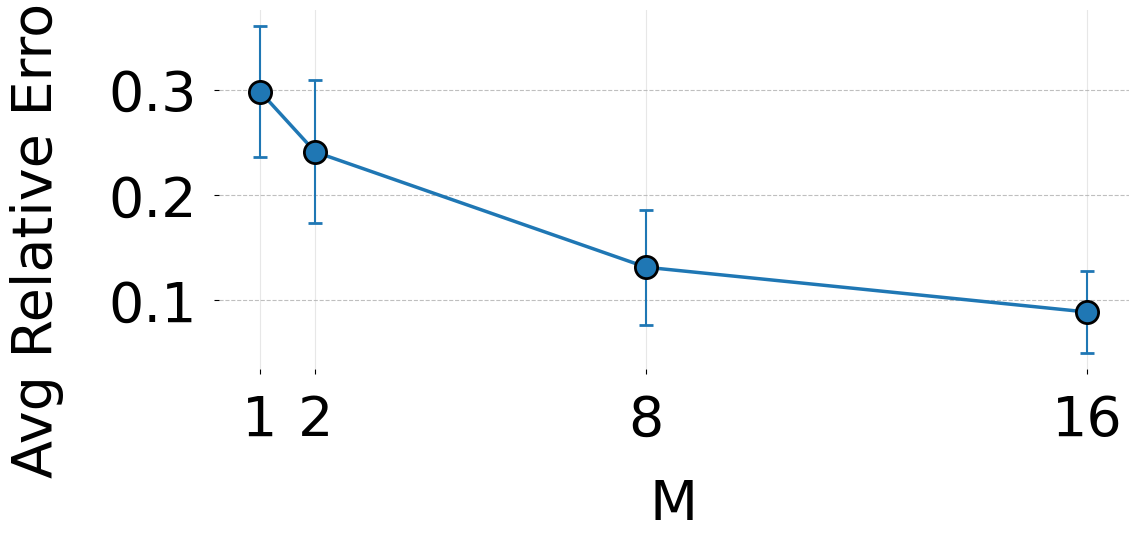

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_M_lsqpp_bigann.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_M_lsqpp_bigann.svg


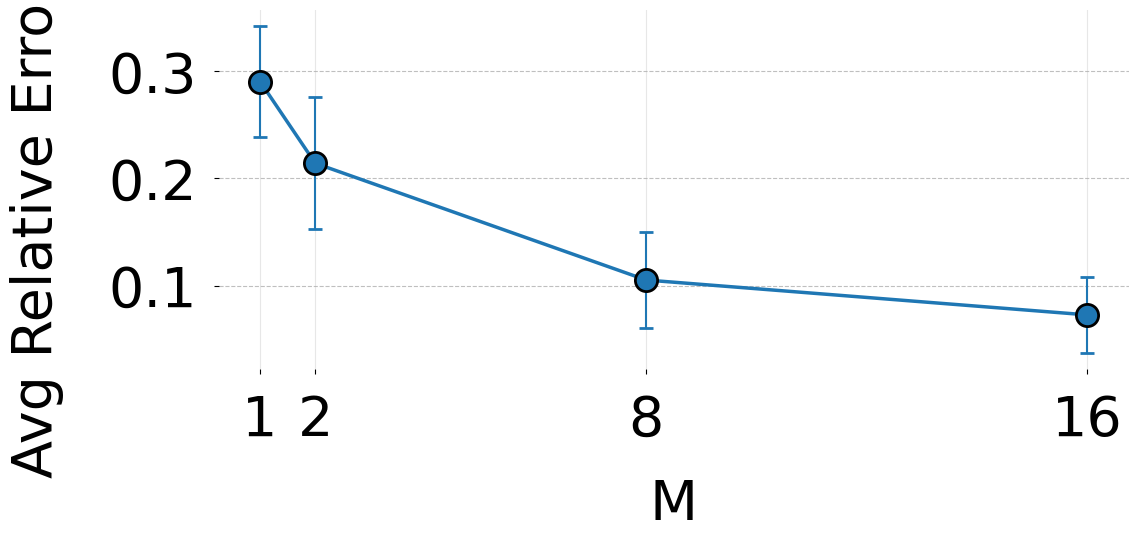

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_M_lsqpp_gist.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_M_lsqpp_gist.svg


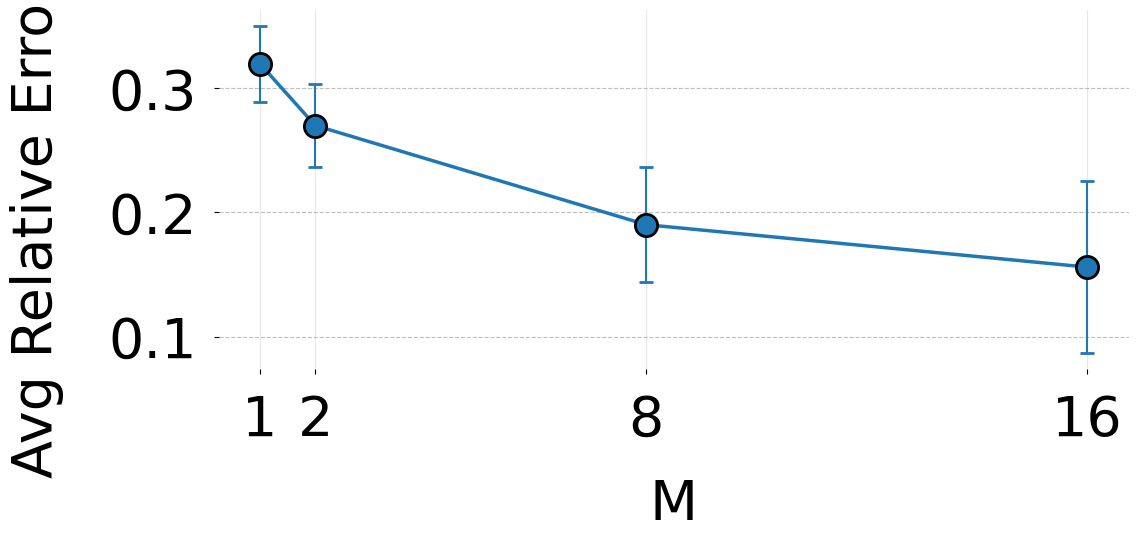

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_M_lsqpp_msmarco.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_M_lsqpp_msmarco.svg


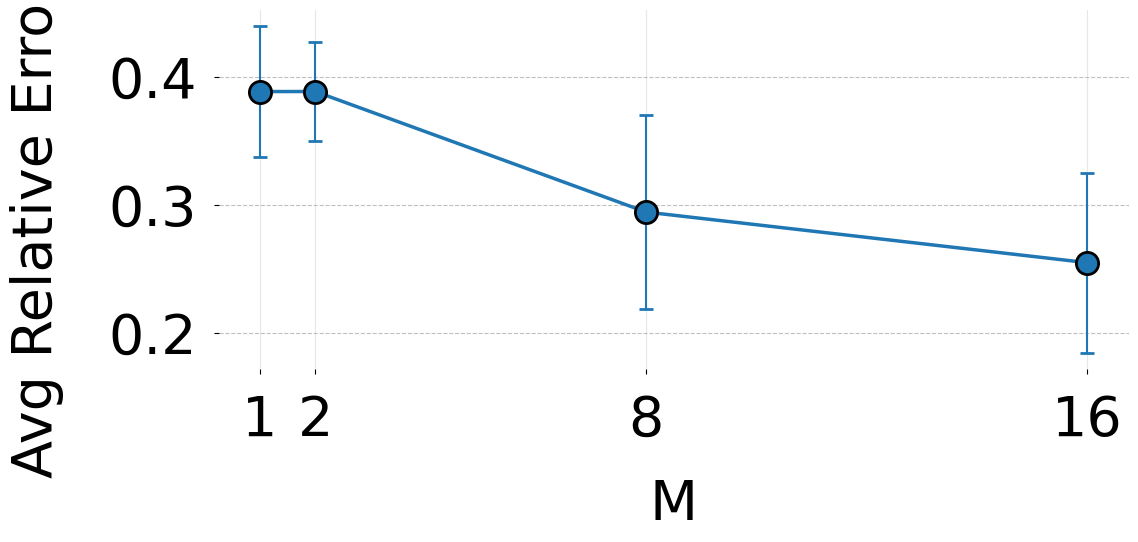

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_M_lsqpp_openai.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_M_lsqpp_openai.svg


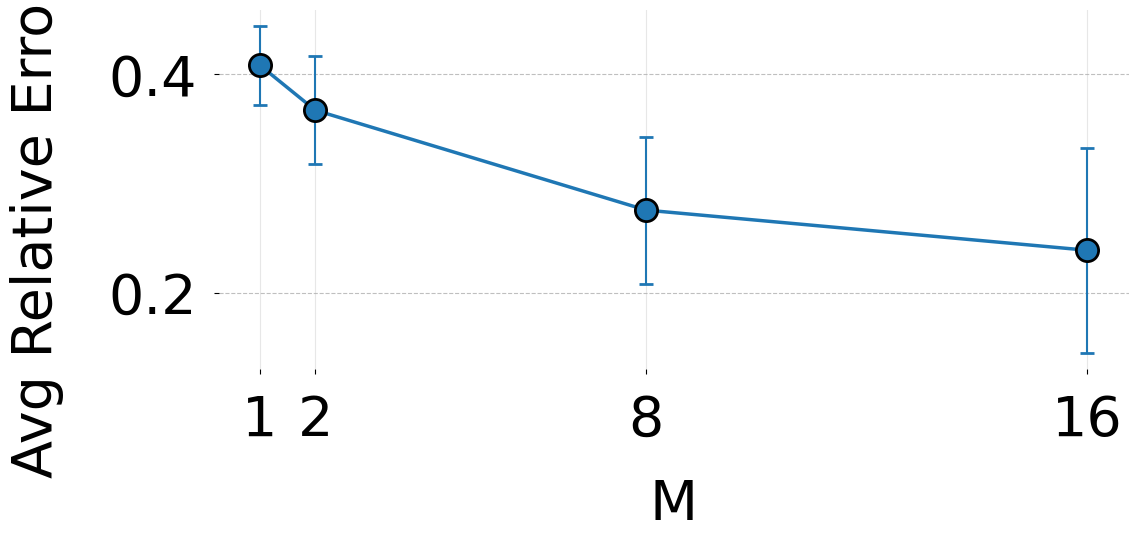

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_nbits_lsqpp_deep.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_nbits_lsqpp_deep.svg


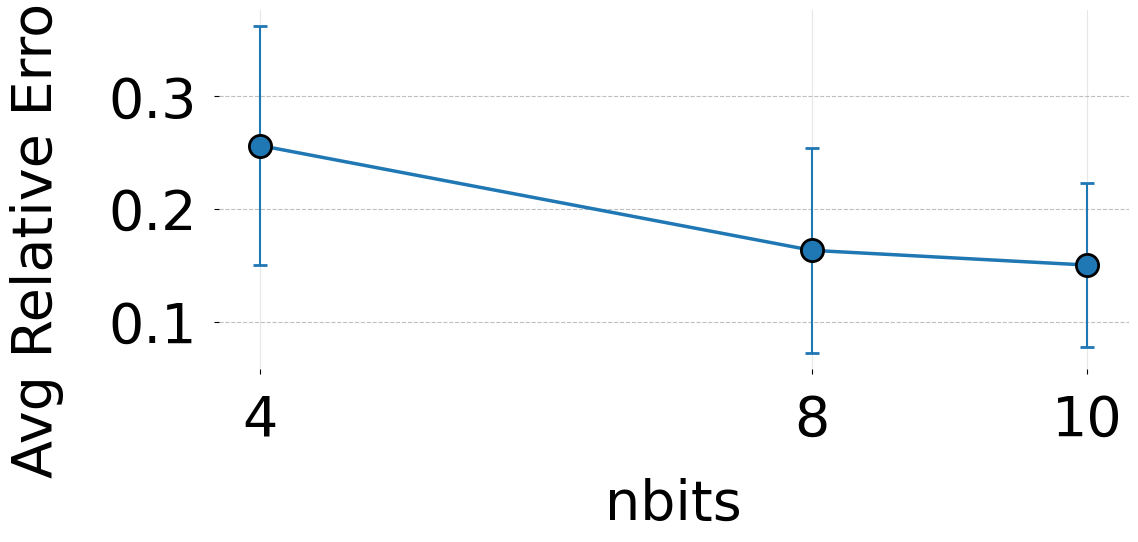

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_nbits_lsqpp_bigann.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_nbits_lsqpp_bigann.svg


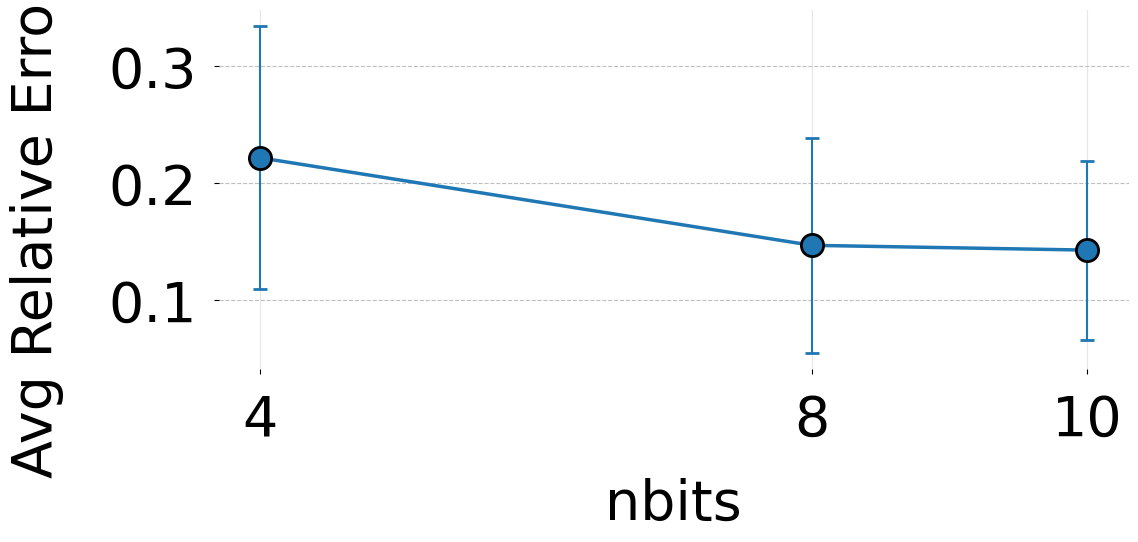

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_nbits_lsqpp_gist.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_nbits_lsqpp_gist.svg


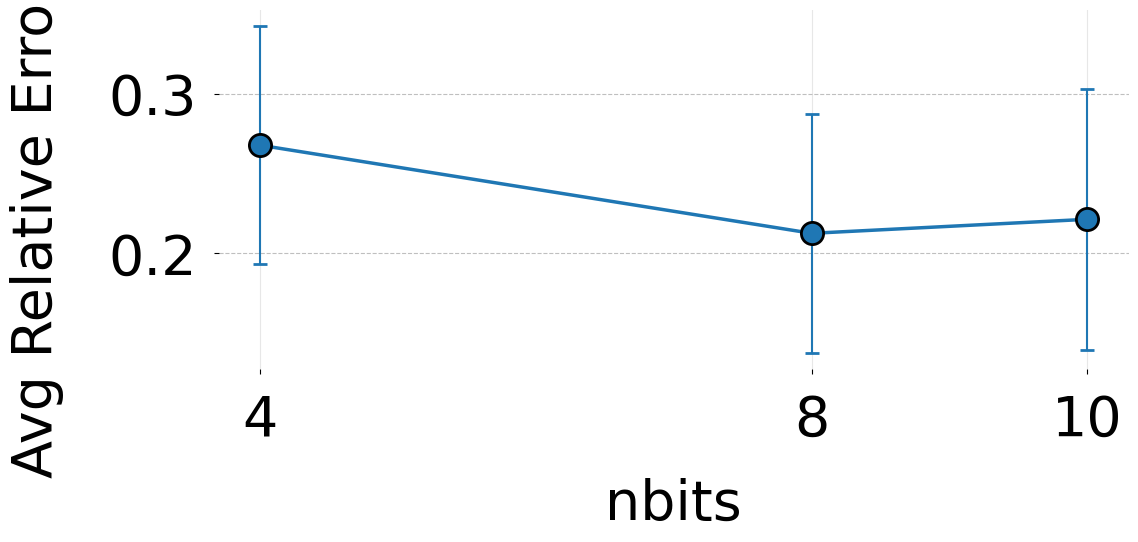

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_nbits_lsqpp_msmarco.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_nbits_lsqpp_msmarco.svg


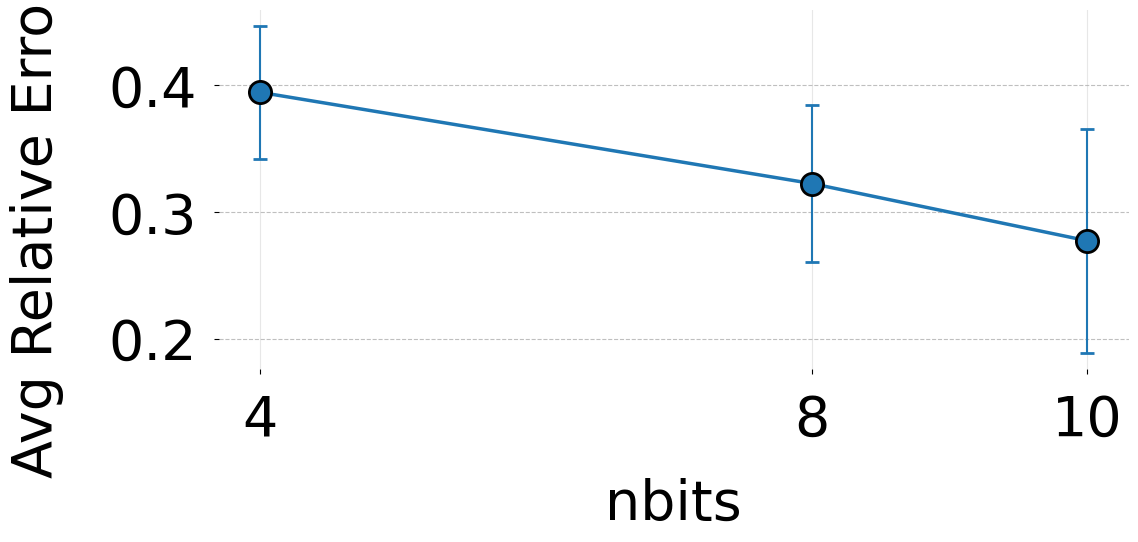

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_nbits_lsqpp_openai.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_nbits_lsqpp_openai.svg


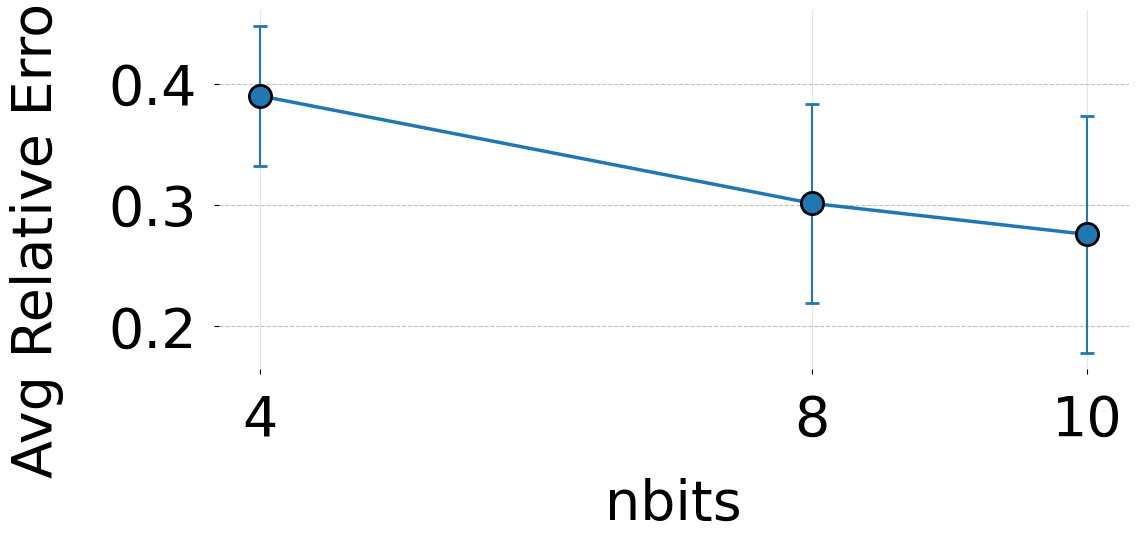

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_train_size_lsqpp_deep.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_train_size_lsqpp_deep.svg


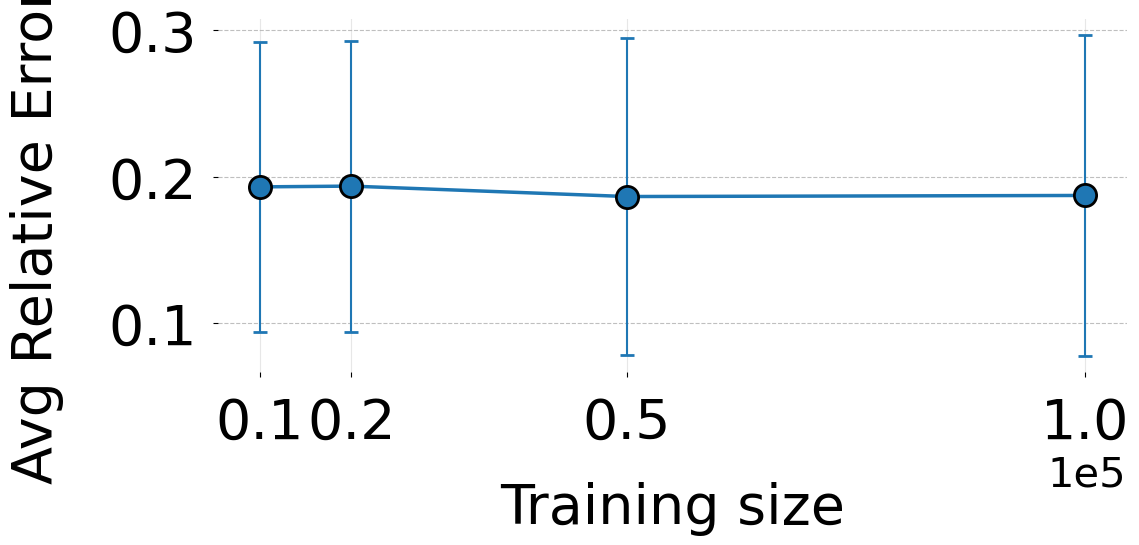

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_train_size_lsqpp_bigann.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_train_size_lsqpp_bigann.svg


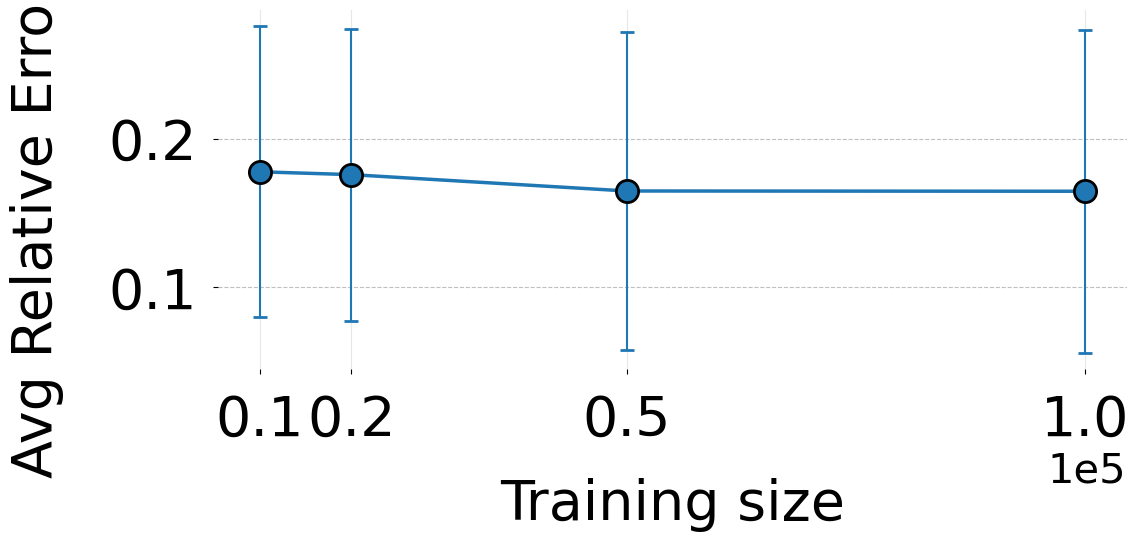

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_train_size_lsqpp_gist.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_train_size_lsqpp_gist.svg


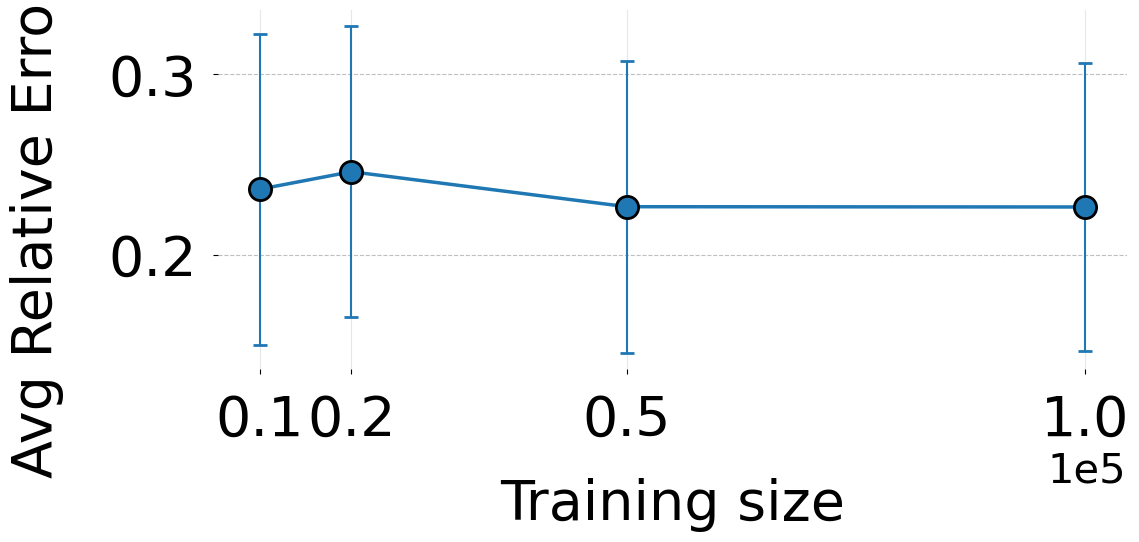

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_train_size_lsqpp_msmarco.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_train_size_lsqpp_msmarco.svg


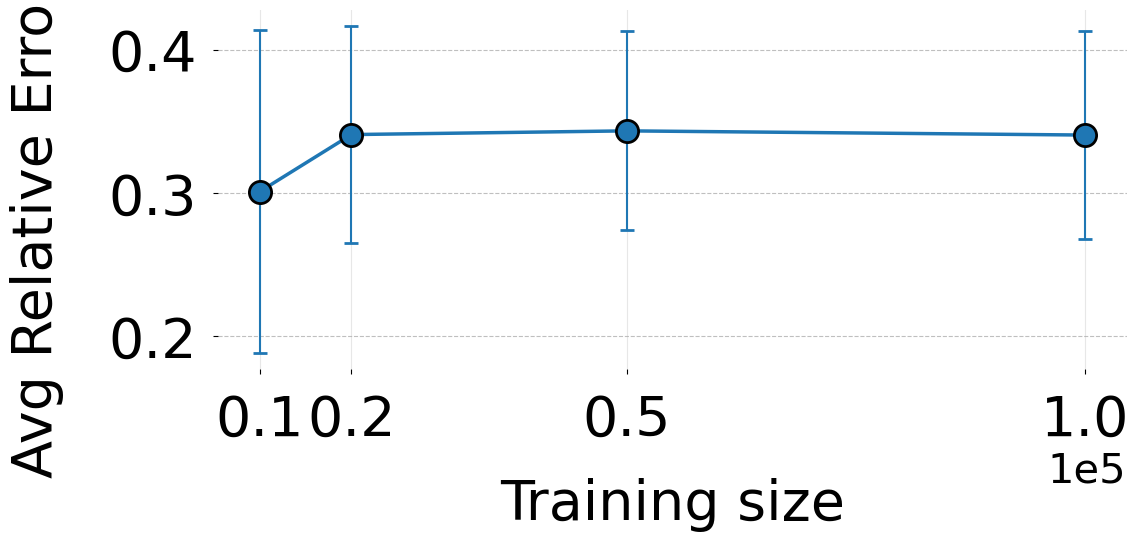

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_train_size_lsqpp_openai.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_train_size_lsqpp_openai.svg


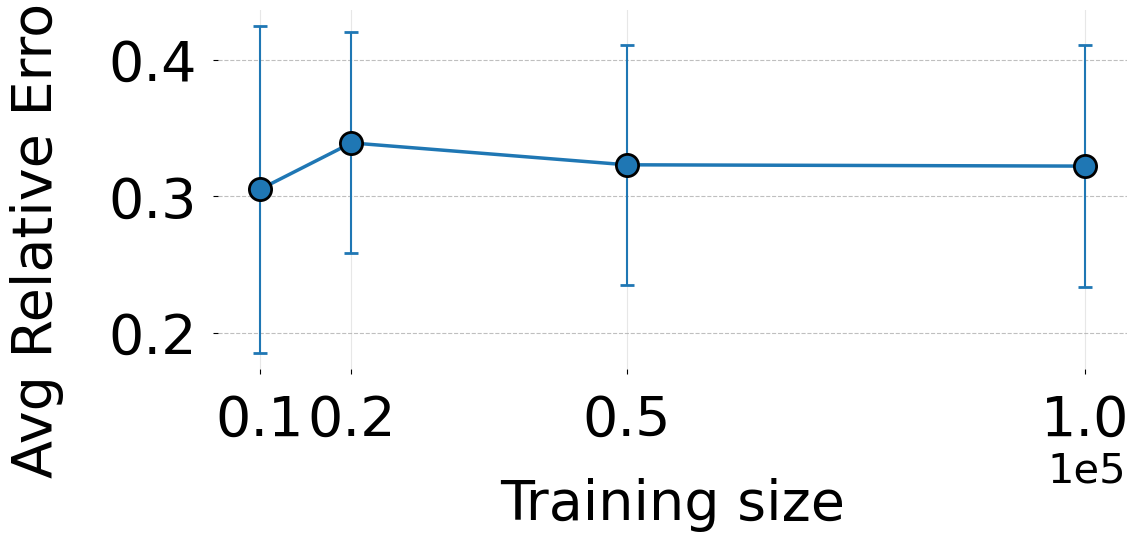

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_M_with_config_legend_lsqpp_deep.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_M_with_config_legend_lsqpp_deep.svg


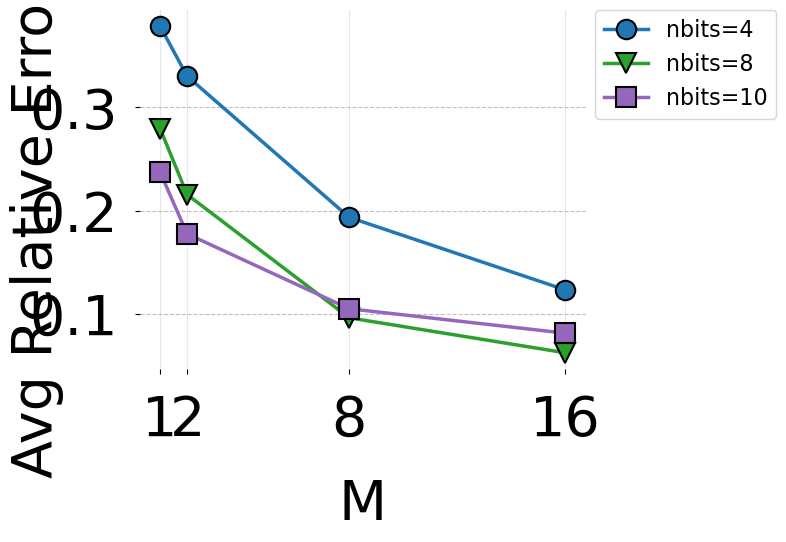

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_M_with_config_legend_lsqpp_bigann.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_M_with_config_legend_lsqpp_bigann.svg


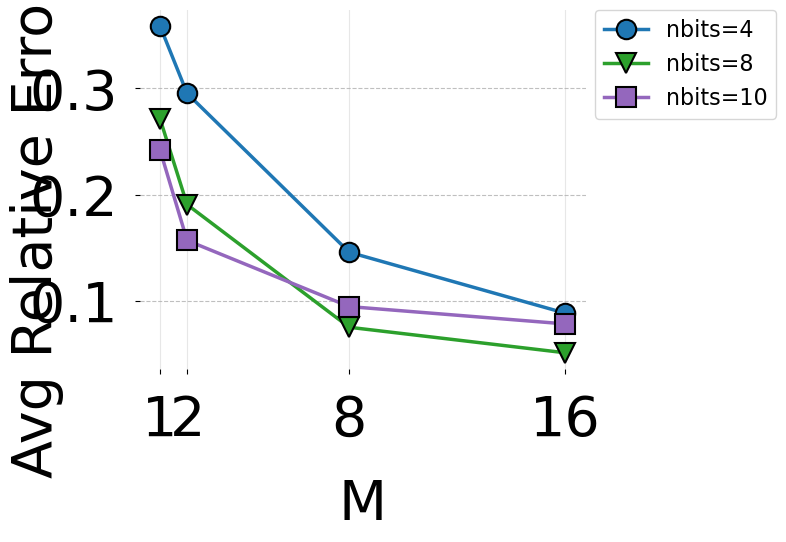

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_M_with_config_legend_lsqpp_gist.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_M_with_config_legend_lsqpp_gist.svg


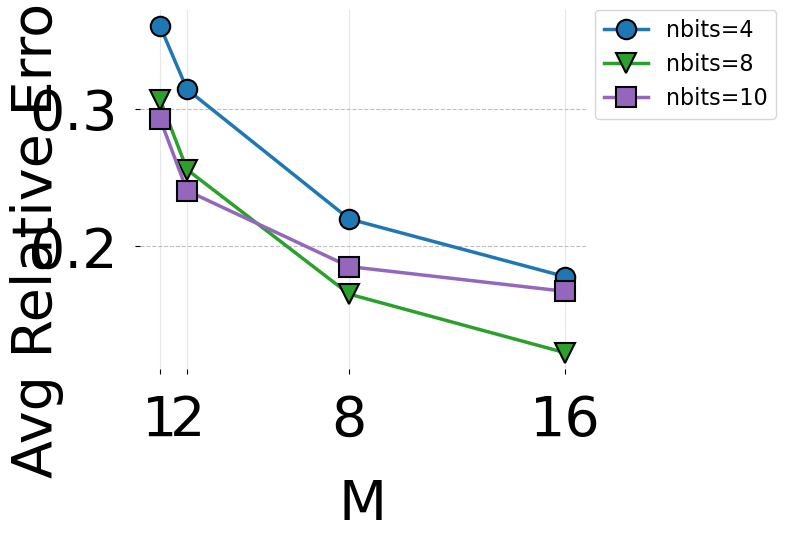

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_M_with_config_legend_lsqpp_msmarco.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_M_with_config_legend_lsqpp_msmarco.svg


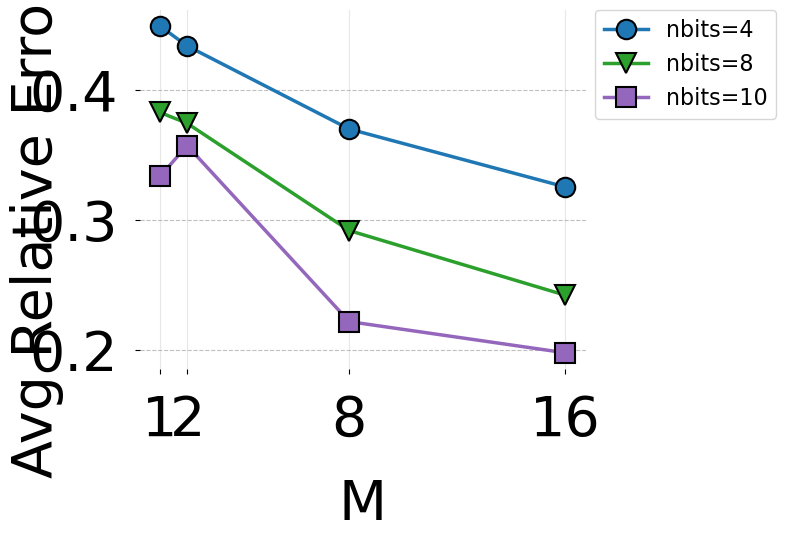

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_M_with_config_legend_lsqpp_openai.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_M_with_config_legend_lsqpp_openai.svg


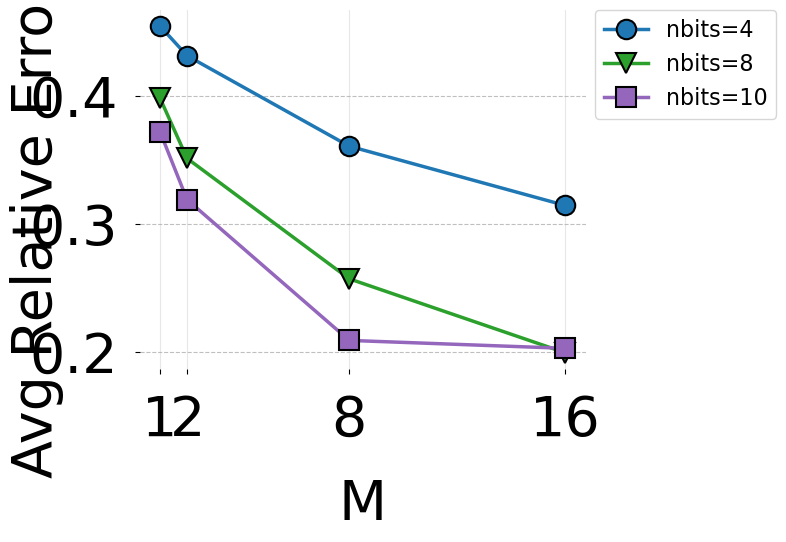

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_nbits_with_config_legend_lsqpp_deep.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_nbits_with_config_legend_lsqpp_deep.svg


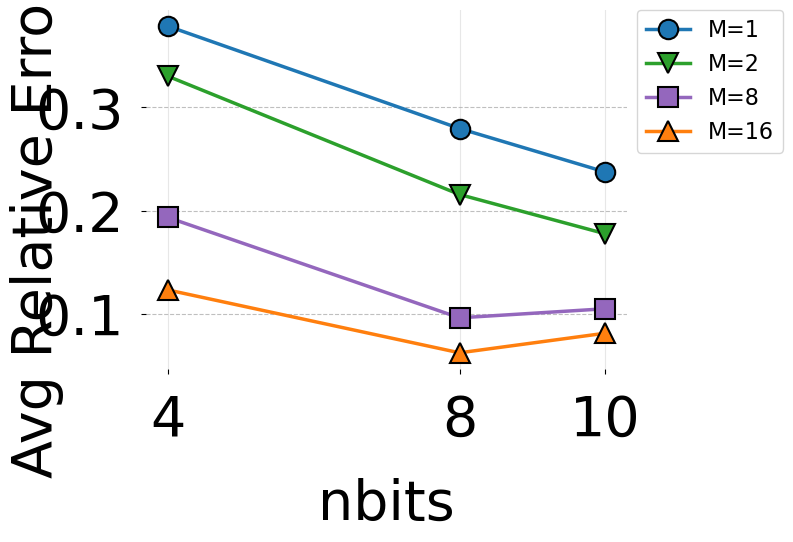

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_nbits_with_config_legend_lsqpp_bigann.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_nbits_with_config_legend_lsqpp_bigann.svg


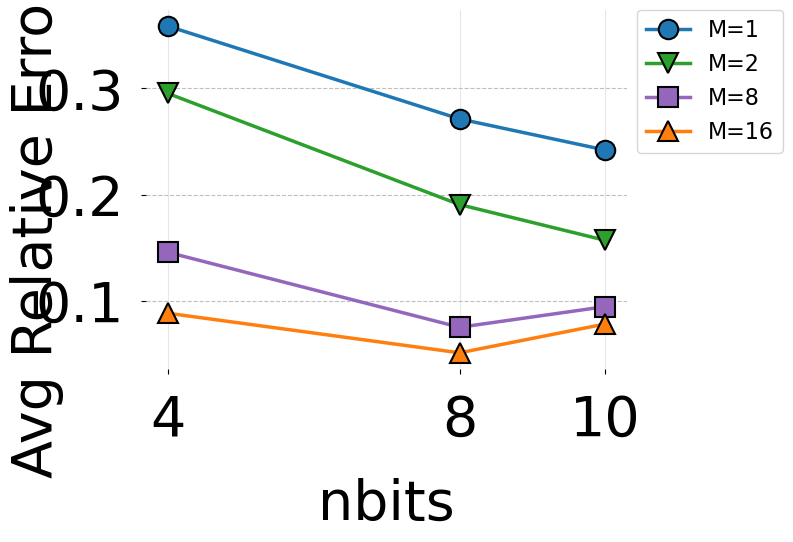

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_nbits_with_config_legend_lsqpp_gist.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_nbits_with_config_legend_lsqpp_gist.svg


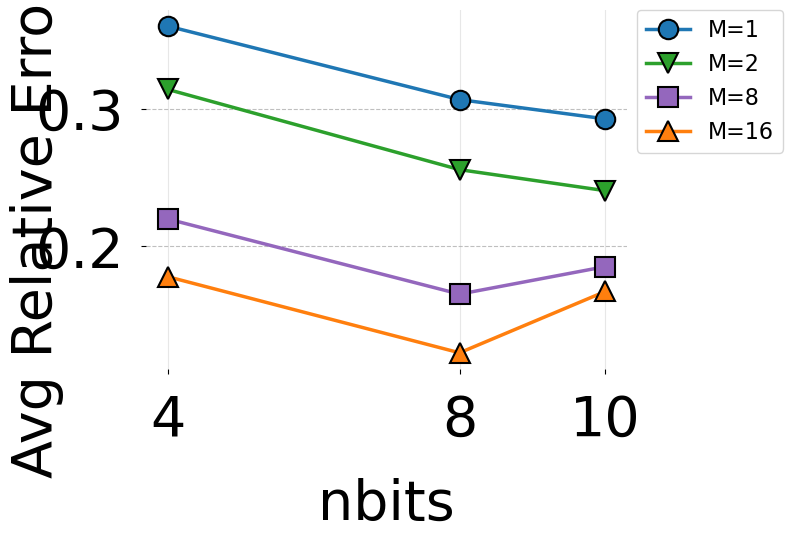

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_nbits_with_config_legend_lsqpp_msmarco.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_nbits_with_config_legend_lsqpp_msmarco.svg


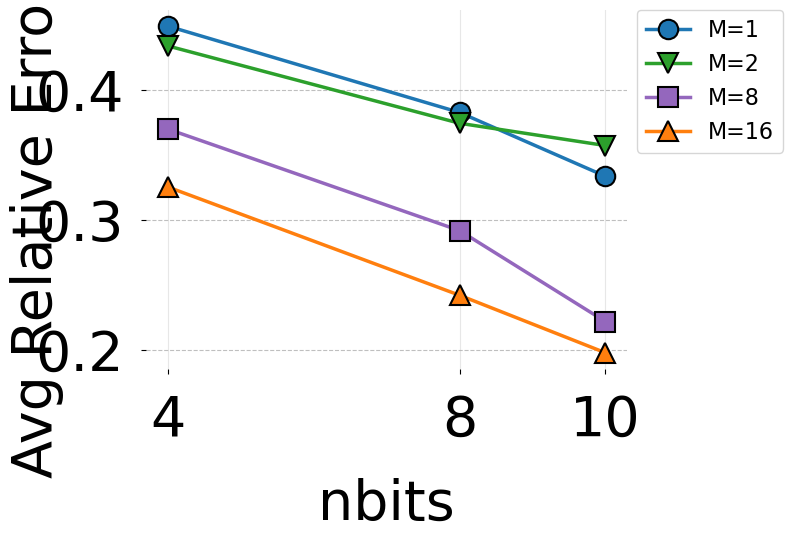

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_nbits_with_config_legend_lsqpp_openai.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_nbits_with_config_legend_lsqpp_openai.svg


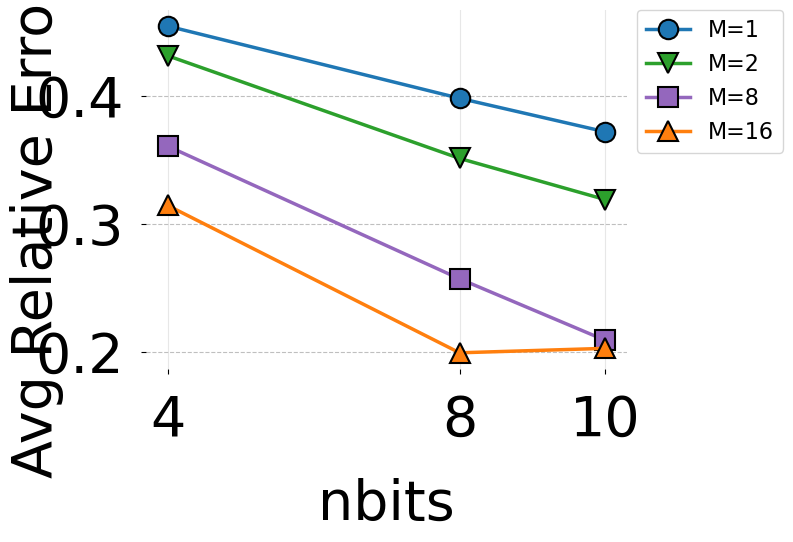

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_train_size_legend_M_lsqpp_deep.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_train_size_legend_M_lsqpp_deep.svg


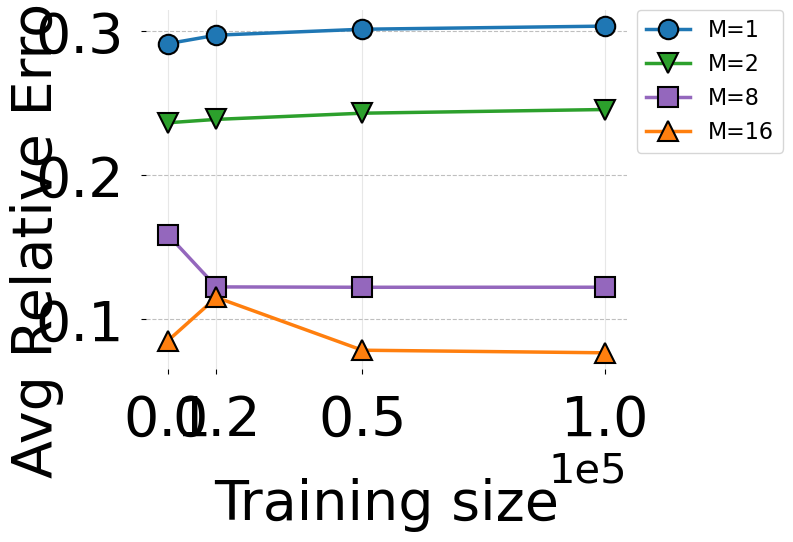

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_train_size_legend_M_lsqpp_bigann.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_train_size_legend_M_lsqpp_bigann.svg


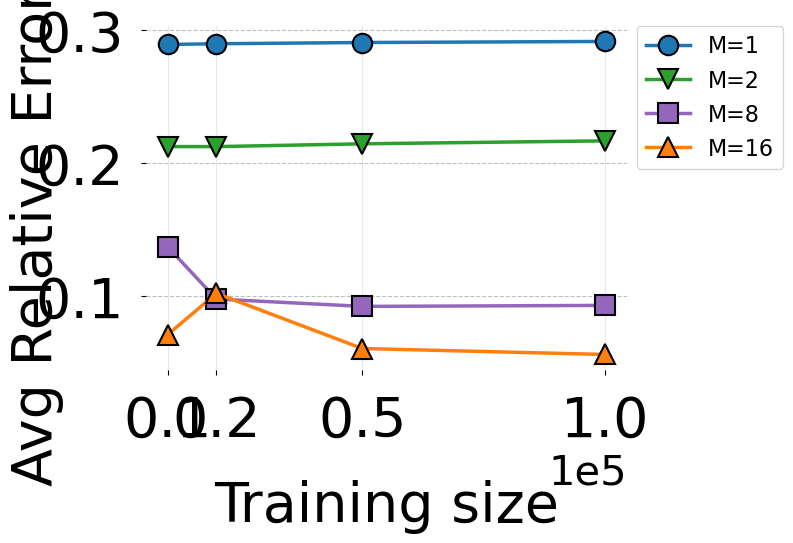

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_train_size_legend_M_lsqpp_gist.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_train_size_legend_M_lsqpp_gist.svg


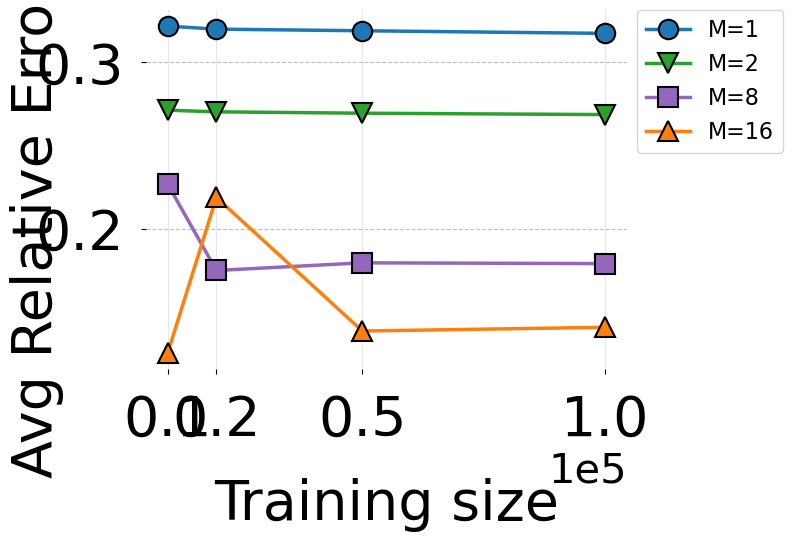

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_train_size_legend_M_lsqpp_msmarco.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_train_size_legend_M_lsqpp_msmarco.svg


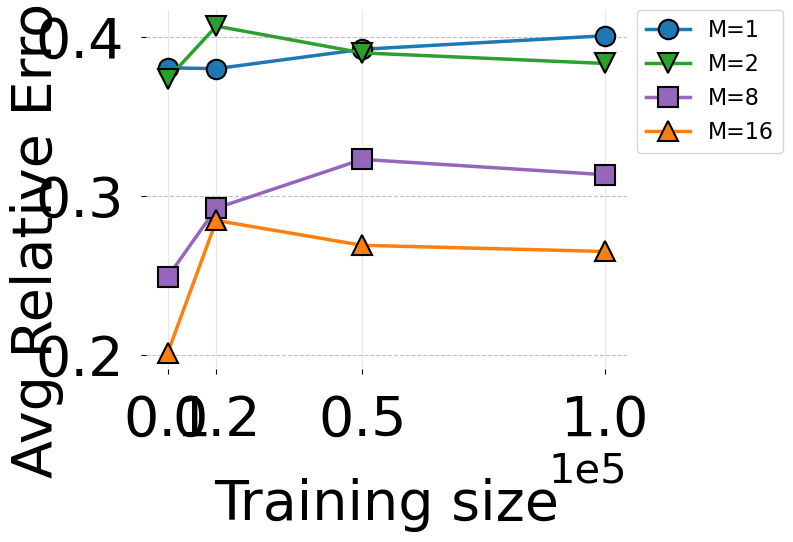

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_train_size_legend_M_lsqpp_openai.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_train_size_legend_M_lsqpp_openai.svg


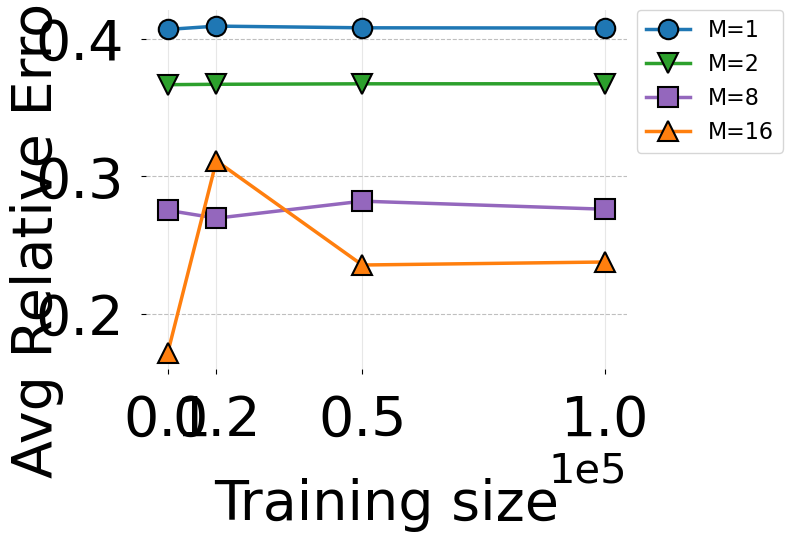

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_train_size_legend_nbits_lsqpp_deep.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_train_size_legend_nbits_lsqpp_deep.svg


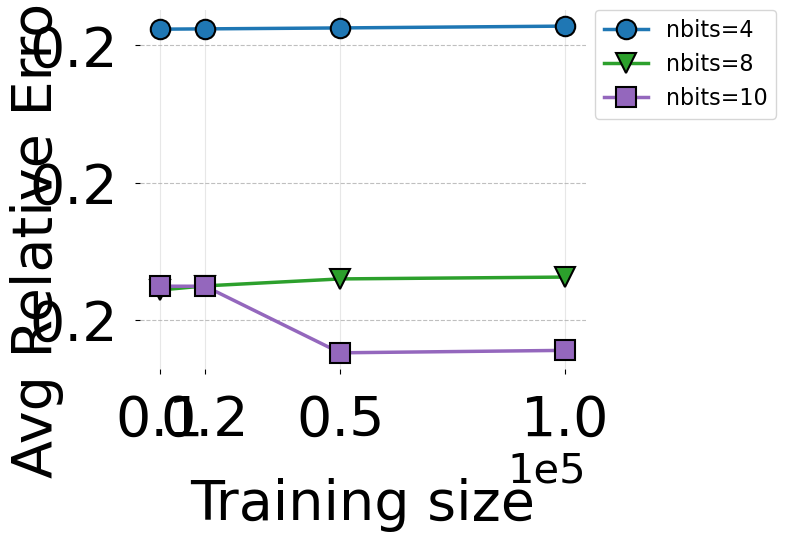

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_train_size_legend_nbits_lsqpp_bigann.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_train_size_legend_nbits_lsqpp_bigann.svg


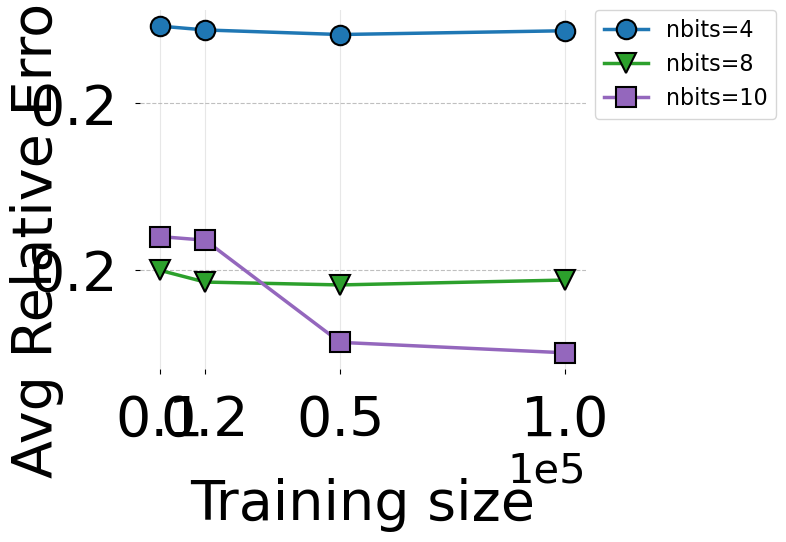

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_train_size_legend_nbits_lsqpp_gist.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_train_size_legend_nbits_lsqpp_gist.svg


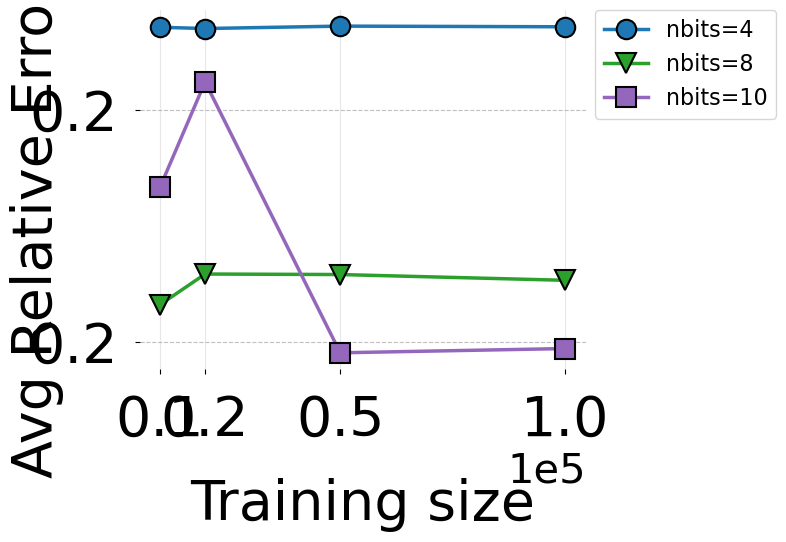

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_train_size_legend_nbits_lsqpp_msmarco.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_train_size_legend_nbits_lsqpp_msmarco.svg


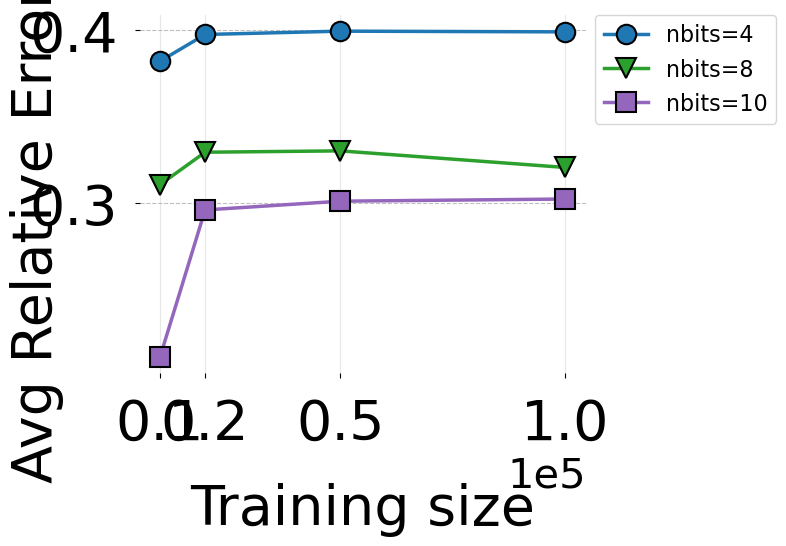

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_train_size_legend_nbits_lsqpp_openai.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_train_size_legend_nbits_lsqpp_openai.svg


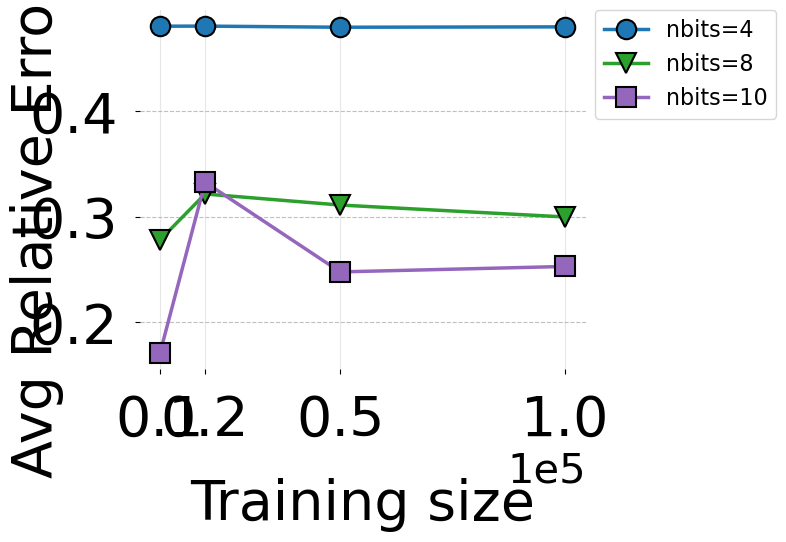

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_train_size_legend_bits_per_vector_lsqpp_deep.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_train_size_legend_bits_per_vector_lsqpp_deep.svg


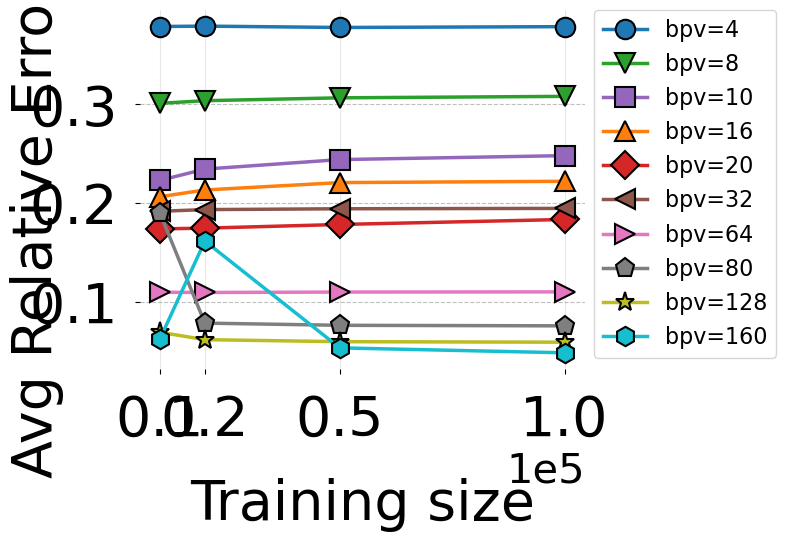

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_train_size_legend_bits_per_vector_lsqpp_bigann.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_train_size_legend_bits_per_vector_lsqpp_bigann.svg


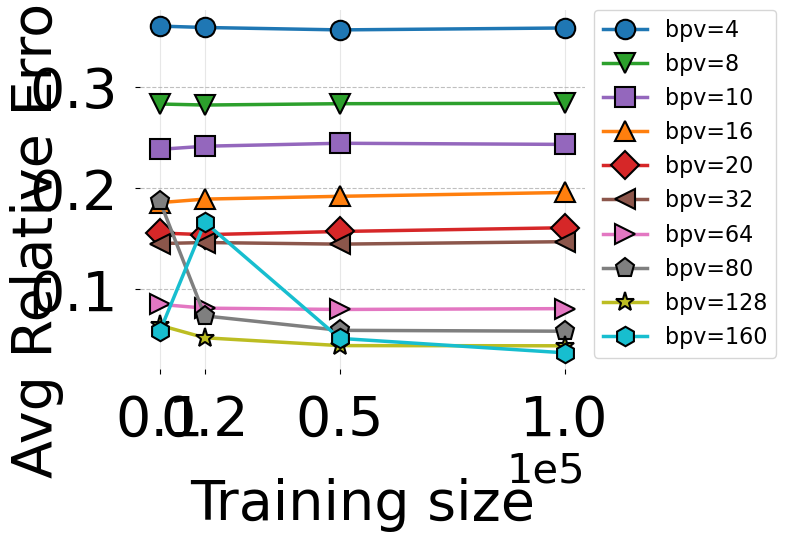

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_train_size_legend_bits_per_vector_lsqpp_gist.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_train_size_legend_bits_per_vector_lsqpp_gist.svg


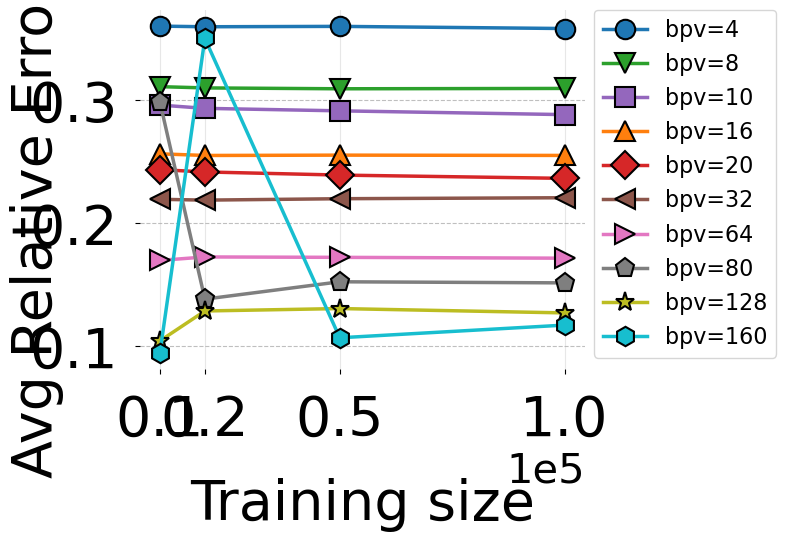

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_train_size_legend_bits_per_vector_lsqpp_msmarco.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_train_size_legend_bits_per_vector_lsqpp_msmarco.svg


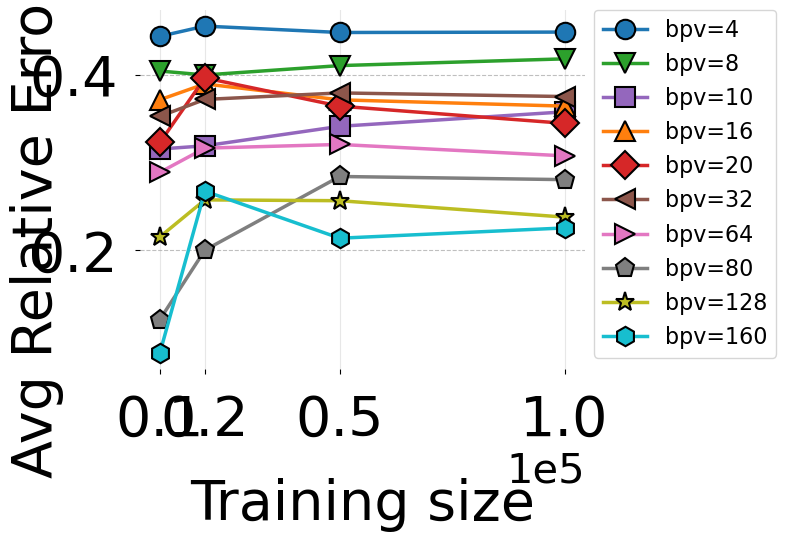

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_train_size_legend_bits_per_vector_lsqpp_openai.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_relerr_vs_train_size_legend_bits_per_vector_lsqpp_openai.svg


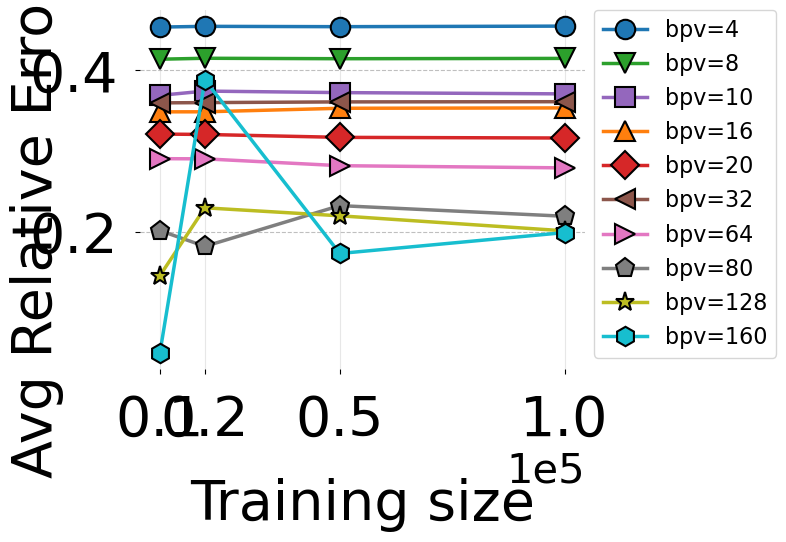

In [20]:
# Avg relative error vs M, averaged over nbits and train_size
plot_avg_metric_vs_param(
    plot_df,
    x_col="n_subquantizers",
    x_label="M",
    y_col="rel_error_mean",
    y_label="Avg Relative Error",
    avg_over=["nbits", "train_size"],
    output_stem="avg_relerr_vs_M",
)

# Avg relative error vs nbits, where k = 2**nbits centroids
plot_avg_metric_vs_param(
    plot_df,
    x_col="nbits",
    x_label="nbits",
    y_col="rel_error_mean",
    y_label="Avg Relative Error",
    avg_over=["n_subquantizers", "train_size"],
    output_stem="avg_relerr_vs_nbits",
)

# Avg relative error vs training size, averaged over M and nbits
plot_avg_metric_vs_param(
    plot_df,
    x_col="train_size",
    x_label="Training size",
    y_col="rel_error_mean",
    y_label="Avg Relative Error",
    avg_over=["n_subquantizers", "nbits"],
    output_stem="avg_relerr_vs_train_size",
)

# Relative error plots with the other grid parameters shown in the legend
plot_metric_vs_param_with_config_legend(
    plot_df,
    x_col="n_subquantizers",
    x_label="M",
    y_col="rel_error_mean",
    y_label="Avg Relative Error",
    legend_cols=["nbits"],
    output_stem="avg_relerr_vs_M_with_config_legend",
)

plot_metric_vs_param_with_config_legend(
    plot_df,
    x_col="nbits",
    x_label="nbits",
    y_col="rel_error_mean",
    y_label="Avg Relative Error",
    legend_cols=["n_subquantizers"],
    output_stem="avg_relerr_vs_nbits_with_config_legend",
)

plot_metric_vs_param_with_config_legend(
    plot_df,
    x_col="train_size",
    x_label="Training size",
    y_col="rel_error_mean",
    y_label="Avg Relative Error",
    legend_cols=["n_subquantizers"],
    output_stem="avg_relerr_vs_train_size_legend_M",
)

plot_metric_vs_param_with_config_legend(
    plot_df,
    x_col="train_size",
    x_label="Training size",
    y_col="rel_error_mean",
    y_label="Avg Relative Error",
    legend_cols=["nbits"],
    output_stem="avg_relerr_vs_train_size_legend_nbits",
)

plot_metric_vs_param_with_config_legend(
    plot_df,
    x_col="train_size",
    x_label="Training size",
    y_col="rel_error_mean",
    y_label="Avg Relative Error",
    legend_cols=["bits_per_vector"],
    output_stem="avg_relerr_vs_train_size_legend_bits_per_vector",
)


## ADC Time Plots

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/adc_time_vs_bits_per_vector_lsqpp_deep.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/adc_time_vs_bits_per_vector_lsqpp_deep.svg


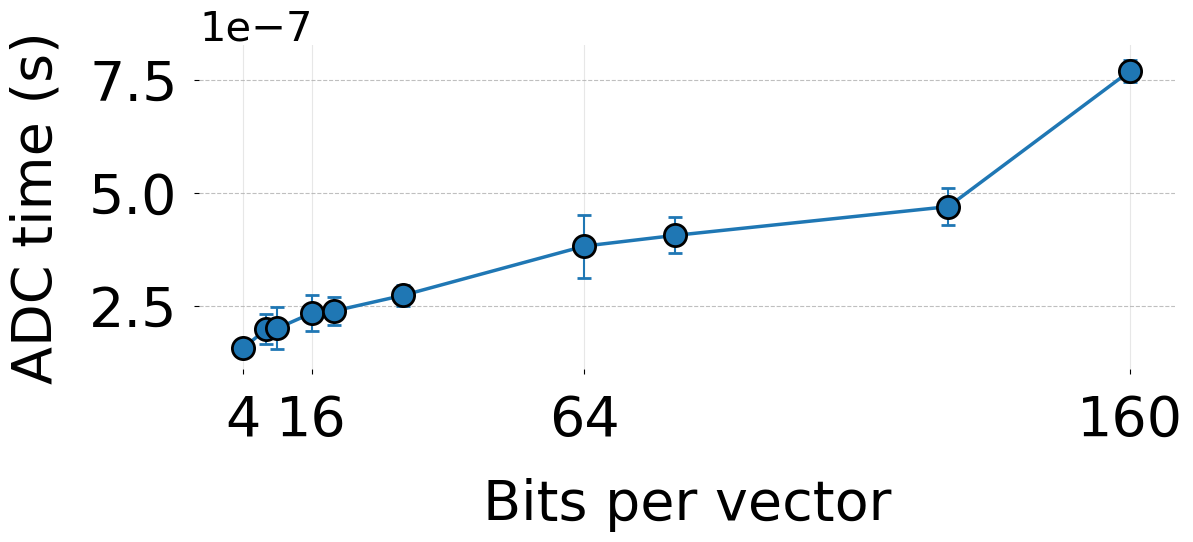

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/adc_time_vs_bits_per_vector_lsqpp_bigann.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/adc_time_vs_bits_per_vector_lsqpp_bigann.svg


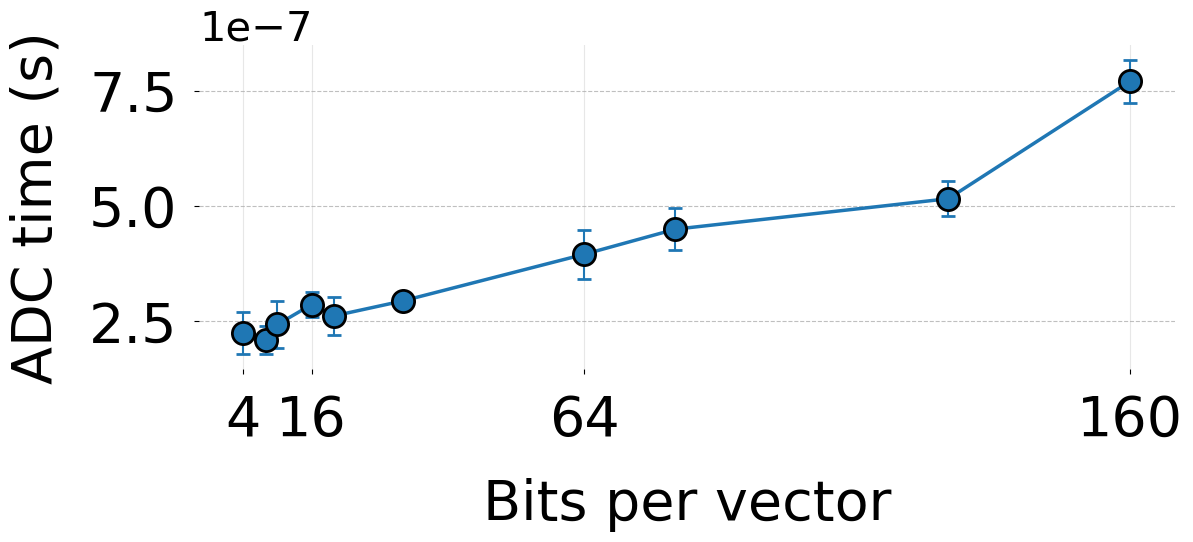

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/adc_time_vs_bits_per_vector_lsqpp_gist.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/adc_time_vs_bits_per_vector_lsqpp_gist.svg


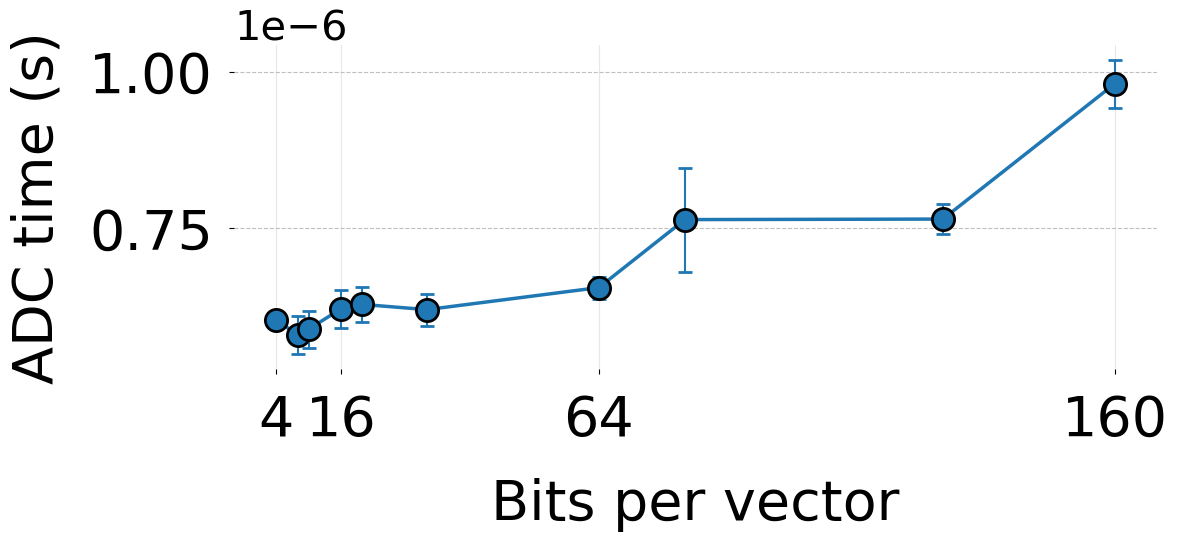

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/adc_time_vs_bits_per_vector_lsqpp_msmarco.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/adc_time_vs_bits_per_vector_lsqpp_msmarco.svg


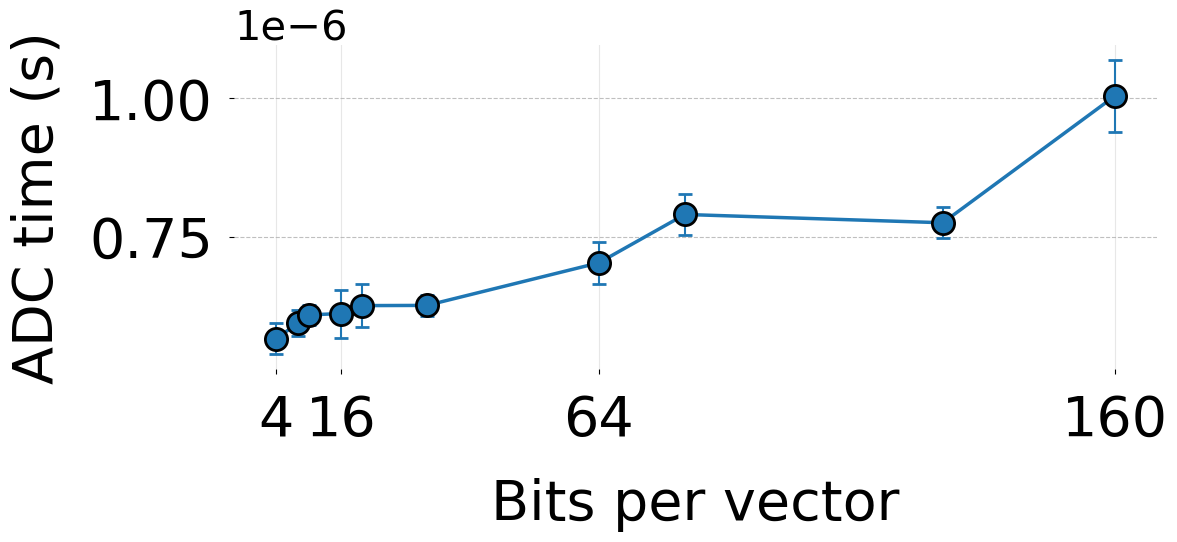

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/adc_time_vs_bits_per_vector_lsqpp_openai.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/adc_time_vs_bits_per_vector_lsqpp_openai.svg


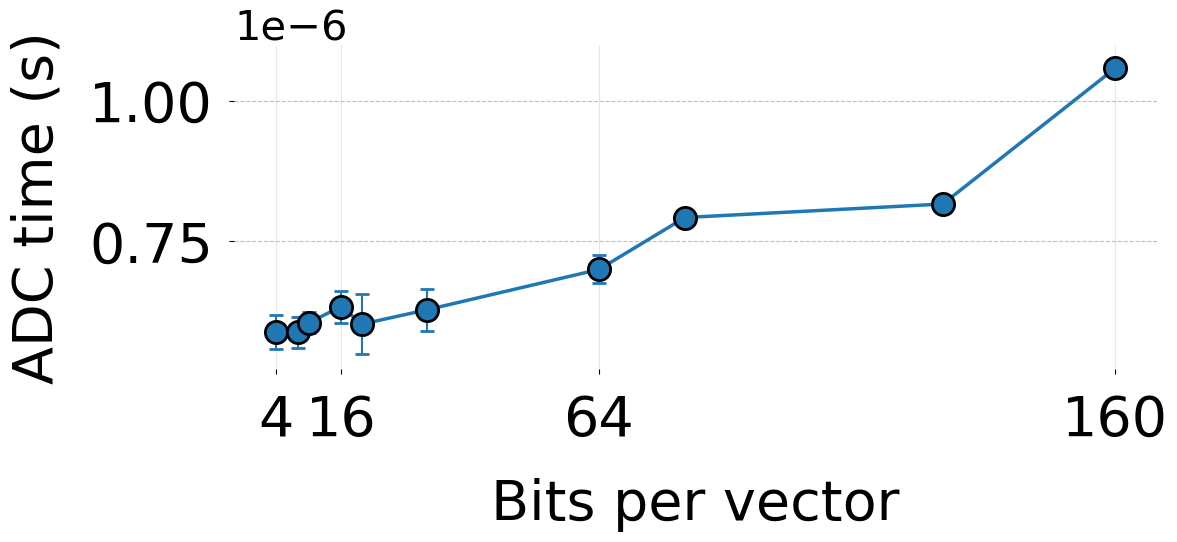

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/adc_time_vs_M_lsqpp_deep.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/adc_time_vs_M_lsqpp_deep.svg


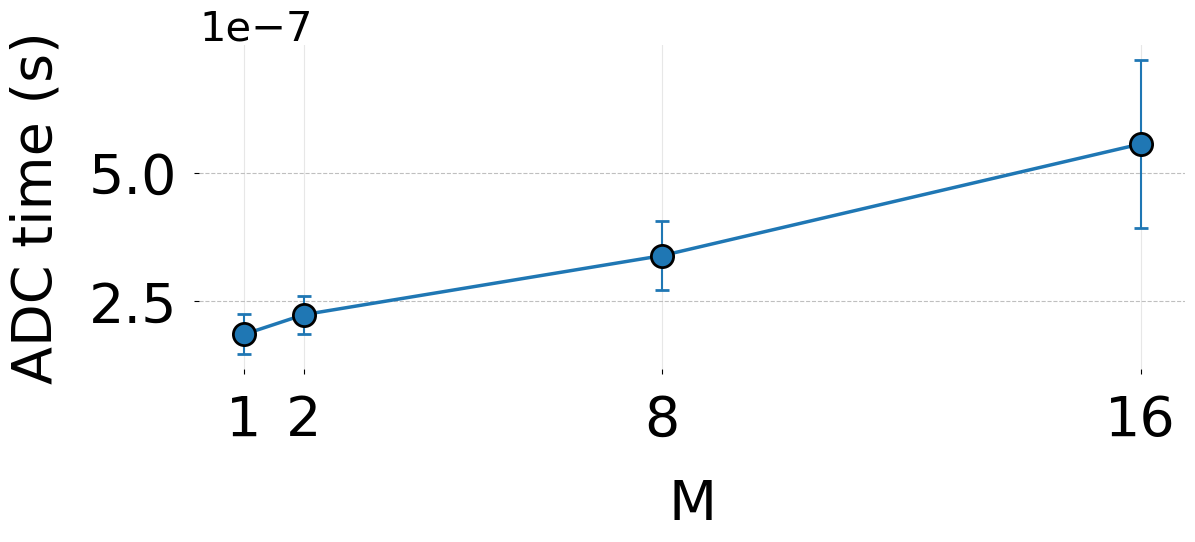

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/adc_time_vs_M_lsqpp_bigann.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/adc_time_vs_M_lsqpp_bigann.svg


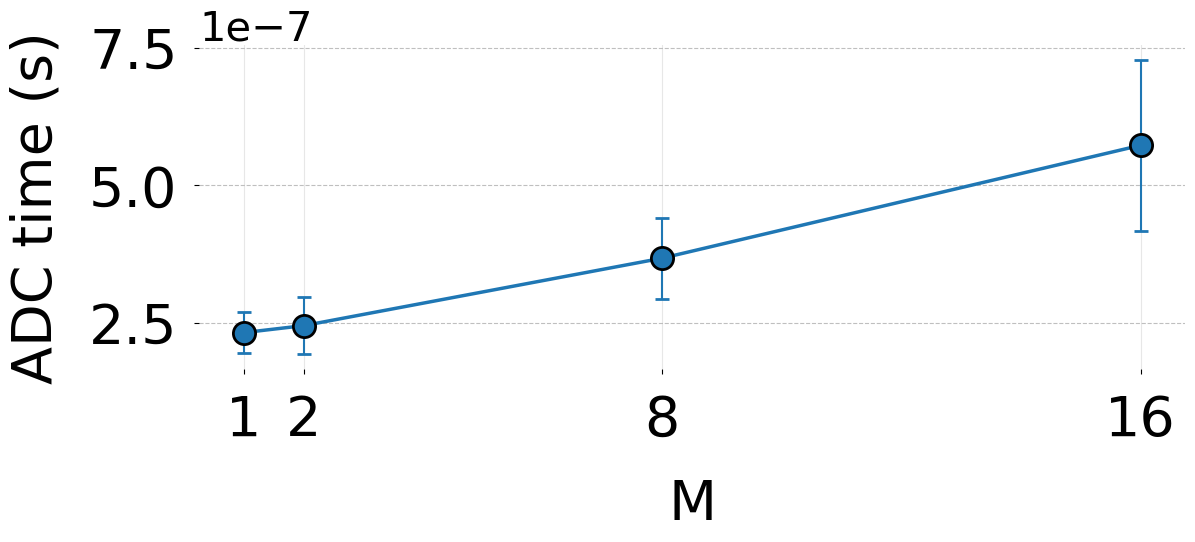

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/adc_time_vs_M_lsqpp_gist.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/adc_time_vs_M_lsqpp_gist.svg


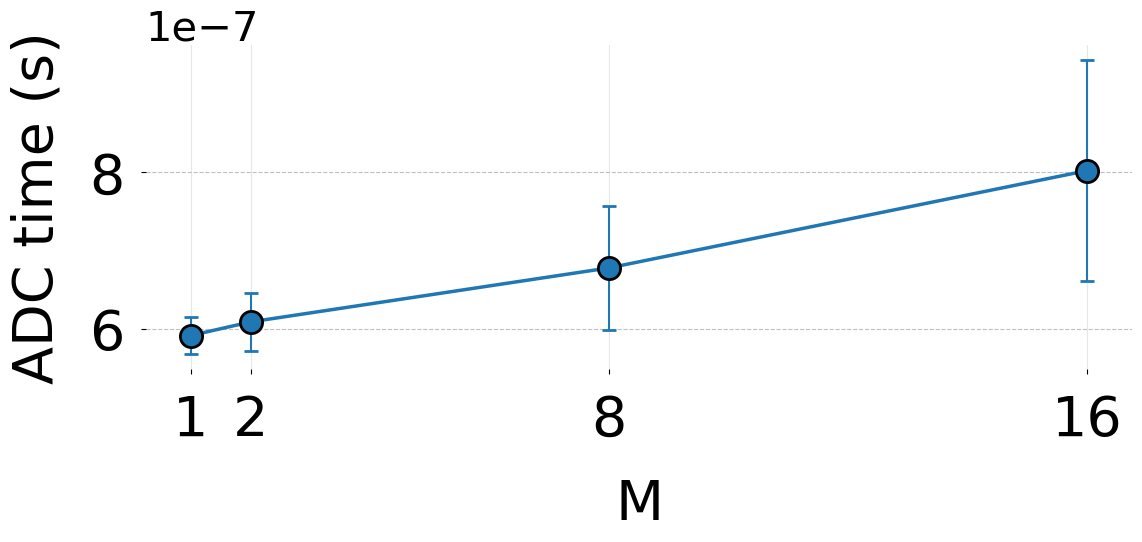

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/adc_time_vs_M_lsqpp_msmarco.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/adc_time_vs_M_lsqpp_msmarco.svg


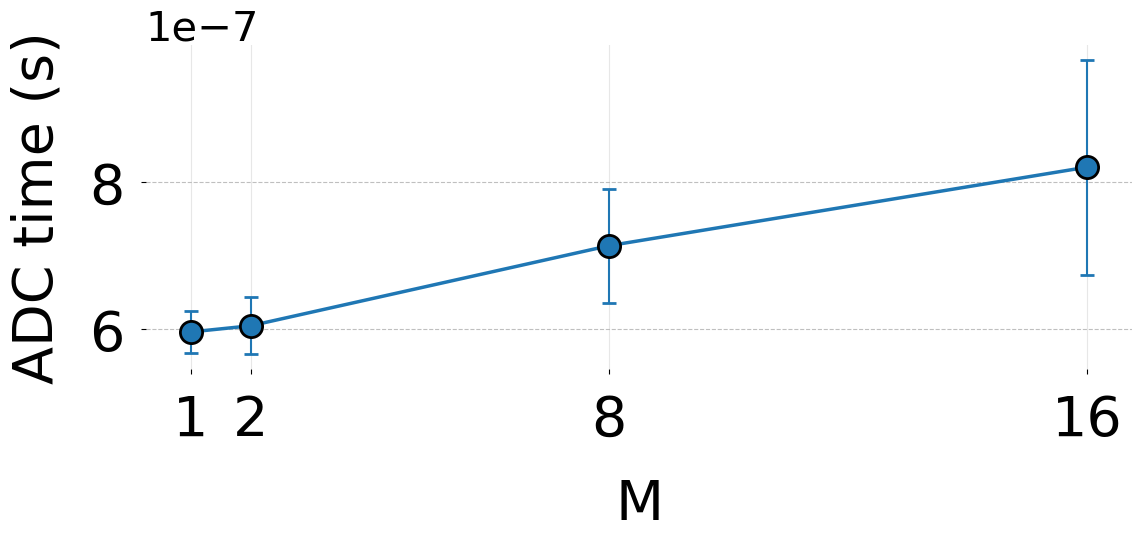

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/adc_time_vs_M_lsqpp_openai.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/adc_time_vs_M_lsqpp_openai.svg


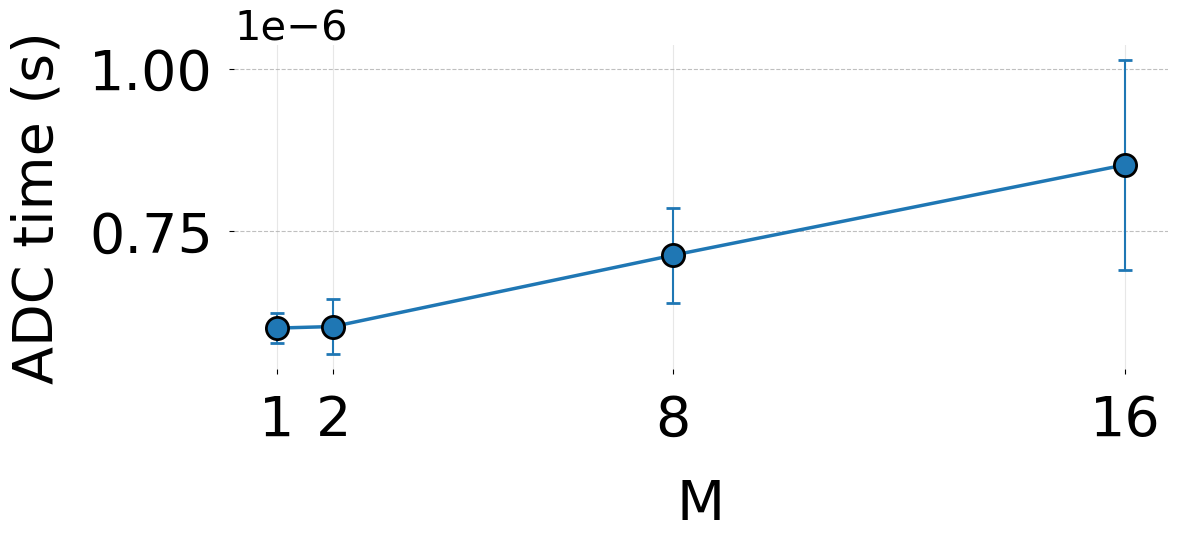

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/adc_time_vs_nbits_lsqpp_deep.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/adc_time_vs_nbits_lsqpp_deep.svg


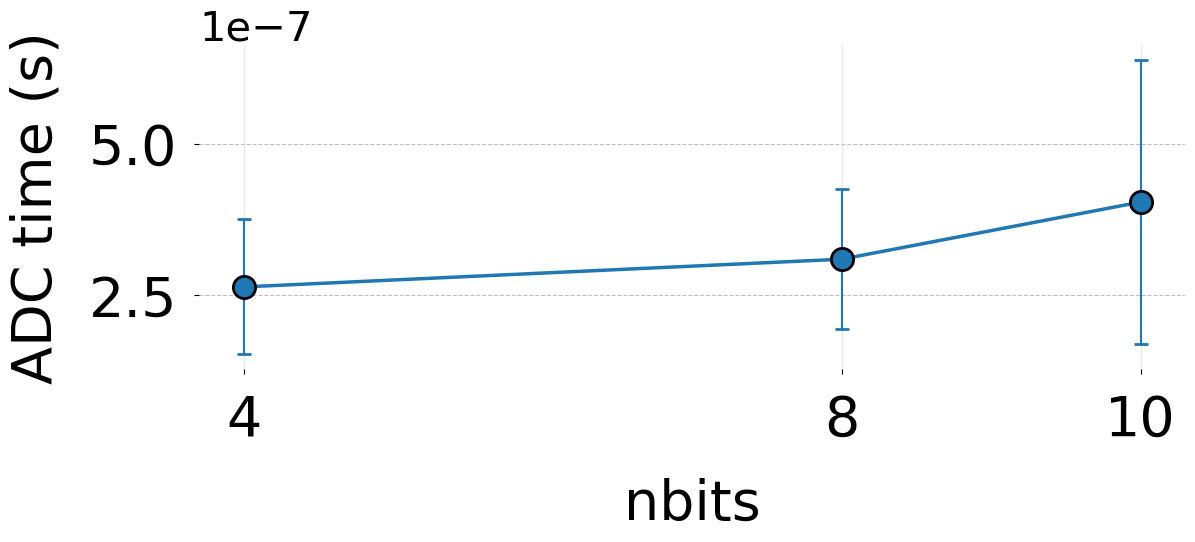

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/adc_time_vs_nbits_lsqpp_bigann.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/adc_time_vs_nbits_lsqpp_bigann.svg


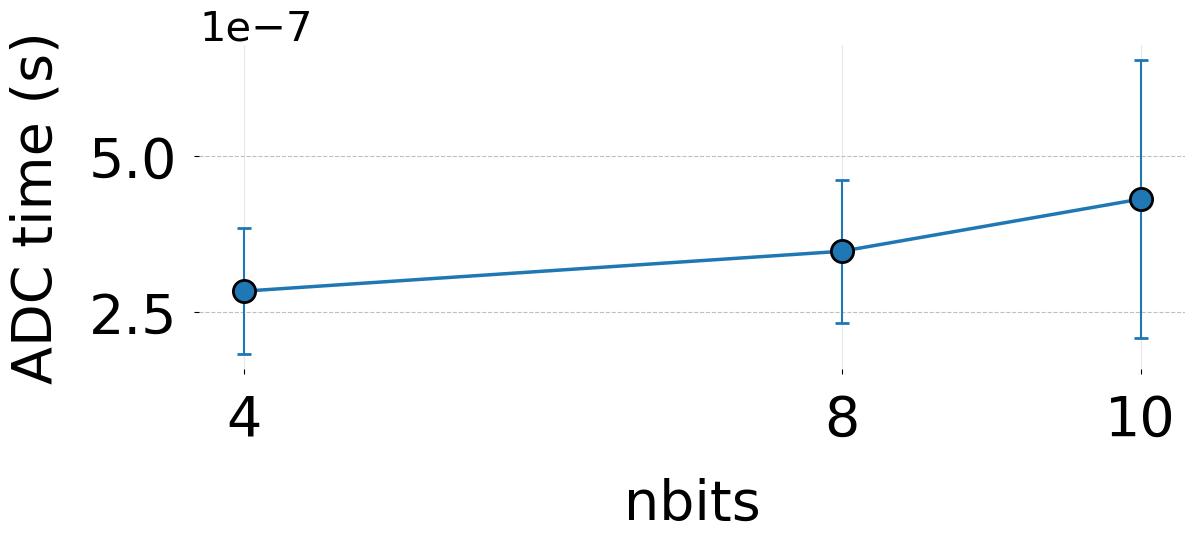

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/adc_time_vs_nbits_lsqpp_gist.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/adc_time_vs_nbits_lsqpp_gist.svg


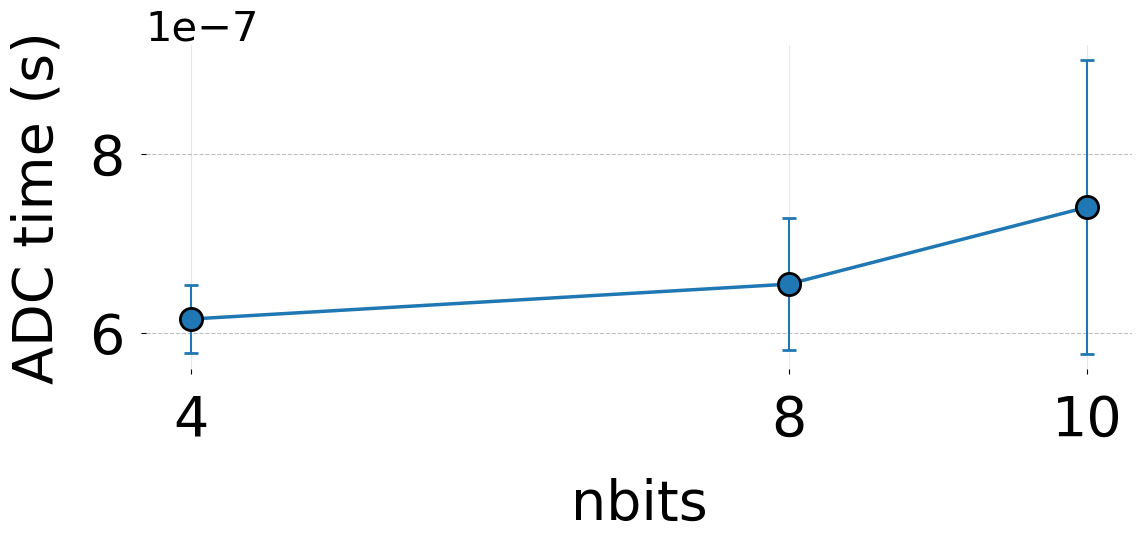

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/adc_time_vs_nbits_lsqpp_msmarco.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/adc_time_vs_nbits_lsqpp_msmarco.svg


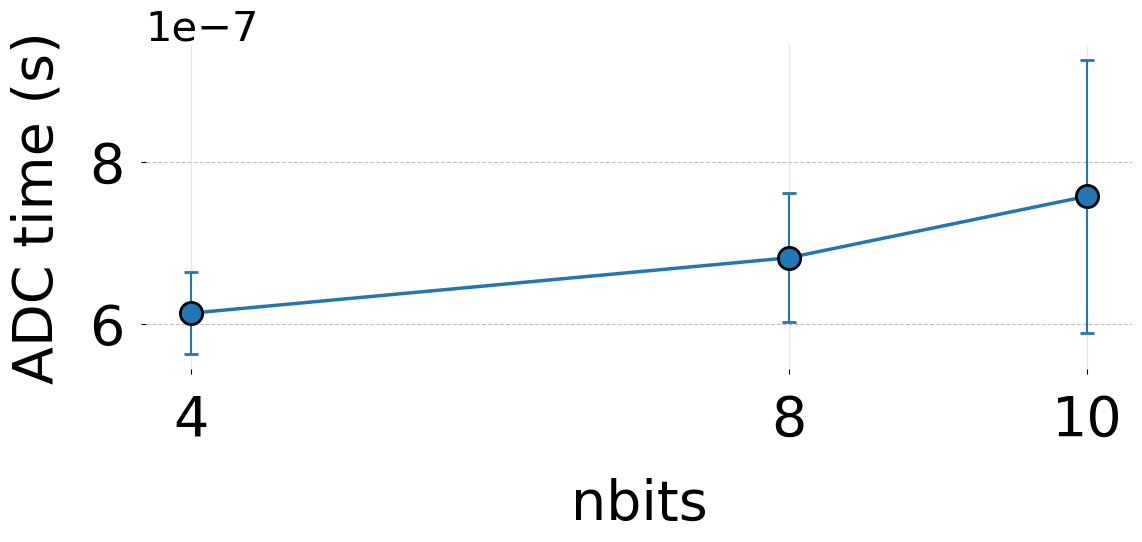

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/adc_time_vs_nbits_lsqpp_openai.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/adc_time_vs_nbits_lsqpp_openai.svg


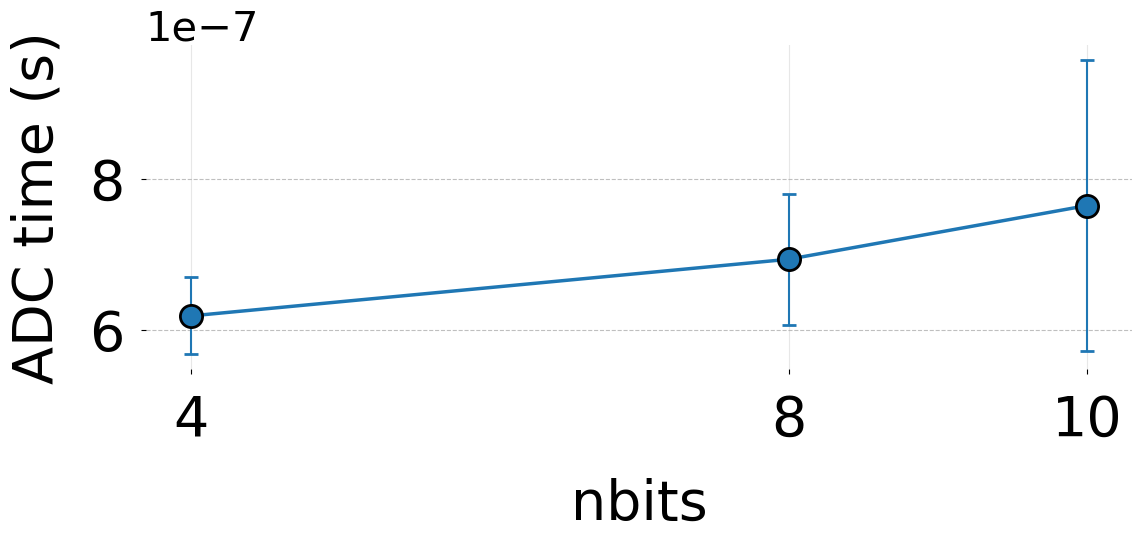

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/adc_time_vs_M_with_config_legend_lsqpp_deep.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/adc_time_vs_M_with_config_legend_lsqpp_deep.svg


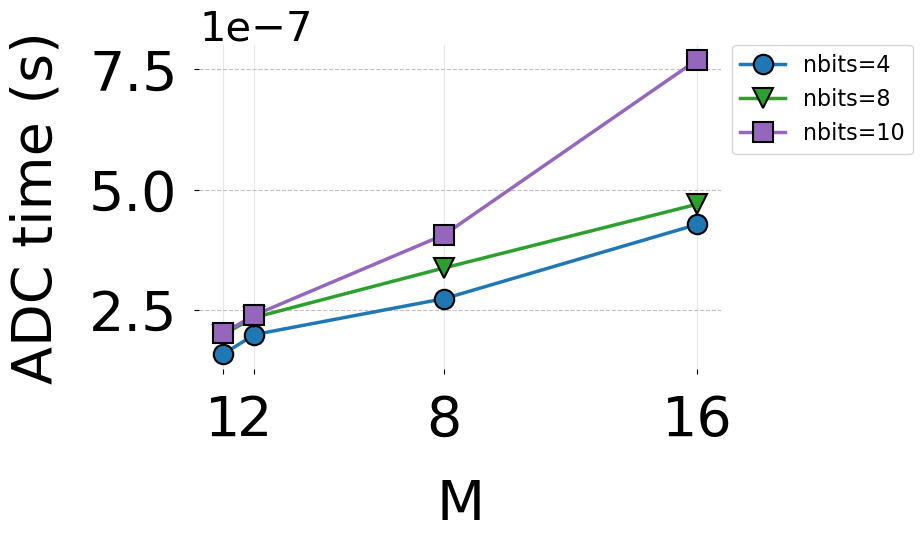

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/adc_time_vs_M_with_config_legend_lsqpp_bigann.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/adc_time_vs_M_with_config_legend_lsqpp_bigann.svg


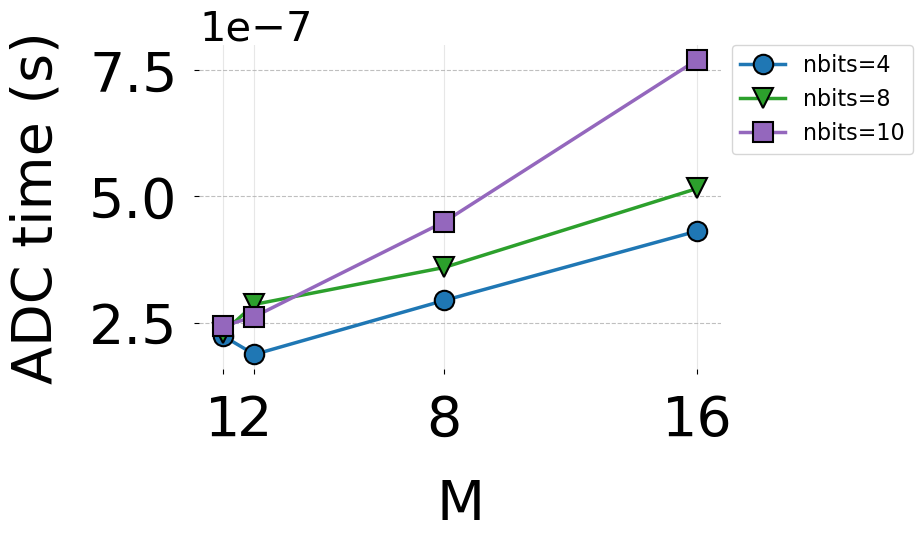

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/adc_time_vs_M_with_config_legend_lsqpp_gist.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/adc_time_vs_M_with_config_legend_lsqpp_gist.svg


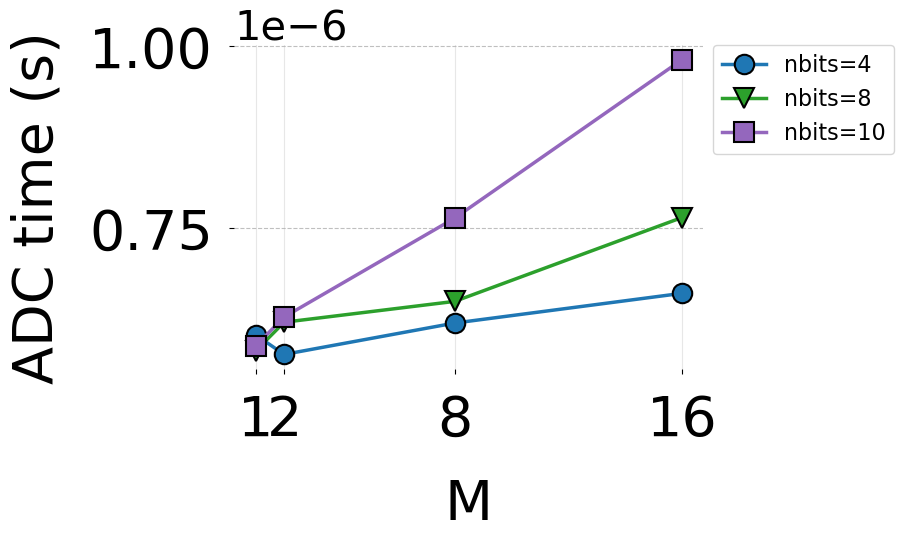

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/adc_time_vs_M_with_config_legend_lsqpp_msmarco.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/adc_time_vs_M_with_config_legend_lsqpp_msmarco.svg


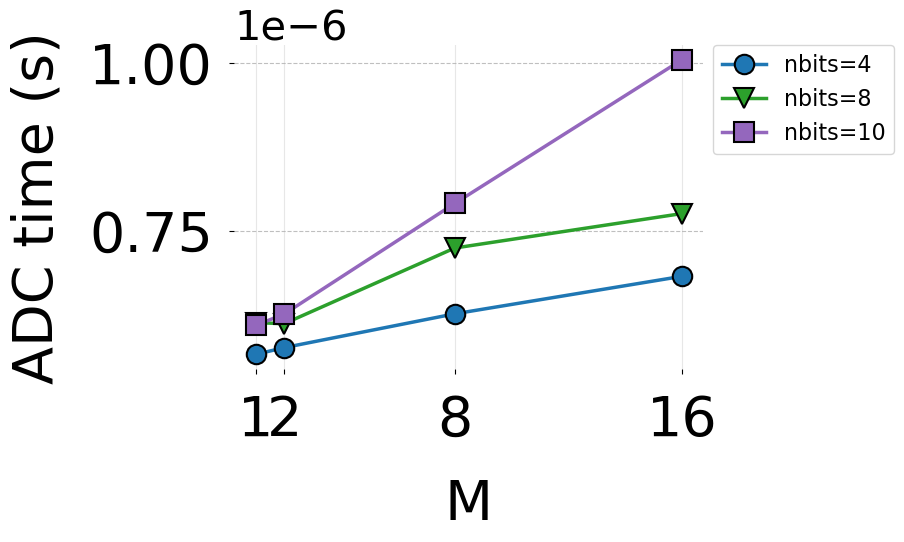

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/adc_time_vs_M_with_config_legend_lsqpp_openai.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/adc_time_vs_M_with_config_legend_lsqpp_openai.svg


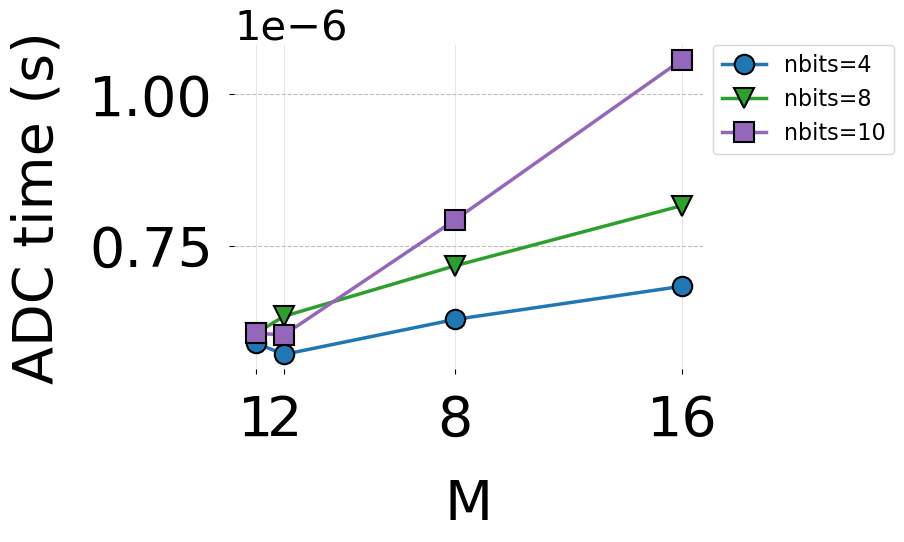

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/adc_time_vs_nbits_with_config_legend_lsqpp_deep.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/adc_time_vs_nbits_with_config_legend_lsqpp_deep.svg


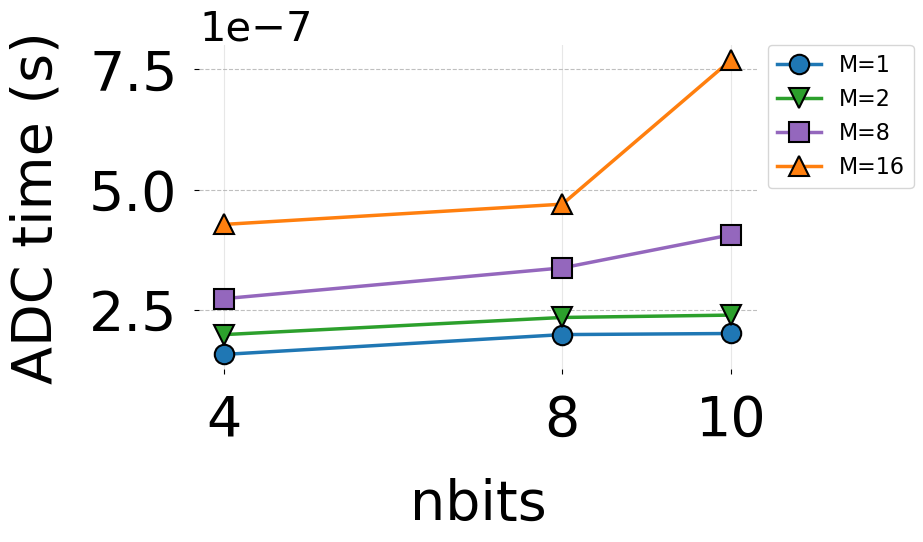

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/adc_time_vs_nbits_with_config_legend_lsqpp_bigann.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/adc_time_vs_nbits_with_config_legend_lsqpp_bigann.svg


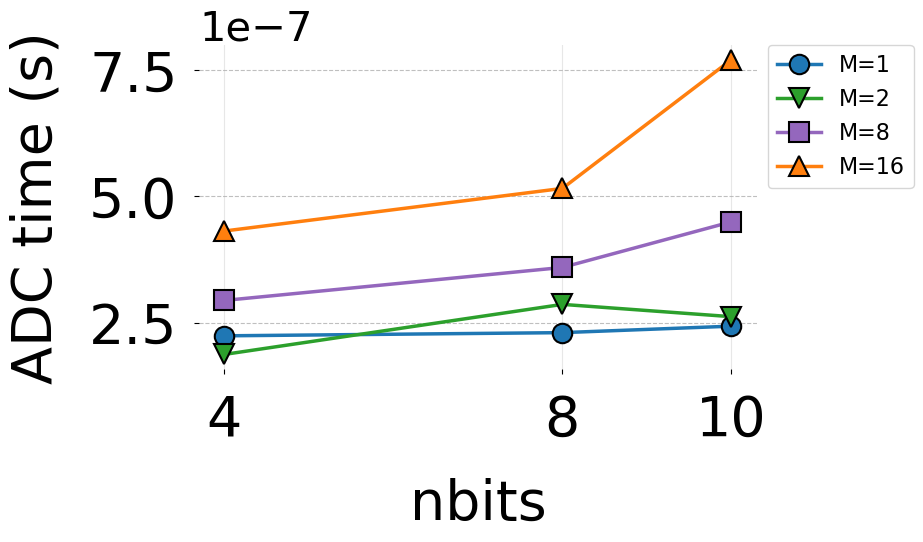

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/adc_time_vs_nbits_with_config_legend_lsqpp_gist.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/adc_time_vs_nbits_with_config_legend_lsqpp_gist.svg


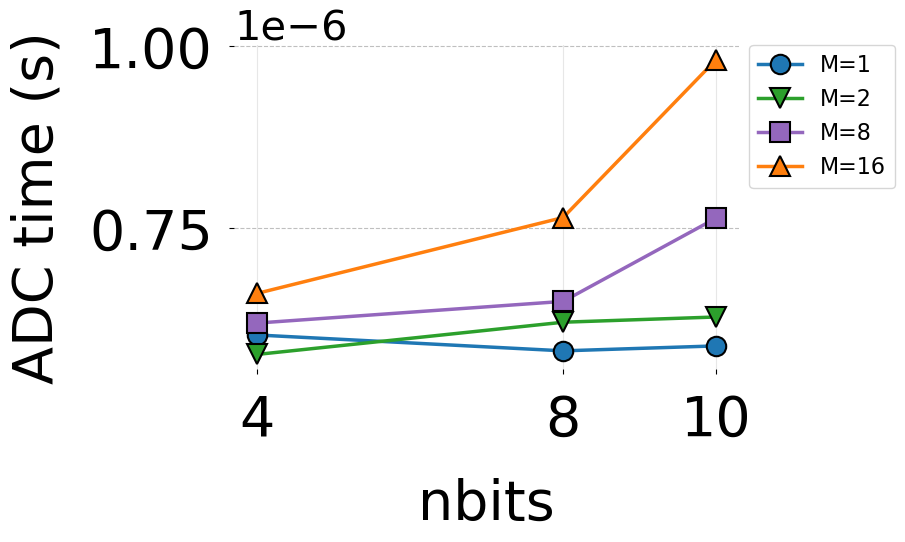

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/adc_time_vs_nbits_with_config_legend_lsqpp_msmarco.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/adc_time_vs_nbits_with_config_legend_lsqpp_msmarco.svg


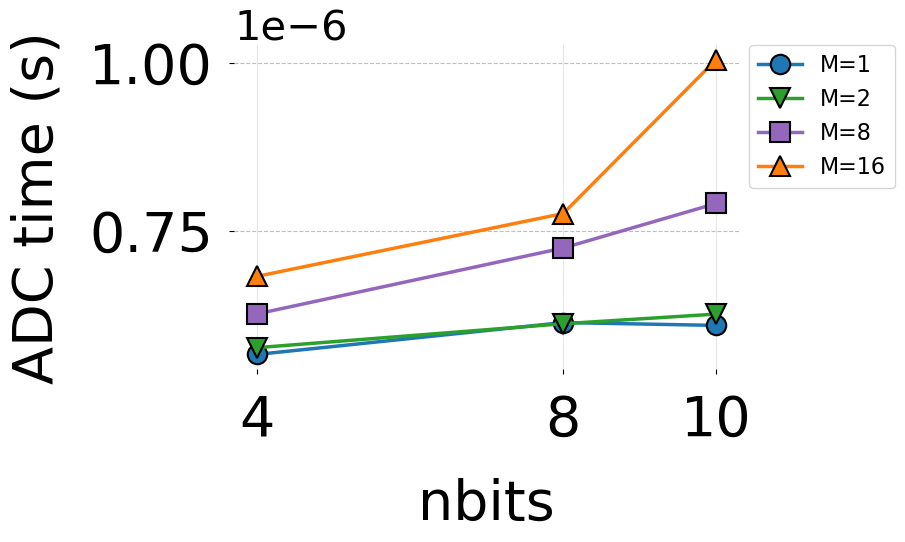

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/adc_time_vs_nbits_with_config_legend_lsqpp_openai.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/adc_time_vs_nbits_with_config_legend_lsqpp_openai.svg


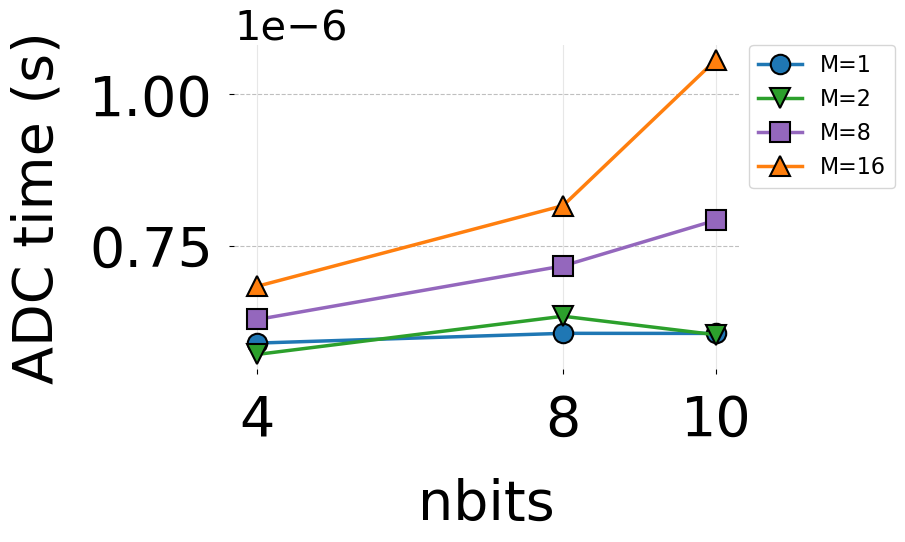

In [21]:
# ADC time vs bits per vector = M * nbits = M * log2(k)
plot_avg_metric_vs_param(
    plot_df,
    x_col="bits_per_vector",
    x_label="Bits per vector",
    y_col=ADC_TIME_COL,
    y_label=ADC_TIME_AXIS_LABEL,
    avg_over=["train_size"],
    output_stem="adc_time_vs_bits_per_vector",
    xtick_count=4,
)

# ADC time vs M, averaged over nbits and train_size
plot_avg_metric_vs_param(
    plot_df,
    x_col="n_subquantizers",
    x_label="M",
    y_col=ADC_TIME_COL,
    y_label=ADC_TIME_AXIS_LABEL,
    avg_over=["nbits", "train_size"],
    output_stem="adc_time_vs_M",
)

# ADC time vs nbits, averaged over M and train_size
plot_avg_metric_vs_param(
    plot_df,
    x_col="nbits",
    x_label="nbits",
    y_col=ADC_TIME_COL,
    y_label=ADC_TIME_AXIS_LABEL,
    avg_over=["n_subquantizers", "train_size"],
    output_stem="adc_time_vs_nbits",
)

# ADC time plots with the other grid parameters shown in the legend
plot_metric_vs_param_with_config_legend(
    plot_df,
    x_col="n_subquantizers",
    x_label="M",
    y_col=ADC_TIME_COL,
    y_label=ADC_TIME_AXIS_LABEL,
    legend_cols=["nbits"],
    output_stem="adc_time_vs_M_with_config_legend",
)

plot_metric_vs_param_with_config_legend(
    plot_df,
    x_col="nbits",
    x_label="nbits",
    y_col=ADC_TIME_COL,
    y_label=ADC_TIME_AXIS_LABEL,
    legend_cols=["n_subquantizers"],
    output_stem="adc_time_vs_nbits_with_config_legend",
)


Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/pareto_relerr_vs_adc_time_lsqpp_deep.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/pareto_relerr_vs_adc_time_lsqpp_deep.svg


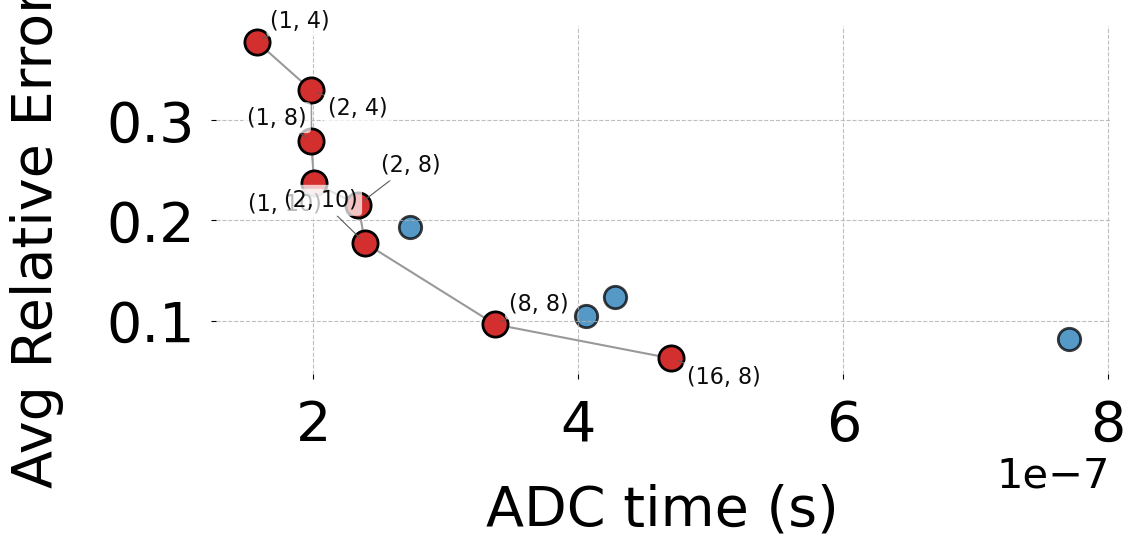

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/pareto_relerr_vs_adc_time_lsqpp_bigann.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/pareto_relerr_vs_adc_time_lsqpp_bigann.svg


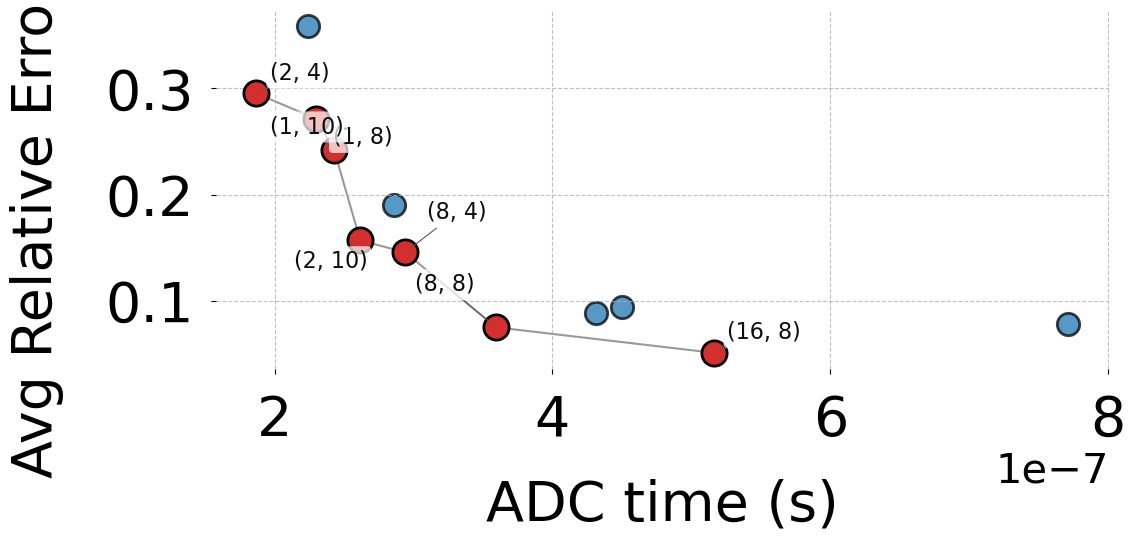

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/pareto_relerr_vs_adc_time_lsqpp_gist.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/pareto_relerr_vs_adc_time_lsqpp_gist.svg


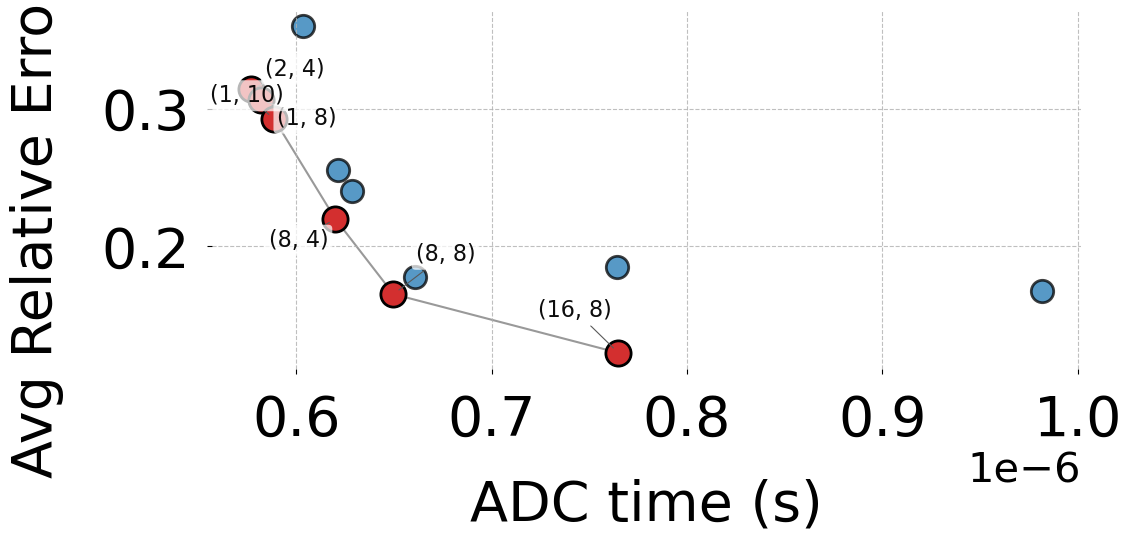

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/pareto_relerr_vs_adc_time_lsqpp_msmarco.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/pareto_relerr_vs_adc_time_lsqpp_msmarco.svg


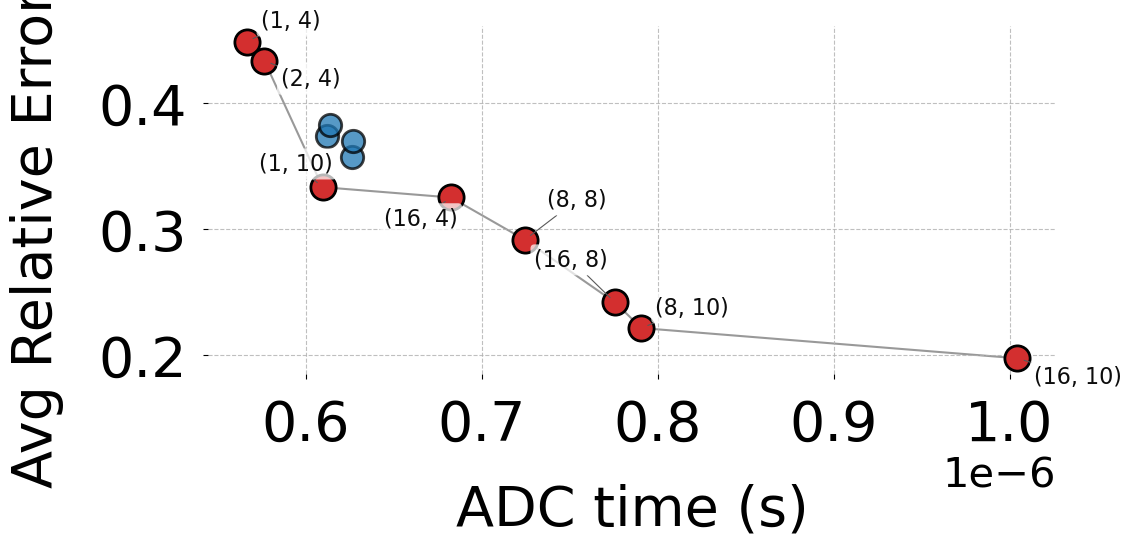

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/pareto_relerr_vs_adc_time_lsqpp_openai.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/pareto_relerr_vs_adc_time_lsqpp_openai.svg


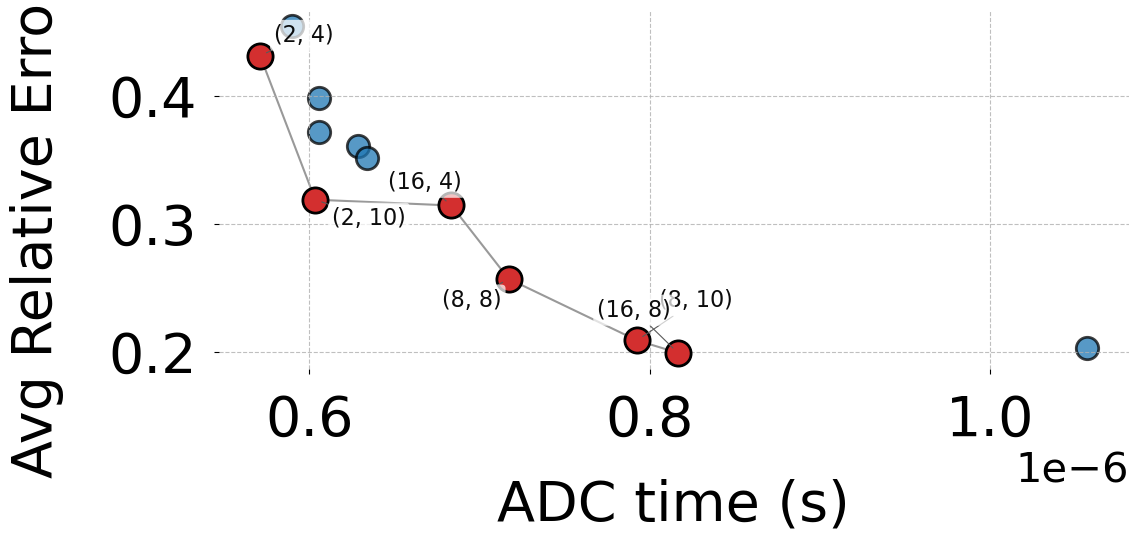

In [22]:
def pareto_frontier_minimize(df: pd.DataFrame, x_col: str, y_col: str) -> pd.DataFrame:
    """Return nondominated lower-left points: lower x and lower y are better."""
    pts = df.sort_values([x_col, y_col]).copy()
    frontier_rows = []
    best_y = np.inf
    for _, row in pts.iterrows():
        if row[y_col] < best_y:
            frontier_rows.append(row)
            best_y = row[y_col]
    if not frontier_rows:
        return pts.iloc[0:0]
    return pd.DataFrame(frontier_rows)


def plot_pareto_adc_vs_metric(
    df: pd.DataFrame,
    y_col: str,
    y_label: str,
    output_stem: str,
    datasets=DATASETS_TO_PLOT,
    methods=METHODS_TO_PLOT,
    output_dir: Path = FIGURES_DIR,
):
    for method in methods:
        for dataset in datasets:
            sub = df[(df["method"] == method) & (df["dataset"] == dataset)].dropna(subset=[ADC_TIME_COL, y_col]).copy()
            if sub.empty:
                continue

            # One point per (M, nbits): average over train_size and duplicate rows.
            agg = (
                sub.groupby(["n_subquantizers", "nbits", "bits_per_vector"], as_index=False)
                .agg({ADC_TIME_COL: "mean", y_col: "mean", "train_size": "mean"})
                .sort_values([ADC_TIME_COL, y_col])
            )
            frontier = pareto_frontier_minimize(agg, ADC_TIME_COL, y_col)

            fig, ax = plt.subplots()
            ax.scatter(
                agg[ADC_TIME_COL], agg[y_col],
                color="tab:blue", marker="o", s=260,
                edgecolors="black", linewidths=2, alpha=0.75,
            )
            if len(frontier) > 0:
                ax.plot(frontier[ADC_TIME_COL], frontier[y_col], "-", color="gray", linewidth=1.5, alpha=0.8, zorder=1)
                ax.scatter(
                    frontier[ADC_TIME_COL], frontier[y_col],
                    color="#D32F2F", marker="o", s=330,
                    edgecolors="black", linewidths=2, zorder=3,
                )

            label_offsets = [(10, 10), (12, -18), (-46, 12), (-48, -20), (16, 24), (-58, 26)]
            for idx, (_, row) in enumerate(frontier.iterrows()):
                label = f"({int(row['n_subquantizers'])}, {int(row['nbits'])})"
                offset = label_offsets[idx % len(label_offsets)]
                ax.annotate(
                    label,
                    (row[ADC_TIME_COL], row[y_col]),
                    xytext=offset, textcoords="offset points",
                    fontsize=16, color="black", alpha=0.95,
                    bbox=dict(boxstyle="round,pad=0.18", fc="white", ec="none", alpha=0.72),
                    arrowprops=dict(arrowstyle="-", color="0.35", lw=0.8, shrinkA=0, shrinkB=5),
                    zorder=4,
                )

            ax.set_xlabel(ADC_TIME_AXIS_LABEL, fontsize=40)
            ax.set_ylabel(y_label, fontsize=40)
            adjust_ylabel_position(ax, y_label)
            style_axes(ax, tick_fontsize=40, grid_axis="both")
            set_sci_axes(ax)
            if y_col == "rel_error_mean":
                ax.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))
            plt.tight_layout(pad=1.4)
            stem = f"{output_stem}_{method.lower()}_{dataset}"
            save_figure(fig, output_dir, stem)
            plt.show()
            plt.close(fig)

plot_pareto_adc_vs_metric(
    plot_df,
    y_col="rel_error_mean",
    y_label="Avg Relative Error",
    output_stem="pareto_relerr_vs_adc_time",
)


## Avg Distortion

The LSQ++ evaluation script did not save trained Faiss LSQ models or reconstruction-error rows. This section therefore uses cached files named `{dataset}_LSQpp_reconstruction_error.csv` if they exist. If they are missing, set `COMPUTE_MISSING_DISTORTION = True` and run the compute cell; it retrains LSQ++ for each successful config and caches the mean reconstruction distortion over the first `DISTORTION_MAX_SAMPLES` database vectors.

Distortion here is `mean ||x - x_hat||_2`, matching the reconstruction-error convention in `scripts/evals/run_evals.py`.


In [23]:
COMPUTE_MISSING_DISTORTION = False
DISTORTION_MAX_SAMPLES = 10_000
DISTORTION_Y_COL = "distortion_error"
DISTORTION_Y_LABEL = "Avg Distortion"

# Use the same Faiss-enabled Python environment when running this notebook kernel.
# If `import faiss` fails, start the notebook with:
# /home/cpanourg/.miniconda3/envs/dtwrl_env2/bin/python


In [24]:
def _dataset_paths(dataset: str):
    data_root = Path("/data/cpanourg/2-hdvc/data")
    if dataset == "deep":
        return {
            "dataset_path": data_root / "deep1b/dataset/test_1m.bin",
            "train_path": data_root / "deep1b/dataset/learn_100m.bin",
            "query_path": data_root / "deep1b/dataset/query_10k.bin",
            "dim": 96,
        }
    if dataset == "bigann":
        return {
            "dataset_path": data_root / "bigann/SIFT1M/bigann_base.bvecs",
            "train_path": data_root / "bigann/SIFT1M/bigann_learn.bvecs",
            "query_path": data_root / "bigann/SIFT1M/bigann_query.bvecs",
            "dim": 128,
        }
    if dataset == "gist":
        return {
            "dataset_path": data_root / "gist/gist_base.fvecs",
            "train_path": data_root / "gist/gist_learn.fvecs",
            "query_path": data_root / "gist/gist_query.fvecs",
            "dim": 960,
        }
    if dataset == "msmarco":
        return {
            "dataset_path": data_root / "msmarco/base1m.fvecs",
            "train_path": data_root / "msmarco/train1m.fvecs",
            "query_path": data_root / "msmarco/query10k.fvecs",
            "dim": 1024,
        }
    if dataset == "openai":
        return {
            "dataset_path": data_root / "openai/openai_base1m.fvecs",
            "train_path": data_root / "openai/openai_train1m.fvecs",
            "query_path": data_root / "openai/openai_query10k.fvecs",
            "dim": 1536,
        }
    raise ValueError(dataset)


def _distortion_csv_path(dataset: str) -> Path:
    return DATA_DIR / f"{dataset}_LSQpp_reconstruction_error.csv"


def load_cached_distortion(data_dir: Path = DATA_DIR) -> pd.DataFrame:
    frames = []
    for dataset in DATASETS_TO_PLOT:
        path = _distortion_csv_path(dataset)
        if path.exists():
            frames.append(pd.read_csv(path))
    if not frames:
        return pd.DataFrame()
    df = pd.concat(frames, ignore_index=True)
    df["method"] = df.get("method", "LSQpp")
    for col in ["n_subquantizers", "nbits", "bits_per_vector", "train_size", "reconstruction_error"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    df[DISTORTION_Y_COL] = df["reconstruction_error"]
    df["k_centroids"] = 2 ** df["nbits"].astype(int)
    return aggregate_metric_df(df, y_cols=(DISTORTION_Y_COL, "reconstruction_error"))


distortion_plot_df = load_cached_distortion(DATA_DIR)
if distortion_plot_df.empty:
    print("No cached LSQ++ distortion CSVs found yet. Set COMPUTE_MISSING_DISTORTION=True and run the next cell to create them.")
else:
    display(distortion_plot_df.head())


,method,dataset,n_subquantizers,nbits,bits_per_vector,train_size,distortion_error,reconstruction_error,nb_sample,k_centroids
0,LSQpp,bigann,1,4,4,10000,317.112000,317.112000,10000.0,16.0
1,LSQpp,bigann,1,4,4,20000,316.869965,316.869965,10000.0,16.0
2,LSQpp,bigann,1,4,4,50000,315.871185,315.871185,10000.0,16.0
3,LSQpp,bigann,1,4,4,100000,317.127655,317.127655,10000.0,16.0
4,LSQpp,bigann,1,8,8,10000,280.228149,280.228149,10000.0,256.0


In [25]:
def compute_lsqpp_distortion_for_row(row, max_samples: int = DISTORTION_MAX_SAMPLES):
    """Retrain LSQ++ for one row and compute mean ||x - x_hat||_2 on first max_samples DB vectors."""
    import faiss
    from lsqpp.data_io import load_vectors_prefix
    from lsqpp.eval import _unpack_lsq_codes

    dataset = row["dataset"]
    paths = _dataset_paths(dataset)
    dim = int(paths["dim"])
    M = int(row["n_subquantizers"])
    nbits = int(row["nbits"])
    train_size = int(row["train_size"])
    ksub = 1 << nbits

    train_db = load_vectors_prefix(str(paths["train_path"]), dim, train_size, 0)
    db_sample = load_vectors_prefix(str(paths["dataset_path"]), dim, max_samples, 0)

    lsq = faiss.LocalSearchQuantizer(dim, M, nbits, faiss.LocalSearchQuantizer.ST_norm_qint8)
    t0 = time.perf_counter()
    lsq.train(train_db)
    train_time = time.perf_counter() - t0

    t0 = time.perf_counter()
    codes_u8 = np.asarray(lsq.compute_codes(db_sample), dtype=np.uint8)
    codes_ix = _unpack_lsq_codes(codes_u8, M, nbits)
    code_time = time.perf_counter() - t0

    codebooks = np.ascontiguousarray(
        faiss.vector_to_array(lsq.codebooks).reshape(M, ksub, dim), dtype=np.float32
    )
    # Additive reconstruction: x_hat_i = sum_m C_m[codes_i,m].
    recon = np.zeros_like(db_sample, dtype=np.float32)
    for m in range(M):
        recon += codebooks[m, codes_ix[:, m]]
    distortion = np.linalg.norm(db_sample.astype(np.float32) - recon, axis=1).mean()

    out = row.to_dict()
    out.update({
        "method": "LSQpp",
        "reconstruction_error": float(distortion),
        "distortion_error": float(distortion),
        "reconstruction_error_time_s": float(train_time + code_time),
        "distortion_max_samples": int(max_samples),
    })
    return out


def compute_missing_distortion_csvs(plot_df: pd.DataFrame, data_dir: Path = DATA_DIR):
    if not COMPUTE_MISSING_DISTORTION:
        print("COMPUTE_MISSING_DISTORTION is False; not computing missing distortion CSVs.")
        return

    for dataset in DATASETS_TO_PLOT:
        out_path = _distortion_csv_path(dataset)
        done = set()
        if out_path.exists():
            existing = pd.read_csv(out_path)
            for _, r in existing.iterrows():
                done.add((int(r["n_subquantizers"]), int(r["nbits"]), int(r["train_size"])))
        else:
            existing = pd.DataFrame()

        rows = []
        sub = plot_df[plot_df["dataset"] == dataset].sort_values(["n_subquantizers", "nbits", "train_size"])
        for _, row in sub.iterrows():
            key = (int(row["n_subquantizers"]), int(row["nbits"]), int(row["train_size"]))
            if key in done:
                continue
            print(f"Computing LSQ++ distortion for {dataset}: M={key[0]} nbits={key[1]} train={key[2]}")
            try:
                rows.append(compute_lsqpp_distortion_for_row(row))
            except Exception as exc:
                print(f"FAILED {dataset} {key}: {exc}")

        if rows:
            new = pd.DataFrame(rows)
            combined = pd.concat([existing, new], ignore_index=True) if not existing.empty else new
            combined.to_csv(out_path, index=False)
            print(f"Wrote {out_path}")
        else:
            print(f"No new distortion rows for {dataset}")

compute_missing_distortion_csvs(plot_df, DATA_DIR)
distortion_plot_df = load_cached_distortion(DATA_DIR)
if not distortion_plot_df.empty:
    display(distortion_plot_df.head())


COMPUTE_MISSING_DISTORTION is False; not computing missing distortion CSVs.


,method,dataset,n_subquantizers,nbits,bits_per_vector,train_size,distortion_error,reconstruction_error,nb_sample,k_centroids
0,LSQpp,bigann,1,4,4,10000,317.112000,317.112000,10000.0,16.0
1,LSQpp,bigann,1,4,4,20000,316.869965,316.869965,10000.0,16.0
2,LSQpp,bigann,1,4,4,50000,315.871185,315.871185,10000.0,16.0
3,LSQpp,bigann,1,4,4,100000,317.127655,317.127655,10000.0,16.0
4,LSQpp,bigann,1,8,8,10000,280.228149,280.228149,10000.0,256.0


Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_M_lsqpp_deep.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_M_lsqpp_deep.svg


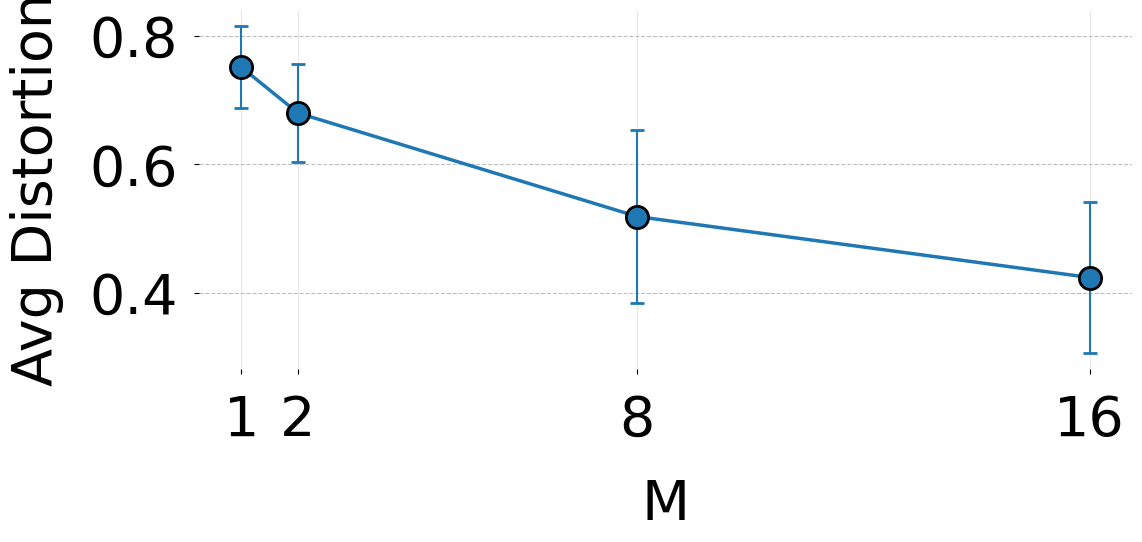

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_M_lsqpp_bigann.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_M_lsqpp_bigann.svg


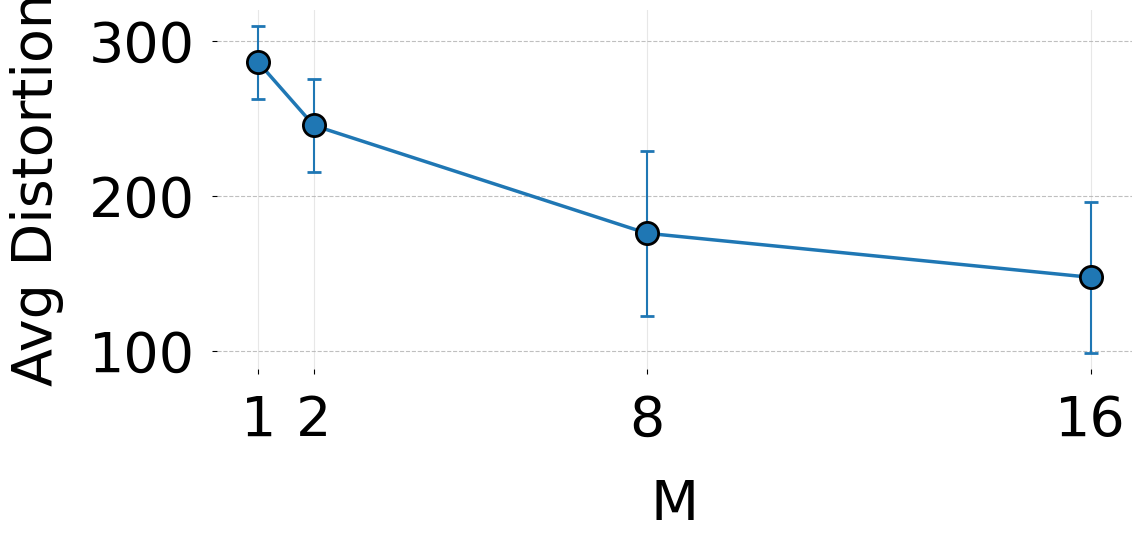

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_M_lsqpp_gist.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_M_lsqpp_gist.svg


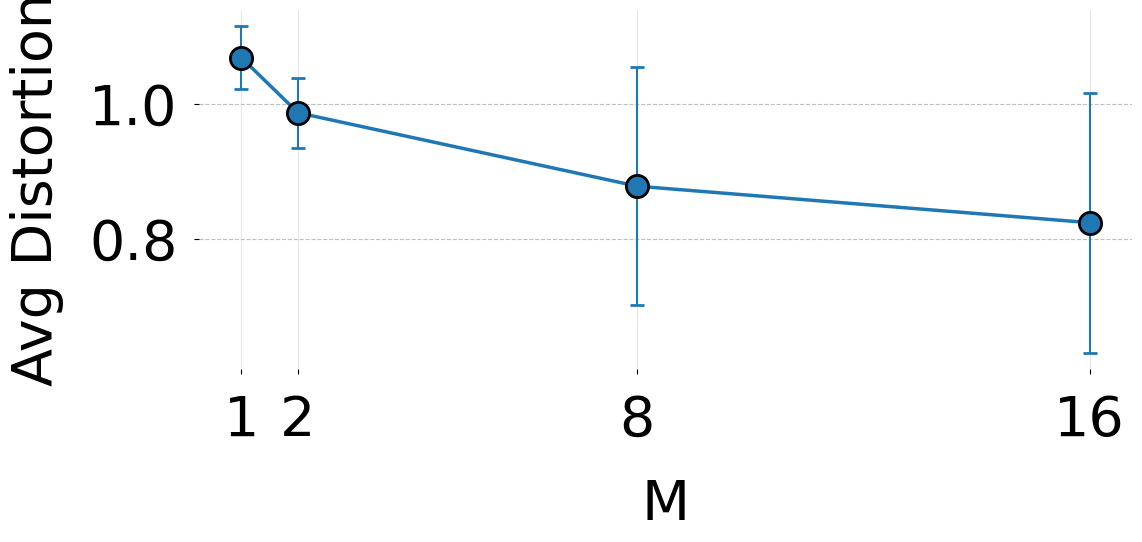

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_M_lsqpp_msmarco.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_M_lsqpp_msmarco.svg


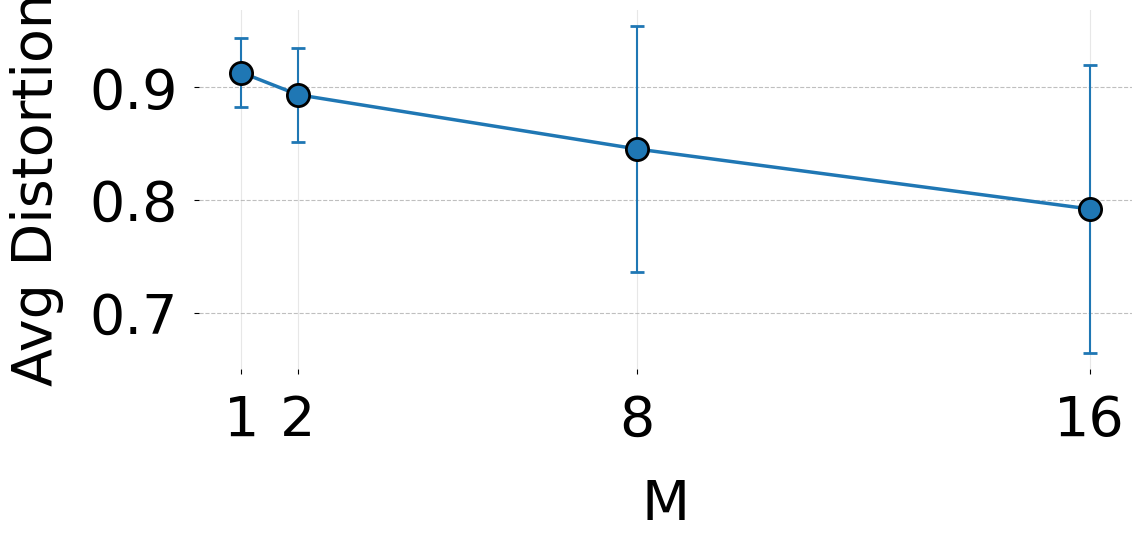

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_M_lsqpp_openai.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_M_lsqpp_openai.svg


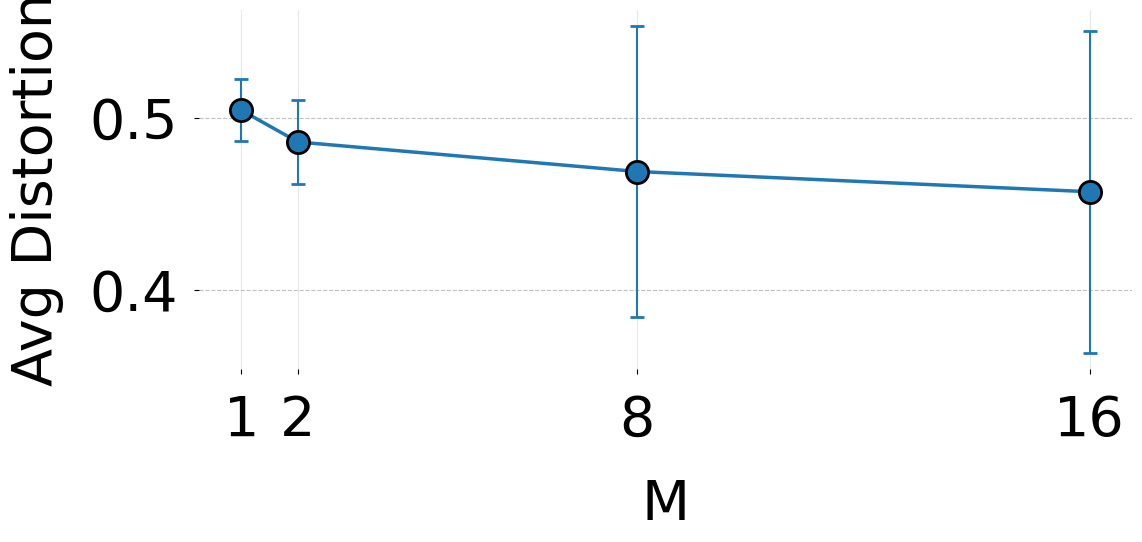

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_nbits_lsqpp_deep.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_nbits_lsqpp_deep.svg


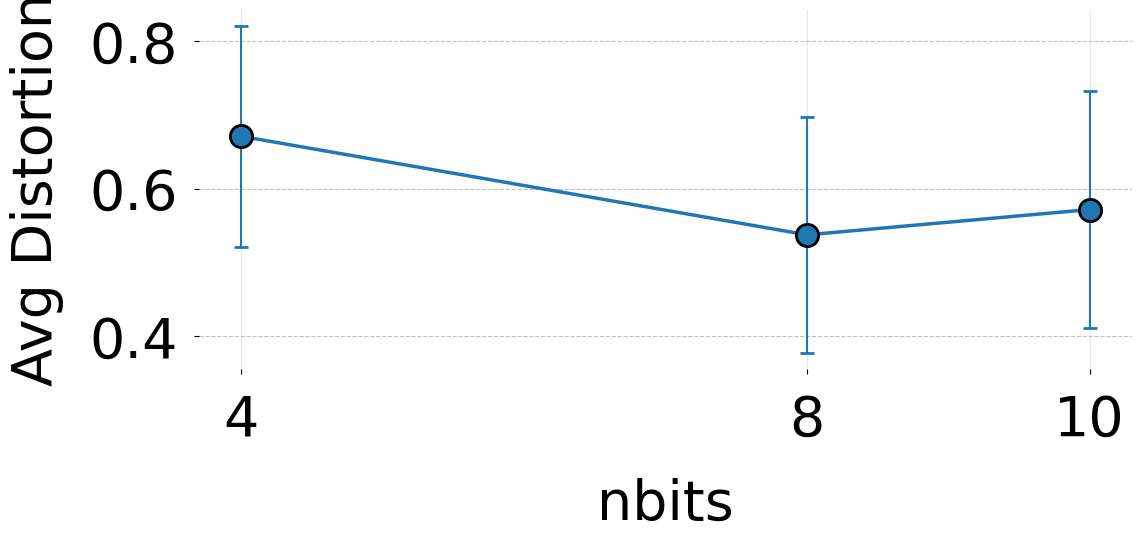

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_nbits_lsqpp_bigann.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_nbits_lsqpp_bigann.svg


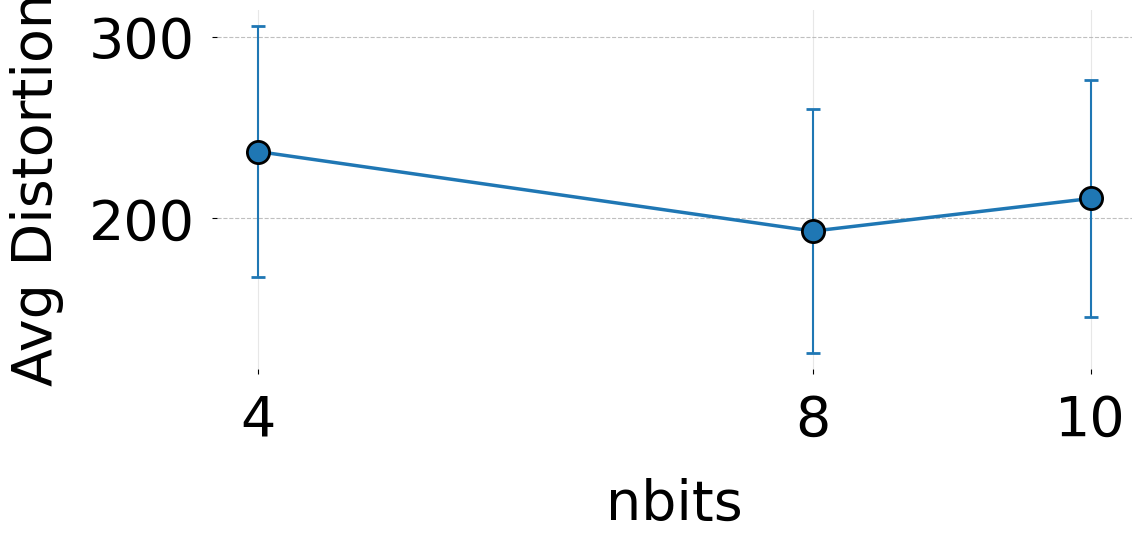

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_nbits_lsqpp_gist.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_nbits_lsqpp_gist.svg


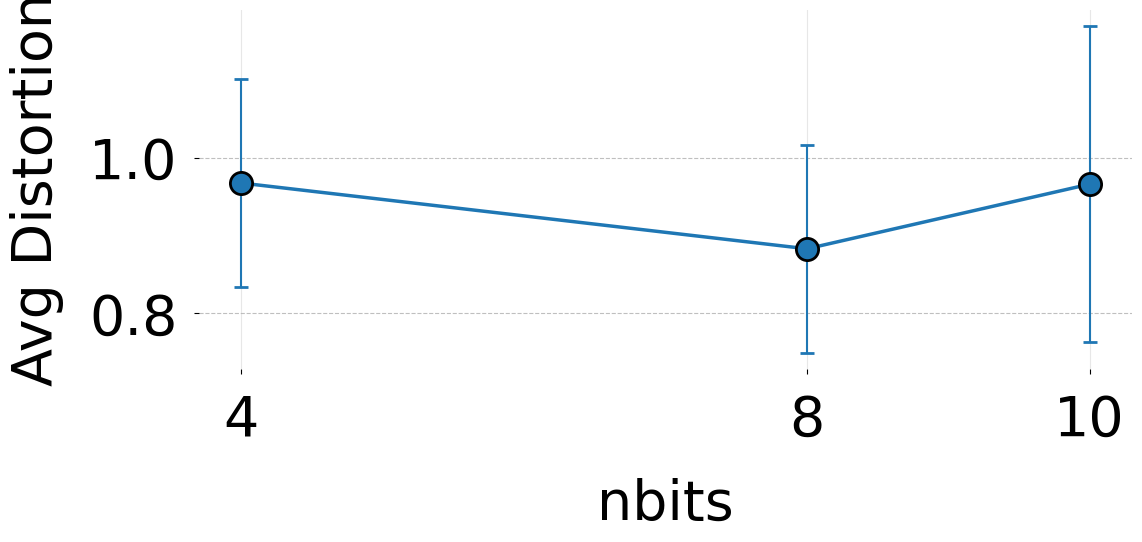

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_nbits_lsqpp_msmarco.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_nbits_lsqpp_msmarco.svg


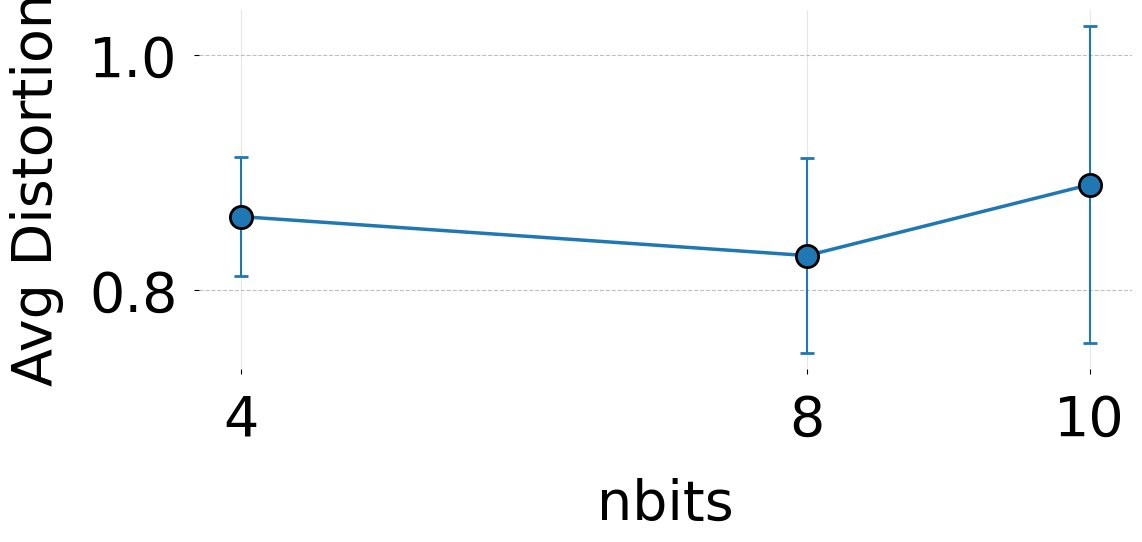

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_nbits_lsqpp_openai.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_nbits_lsqpp_openai.svg


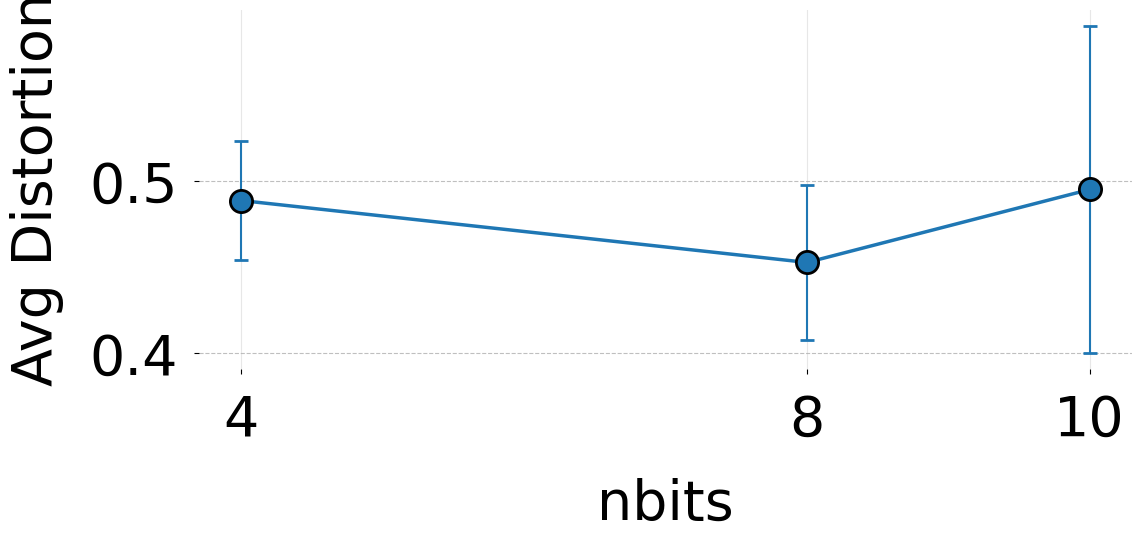

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_train_size_lsqpp_deep.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_train_size_lsqpp_deep.svg


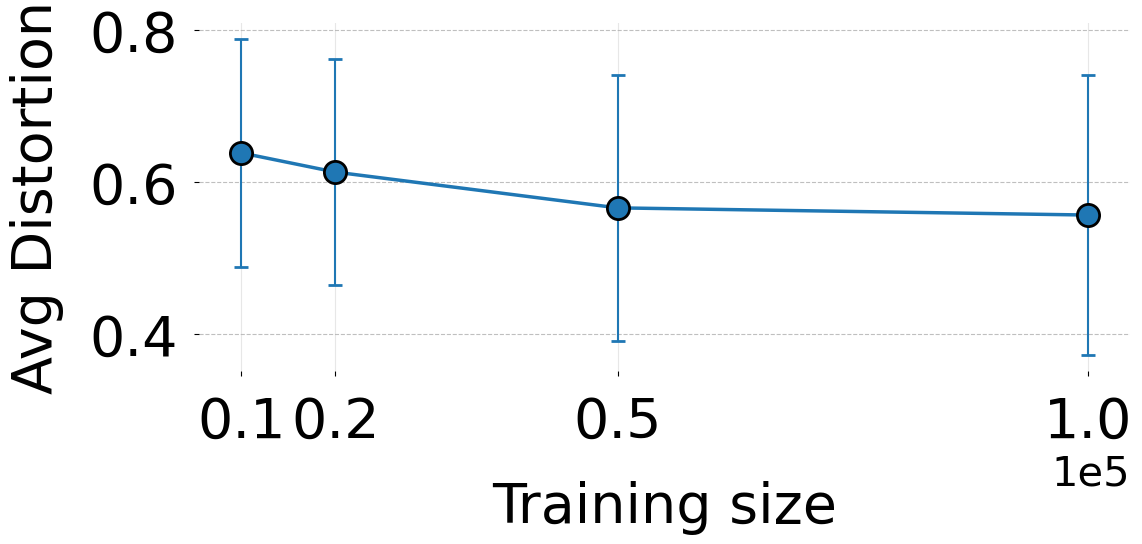

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_train_size_lsqpp_bigann.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_train_size_lsqpp_bigann.svg


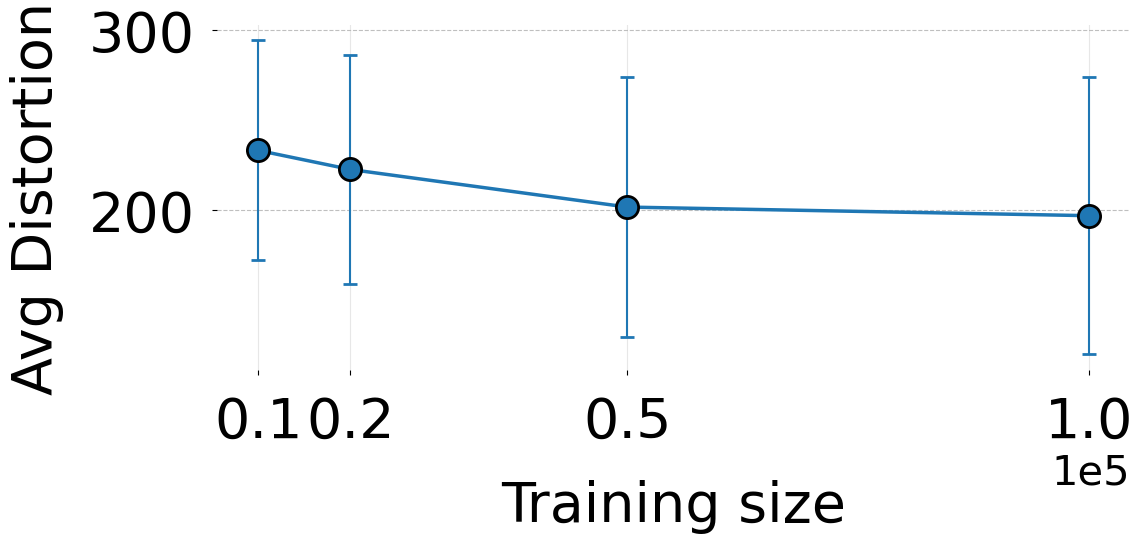

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_train_size_lsqpp_gist.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_train_size_lsqpp_gist.svg


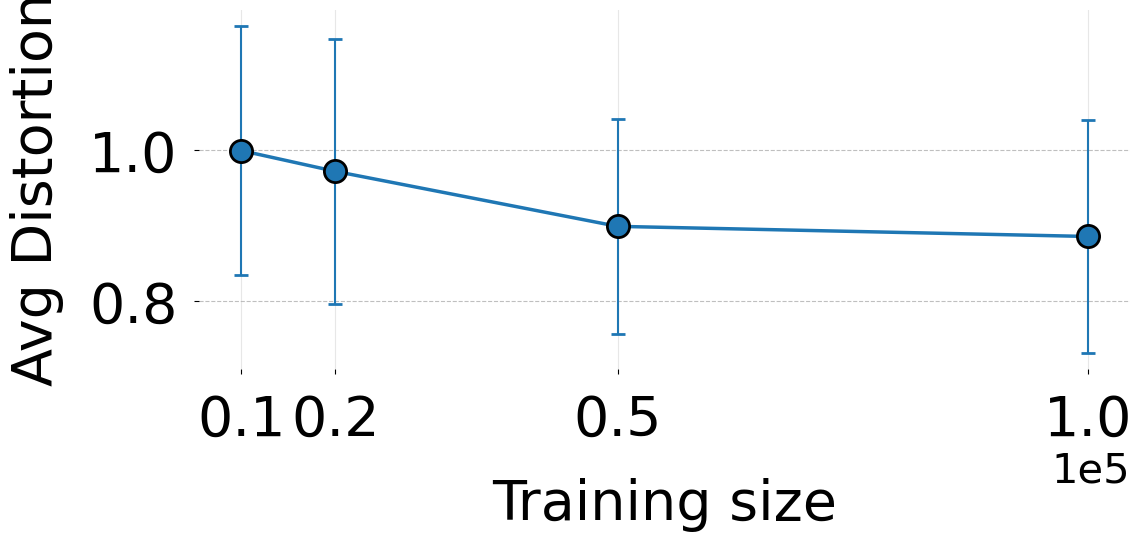

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_train_size_lsqpp_msmarco.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_train_size_lsqpp_msmarco.svg


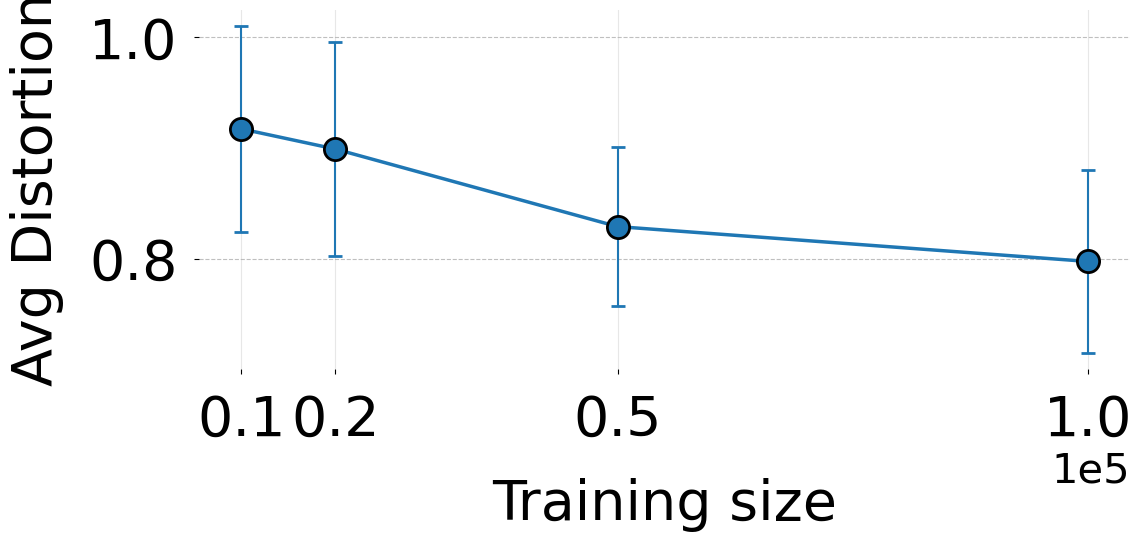

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_train_size_lsqpp_openai.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_train_size_lsqpp_openai.svg


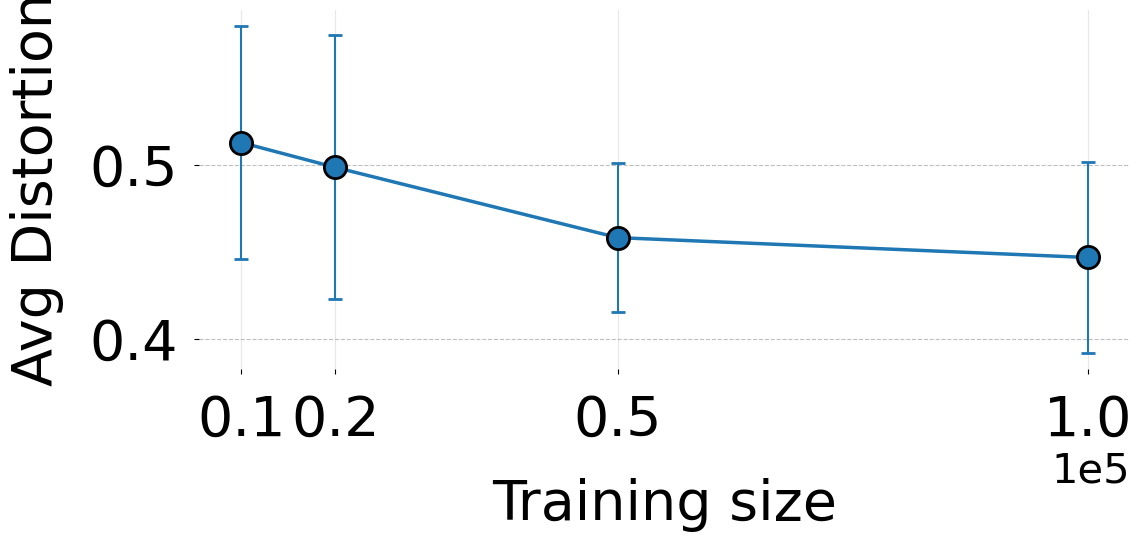

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_M_with_config_legend_lsqpp_deep.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_M_with_config_legend_lsqpp_deep.svg


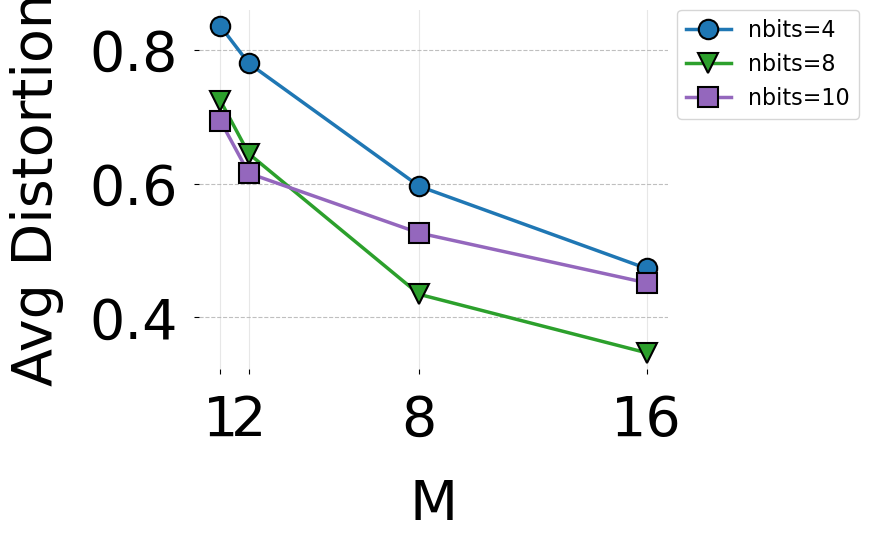

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_M_with_config_legend_lsqpp_bigann.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_M_with_config_legend_lsqpp_bigann.svg


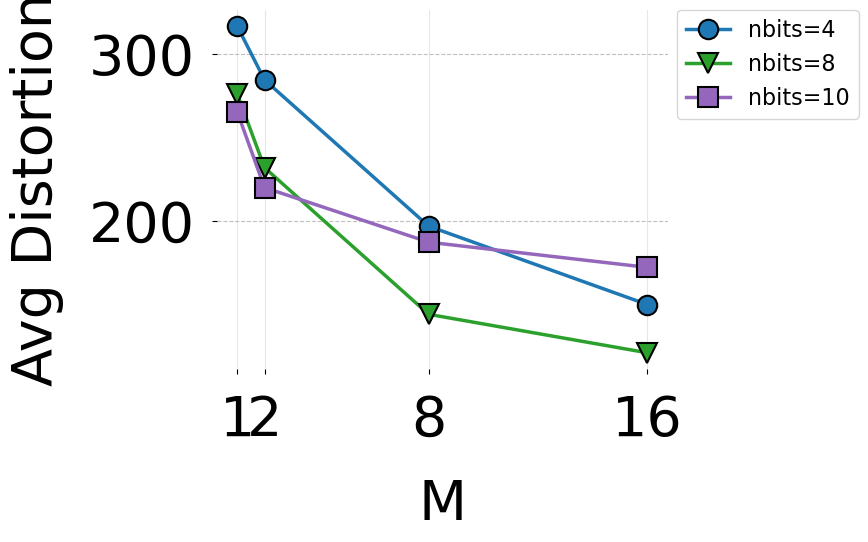

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_M_with_config_legend_lsqpp_gist.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_M_with_config_legend_lsqpp_gist.svg


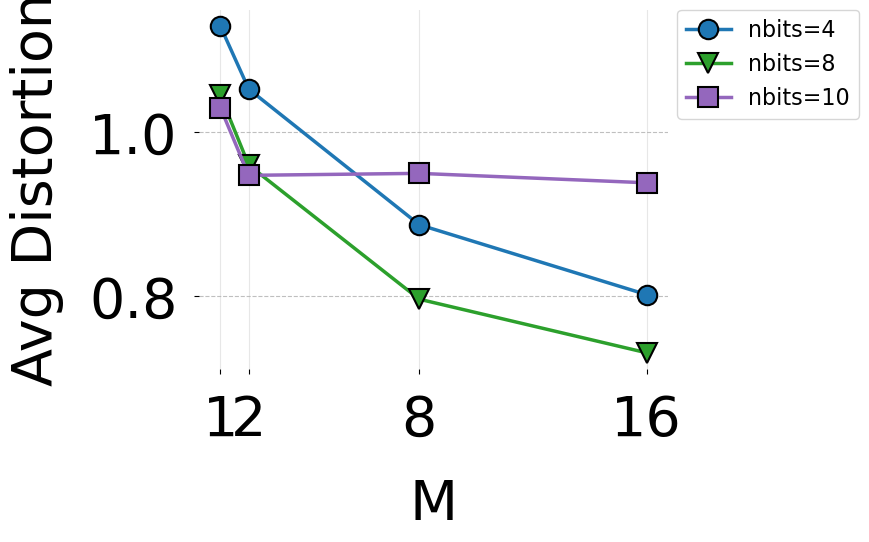

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_M_with_config_legend_lsqpp_msmarco.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_M_with_config_legend_lsqpp_msmarco.svg


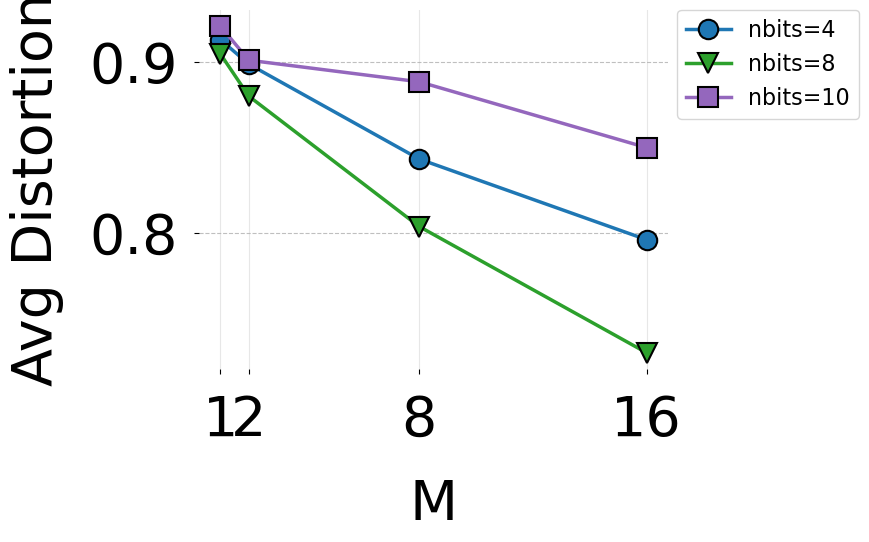

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_M_with_config_legend_lsqpp_openai.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_M_with_config_legend_lsqpp_openai.svg


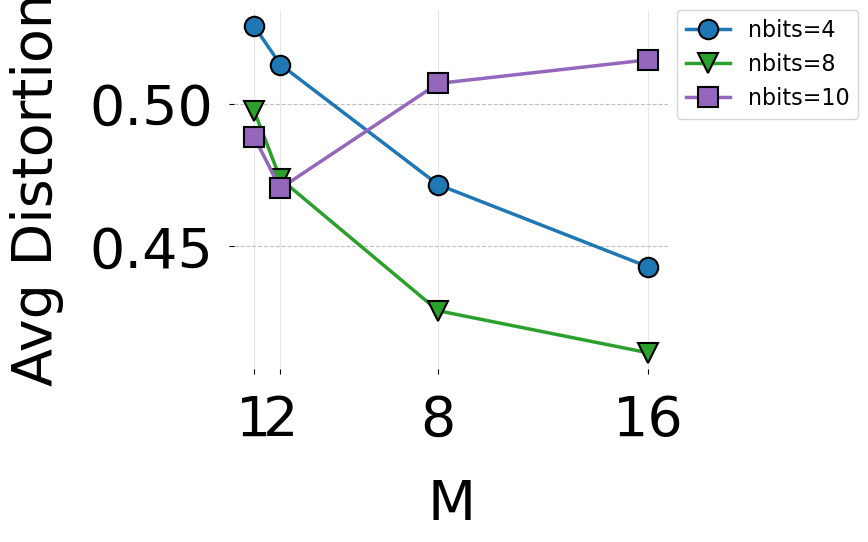

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_nbits_with_config_legend_lsqpp_deep.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_nbits_with_config_legend_lsqpp_deep.svg


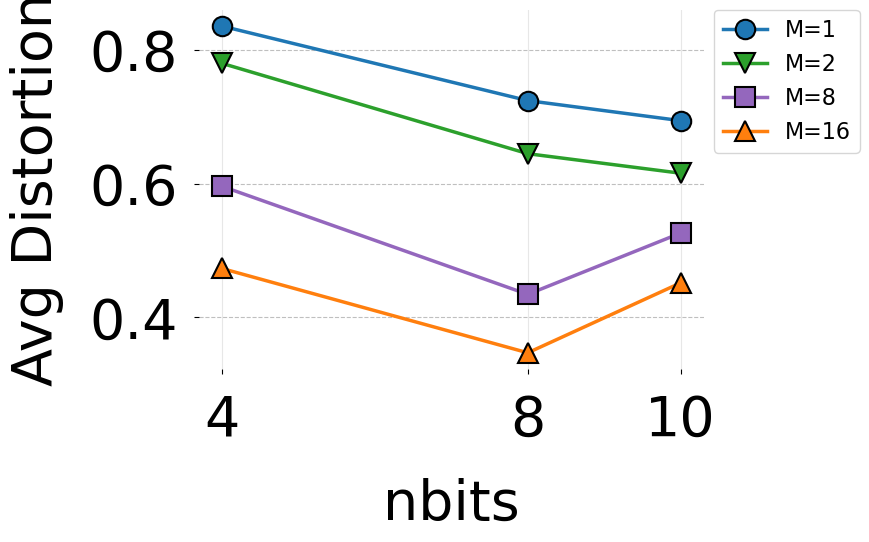

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_nbits_with_config_legend_lsqpp_bigann.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_nbits_with_config_legend_lsqpp_bigann.svg


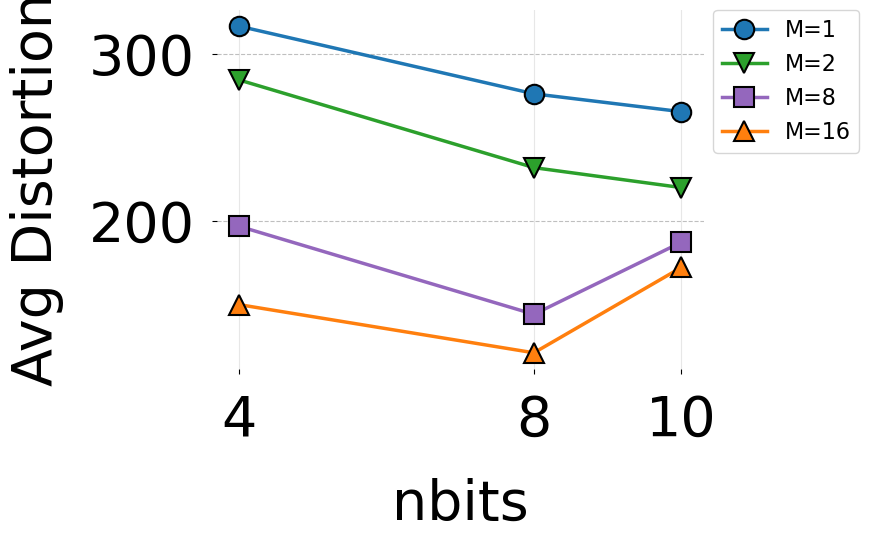

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_nbits_with_config_legend_lsqpp_gist.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_nbits_with_config_legend_lsqpp_gist.svg


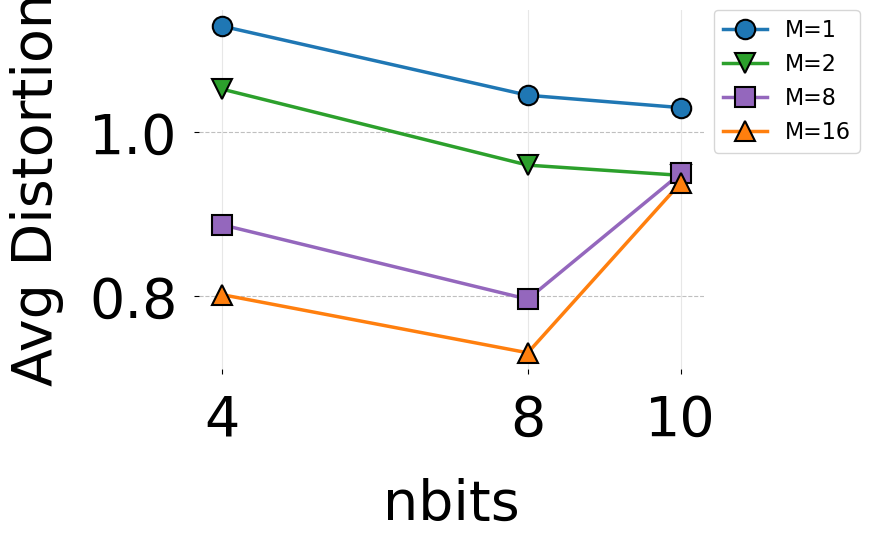

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_nbits_with_config_legend_lsqpp_msmarco.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_nbits_with_config_legend_lsqpp_msmarco.svg


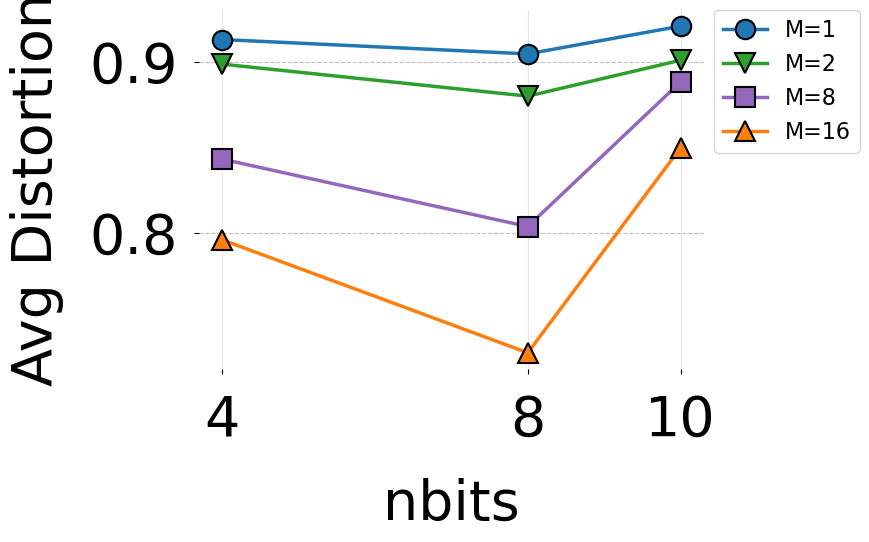

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_nbits_with_config_legend_lsqpp_openai.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_nbits_with_config_legend_lsqpp_openai.svg


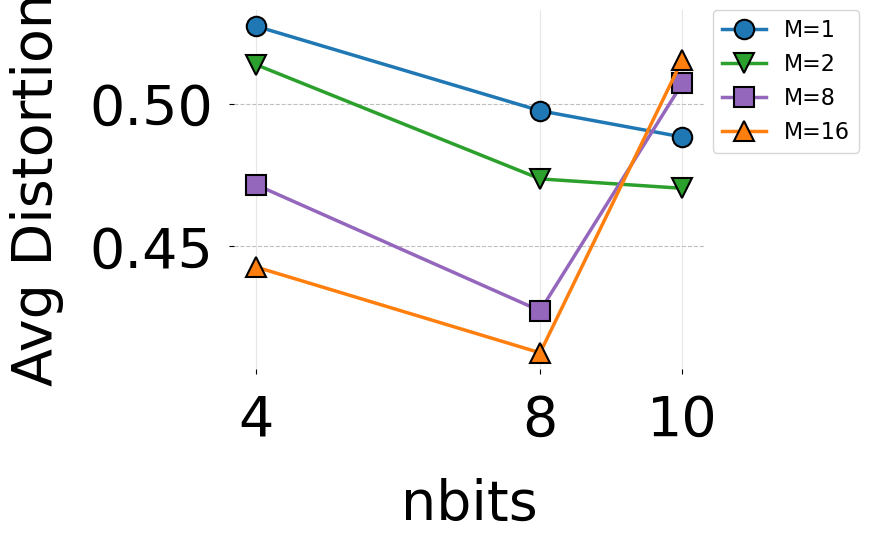

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_train_size_legend_M_lsqpp_deep.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_train_size_legend_M_lsqpp_deep.svg


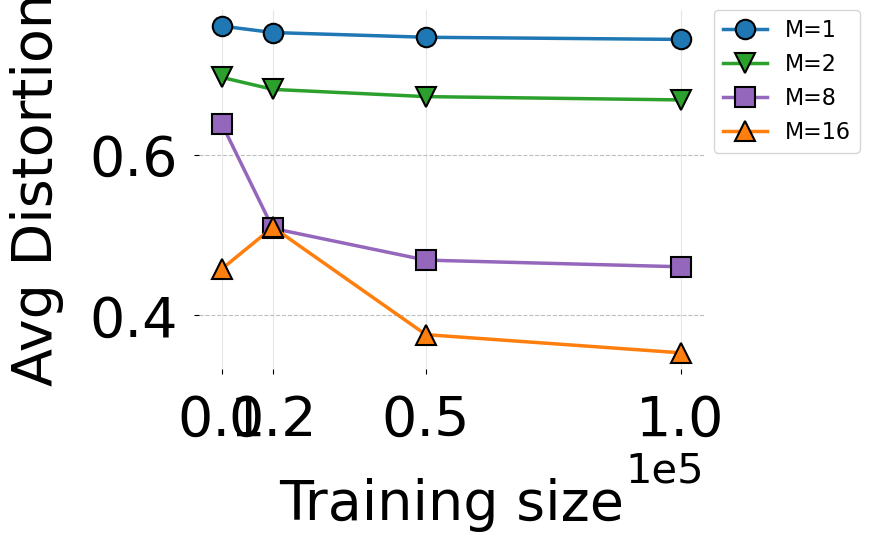

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_train_size_legend_M_lsqpp_bigann.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_train_size_legend_M_lsqpp_bigann.svg


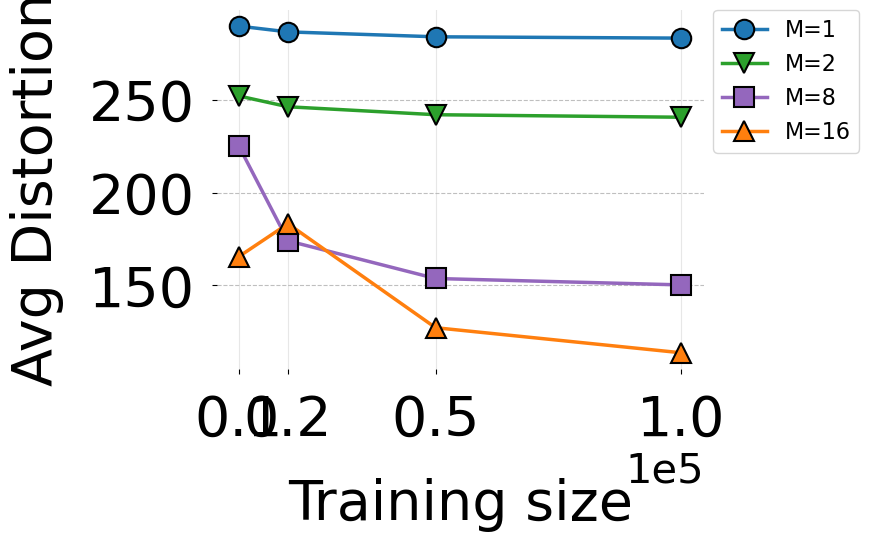

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_train_size_legend_M_lsqpp_gist.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_train_size_legend_M_lsqpp_gist.svg


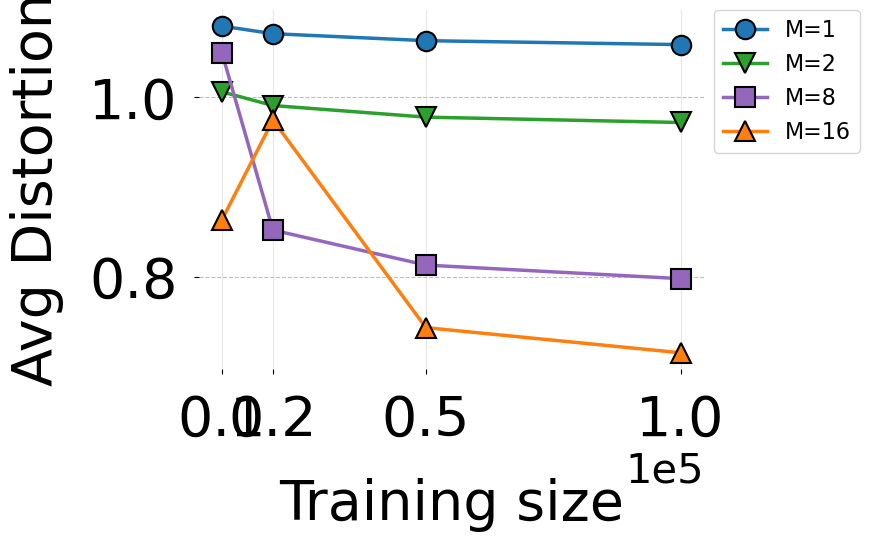

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_train_size_legend_M_lsqpp_msmarco.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_train_size_legend_M_lsqpp_msmarco.svg


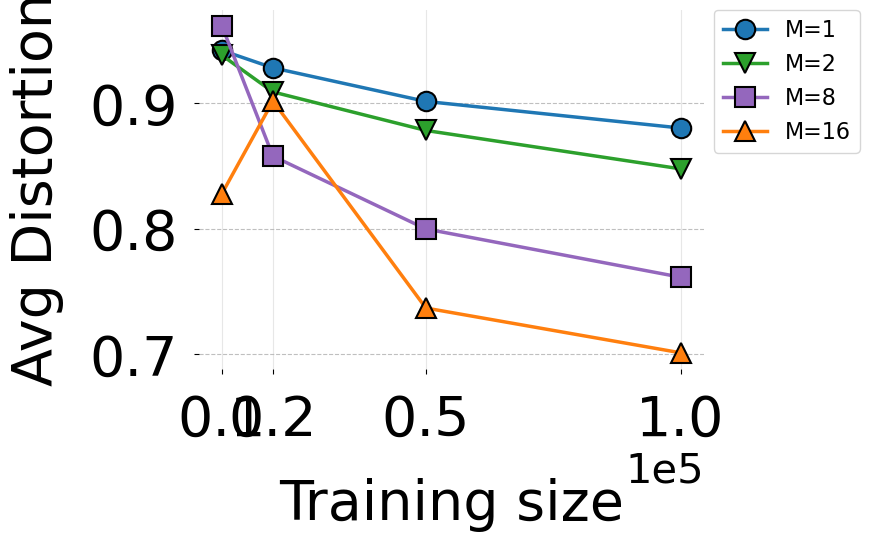

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_train_size_legend_M_lsqpp_openai.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_train_size_legend_M_lsqpp_openai.svg


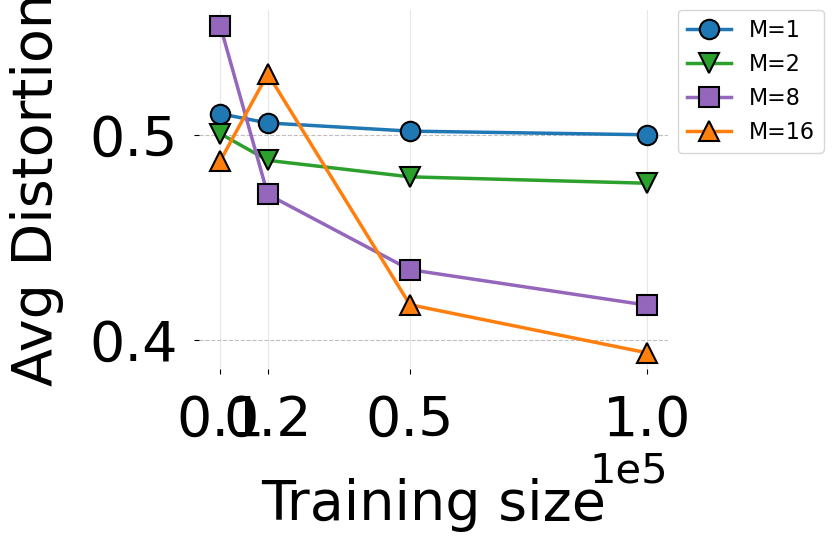

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_train_size_legend_nbits_lsqpp_deep.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_train_size_legend_nbits_lsqpp_deep.svg


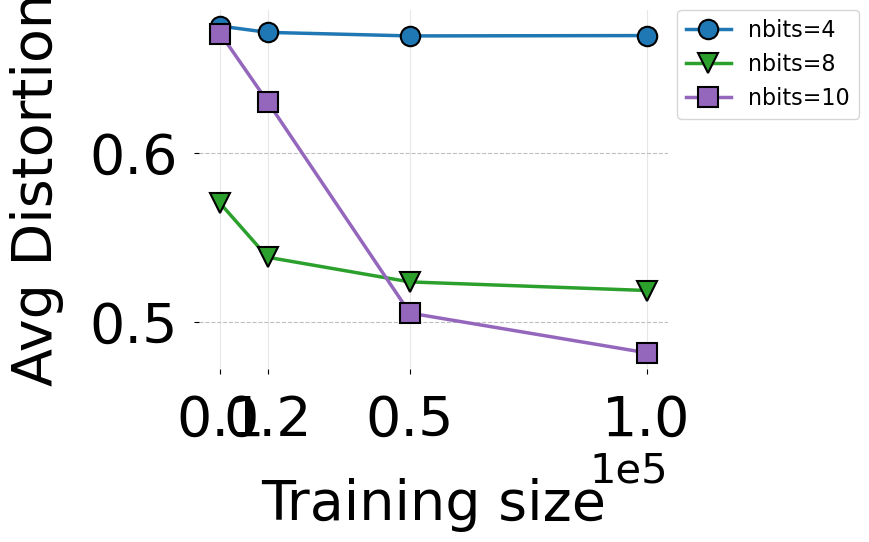

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_train_size_legend_nbits_lsqpp_bigann.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_train_size_legend_nbits_lsqpp_bigann.svg


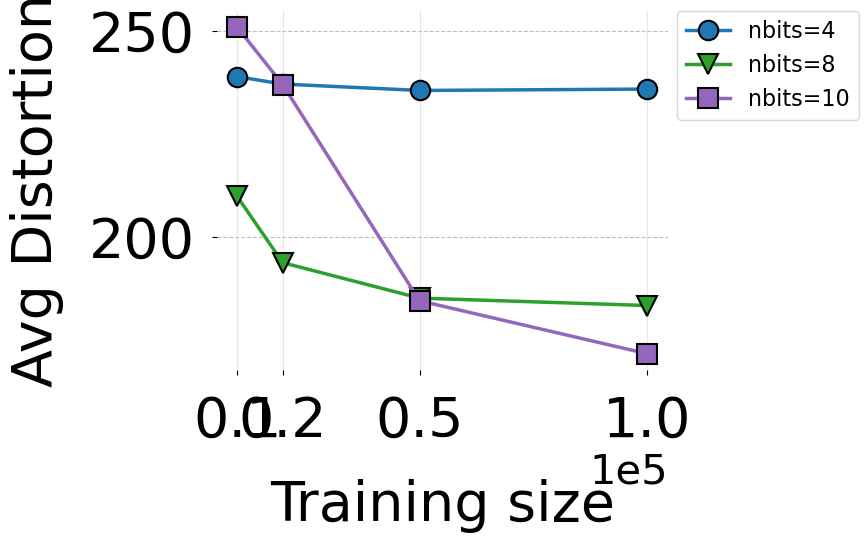

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_train_size_legend_nbits_lsqpp_gist.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_train_size_legend_nbits_lsqpp_gist.svg


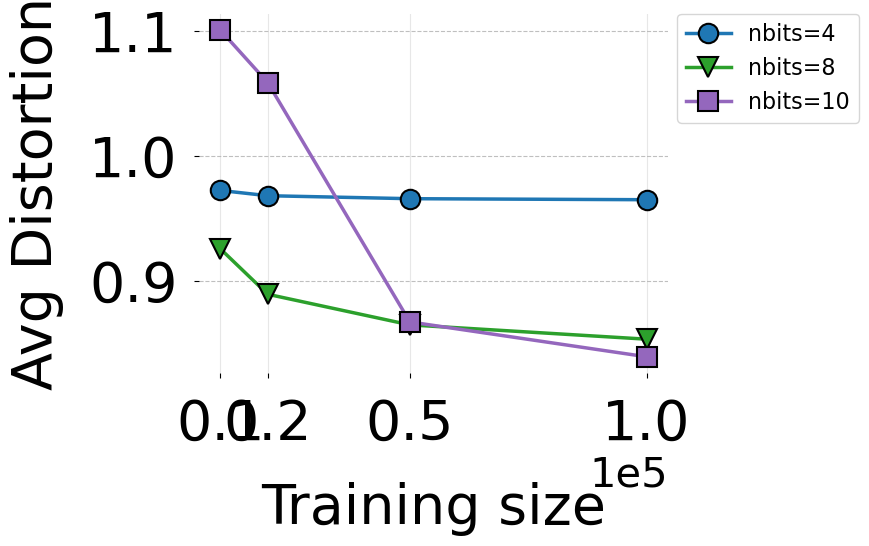

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_train_size_legend_nbits_lsqpp_msmarco.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_train_size_legend_nbits_lsqpp_msmarco.svg


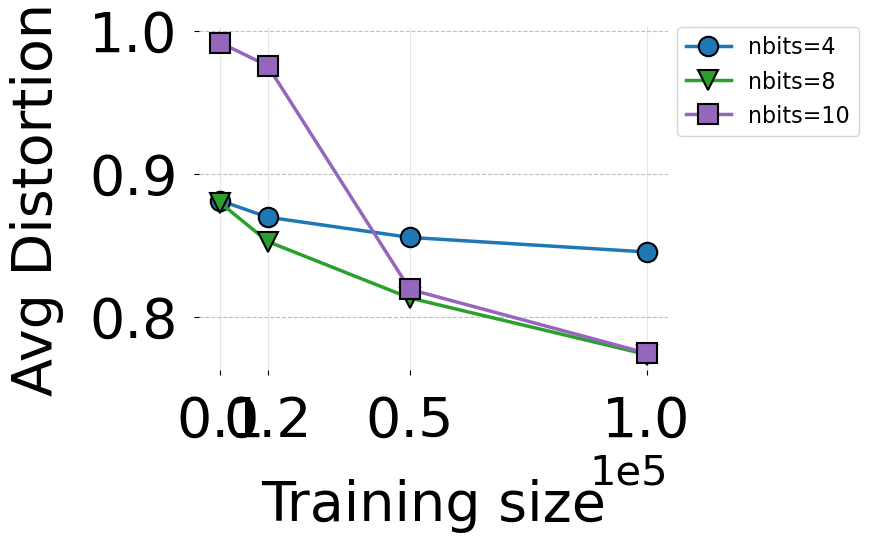

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_train_size_legend_nbits_lsqpp_openai.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_train_size_legend_nbits_lsqpp_openai.svg


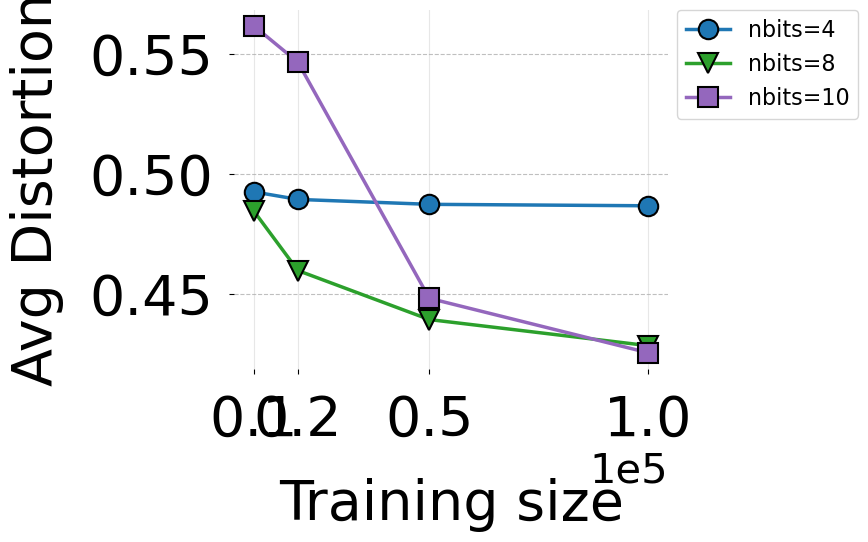

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_train_size_legend_bits_per_vector_lsqpp_deep.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_train_size_legend_bits_per_vector_lsqpp_deep.svg


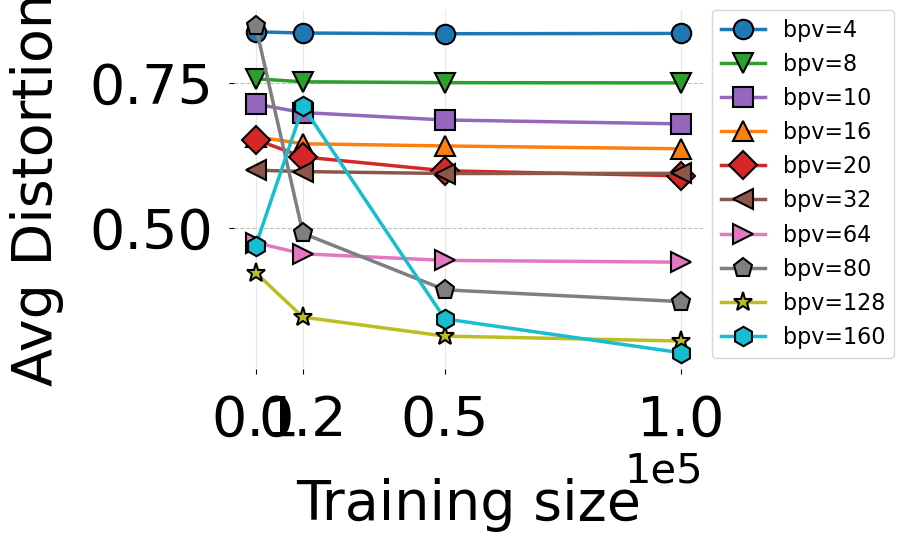

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_train_size_legend_bits_per_vector_lsqpp_bigann.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_train_size_legend_bits_per_vector_lsqpp_bigann.svg


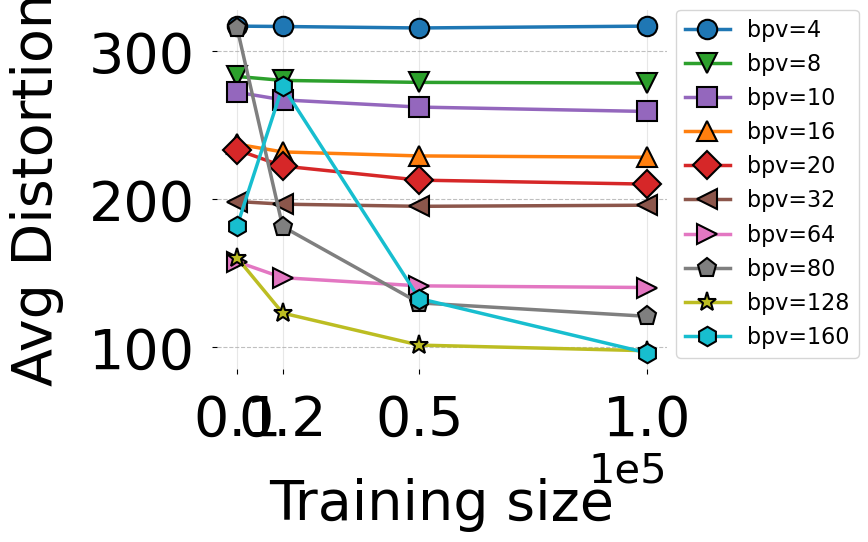

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_train_size_legend_bits_per_vector_lsqpp_gist.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_train_size_legend_bits_per_vector_lsqpp_gist.svg


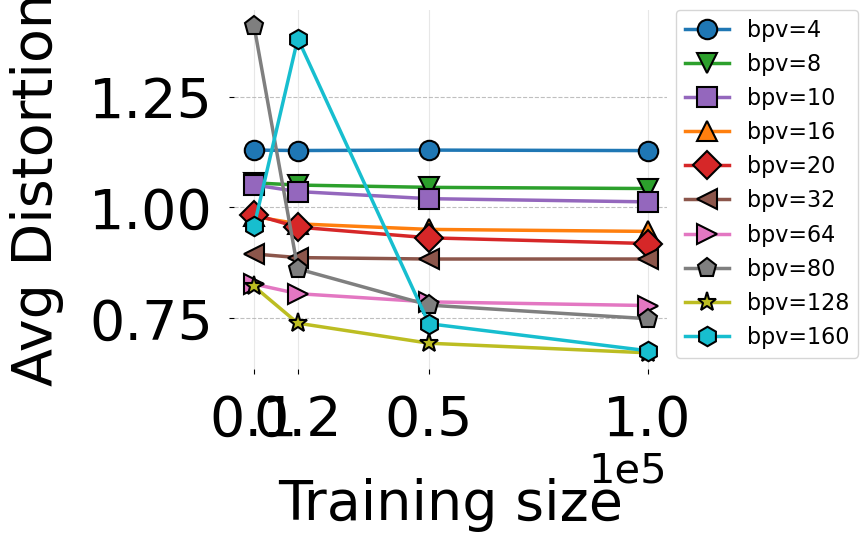

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_train_size_legend_bits_per_vector_lsqpp_msmarco.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_train_size_legend_bits_per_vector_lsqpp_msmarco.svg


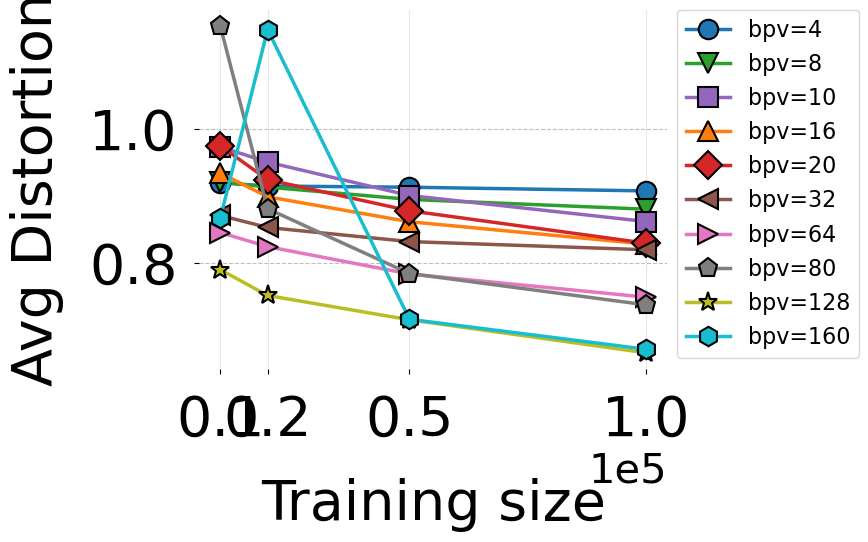

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_train_size_legend_bits_per_vector_lsqpp_openai.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/avg_distortion_vs_train_size_legend_bits_per_vector_lsqpp_openai.svg


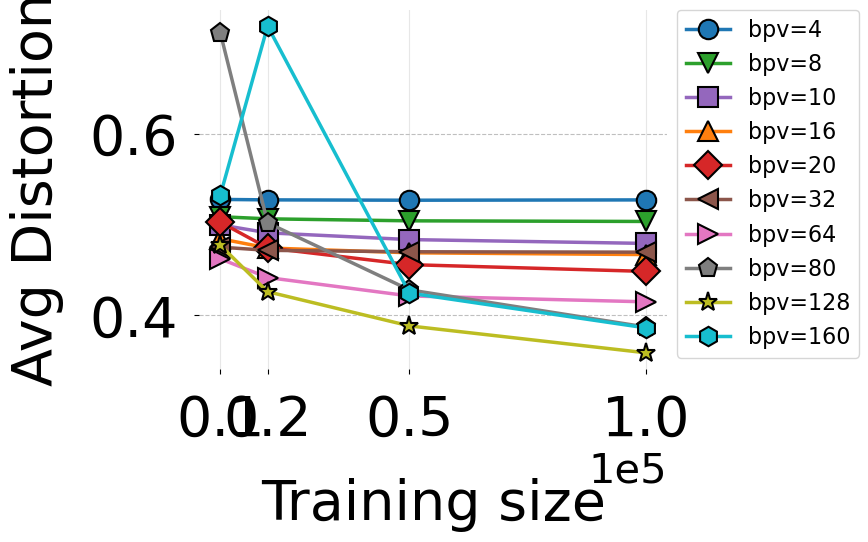

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/pareto_distortion_vs_adc_time_lsqpp_deep.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/pareto_distortion_vs_adc_time_lsqpp_deep.svg


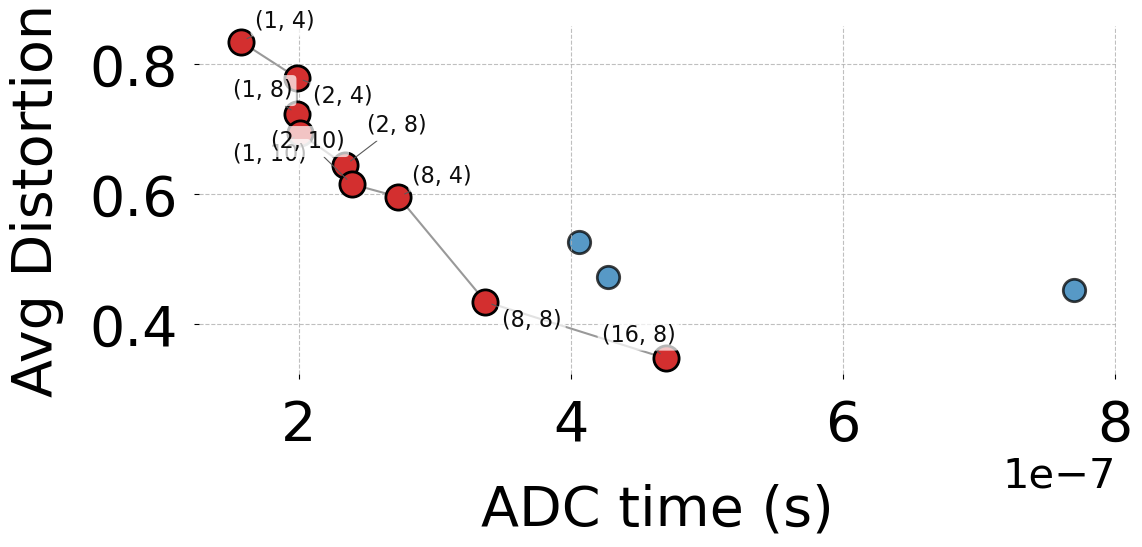

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/pareto_distortion_vs_adc_time_lsqpp_bigann.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/pareto_distortion_vs_adc_time_lsqpp_bigann.svg


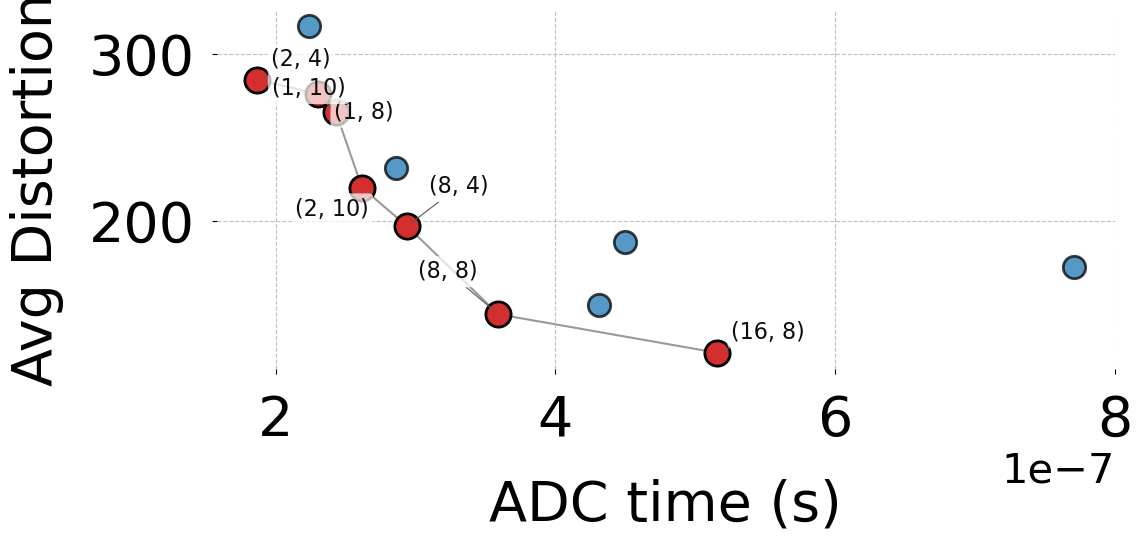

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/pareto_distortion_vs_adc_time_lsqpp_gist.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/pareto_distortion_vs_adc_time_lsqpp_gist.svg


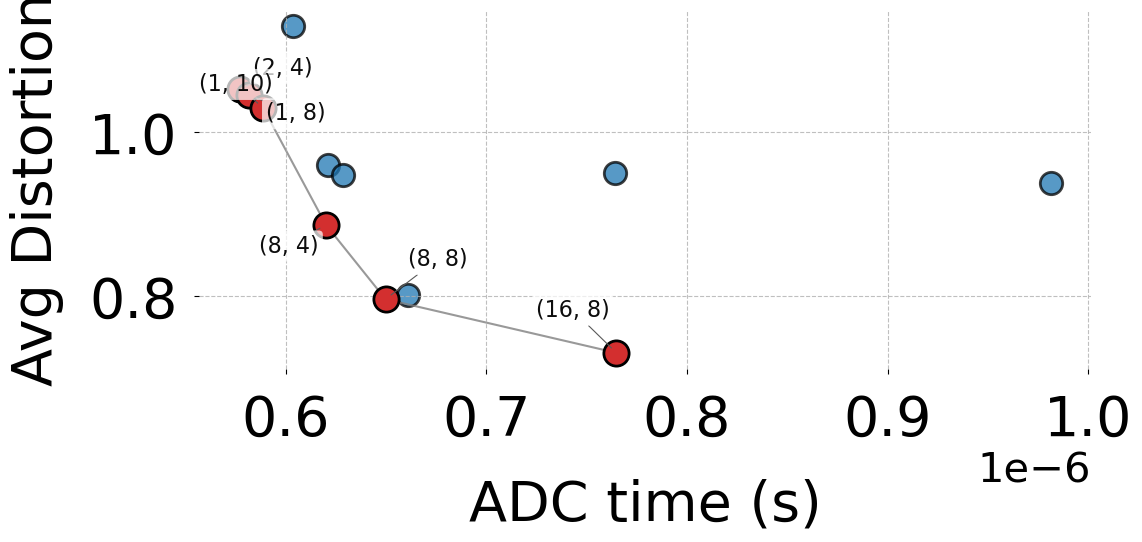

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/pareto_distortion_vs_adc_time_lsqpp_msmarco.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/pareto_distortion_vs_adc_time_lsqpp_msmarco.svg


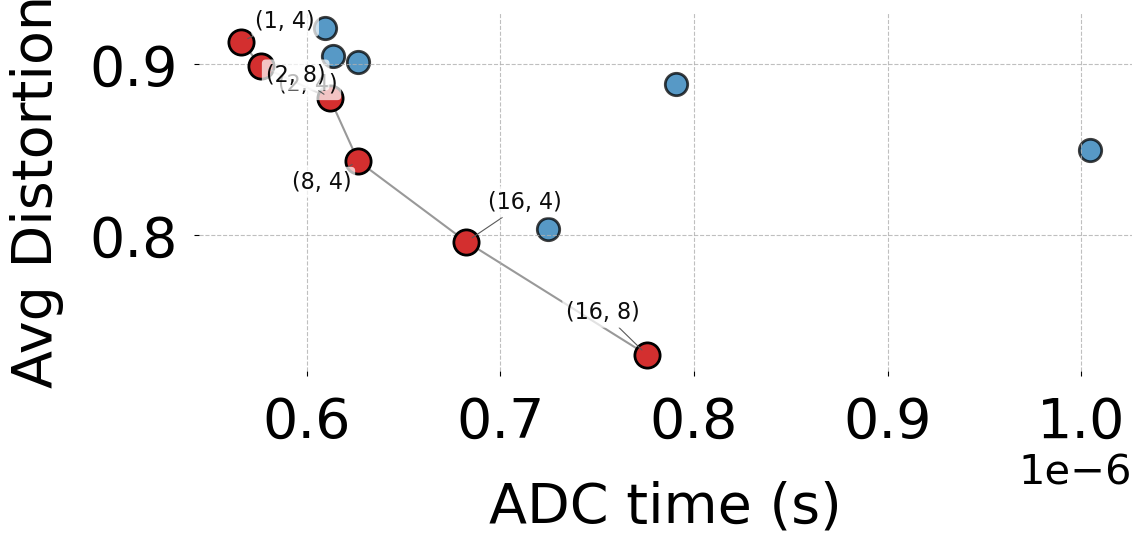

Saved /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/pareto_distortion_vs_adc_time_lsqpp_openai.pdf and /mnthdd/cpanourg/2-hdvc/results/lsqpp/grid_M1_2_8_16_nbits_4_8_10_tsz_10_20_50_100/figures/pareto_distortion_vs_adc_time_lsqpp_openai.svg


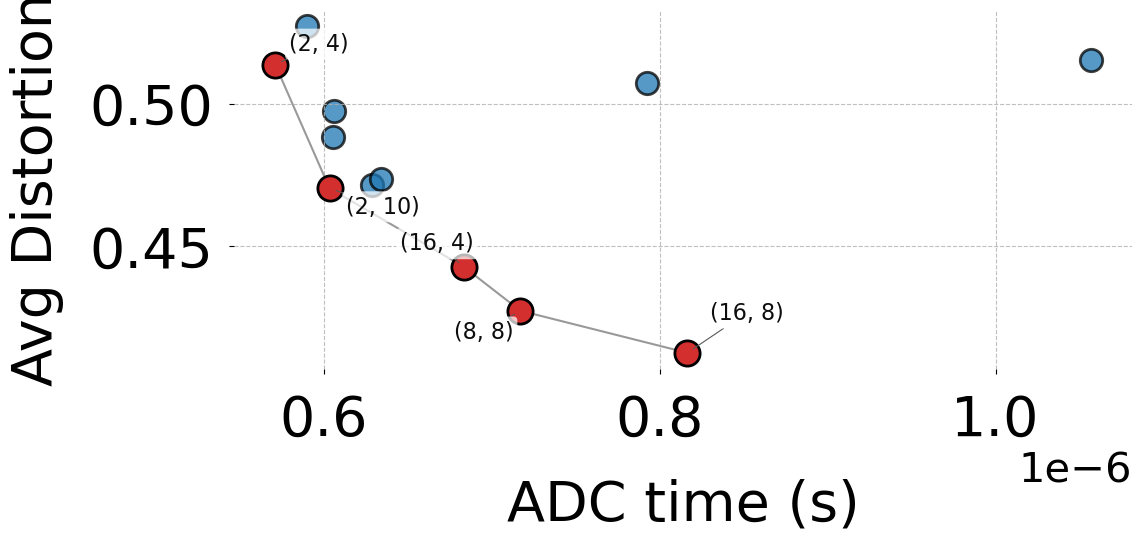

In [26]:
if distortion_plot_df.empty:
    print("No distortion data available; run the previous cell with COMPUTE_MISSING_DISTORTION=True first.")
else:
    # Avg distortion vs M
    plot_avg_metric_vs_param(
        distortion_plot_df,
        x_col="n_subquantizers",
        x_label="M",
        y_col=DISTORTION_Y_COL,
        y_label=DISTORTION_Y_LABEL,
        avg_over=["nbits", "train_size"],
        output_stem="avg_distortion_vs_M",
    )

    # Avg distortion vs nbits
    plot_avg_metric_vs_param(
        distortion_plot_df,
        x_col="nbits",
        x_label="nbits",
        y_col=DISTORTION_Y_COL,
        y_label=DISTORTION_Y_LABEL,
        avg_over=["n_subquantizers", "train_size"],
        output_stem="avg_distortion_vs_nbits",
    )

    # Avg distortion vs training size
    plot_avg_metric_vs_param(
        distortion_plot_df,
        x_col="train_size",
        x_label="Training size",
        y_col=DISTORTION_Y_COL,
        y_label=DISTORTION_Y_LABEL,
        avg_over=["n_subquantizers", "nbits"],
        output_stem="avg_distortion_vs_train_size",
    )

    # Avg distortion plots with the other grid parameters shown in the legend
    plot_metric_vs_param_with_config_legend(
        distortion_plot_df,
        x_col="n_subquantizers",
        x_label="M",
        y_col=DISTORTION_Y_COL,
        y_label=DISTORTION_Y_LABEL,
        legend_cols=["nbits"],
        output_stem="avg_distortion_vs_M_with_config_legend",
    )

    plot_metric_vs_param_with_config_legend(
        distortion_plot_df,
        x_col="nbits",
        x_label="nbits",
        y_col=DISTORTION_Y_COL,
        y_label=DISTORTION_Y_LABEL,
        legend_cols=["n_subquantizers"],
        output_stem="avg_distortion_vs_nbits_with_config_legend",
    )

    plot_metric_vs_param_with_config_legend(
        distortion_plot_df,
        x_col="train_size",
        x_label="Training size",
        y_col=DISTORTION_Y_COL,
        y_label=DISTORTION_Y_LABEL,
        legend_cols=["n_subquantizers"],
        output_stem="avg_distortion_vs_train_size_legend_M",
    )

    plot_metric_vs_param_with_config_legend(
        distortion_plot_df,
        x_col="train_size",
        x_label="Training size",
        y_col=DISTORTION_Y_COL,
        y_label=DISTORTION_Y_LABEL,
        legend_cols=["nbits"],
        output_stem="avg_distortion_vs_train_size_legend_nbits",
    )

    plot_metric_vs_param_with_config_legend(
        distortion_plot_df,
        x_col="train_size",
        x_label="Training size",
        y_col=DISTORTION_Y_COL,
        y_label=DISTORTION_Y_LABEL,
        legend_cols=["bits_per_vector"],
        output_stem="avg_distortion_vs_train_size_legend_bits_per_vector",
    )

    # Avg distortion vs ADC time, Pareto frontier
    plot_pareto_adc_vs_metric(
        distortion_plot_df.merge(
            plot_df[CONFIG_COLS + [ADC_TIME_COL]],
            on=CONFIG_COLS,
            how="left",
            suffixes=("", "_adc"),
        ),
        y_col=DISTORTION_Y_COL,
        y_label=DISTORTION_Y_LABEL,
        output_stem="pareto_distortion_vs_adc_time",
    )
